# Threat Intelligence Platform


## Exploratory Data Analysis & URL Feature Engineering

**Notebook :** `01_url_dataset_eda.ipynb`

### Objectifs

Ce notebook prépare la première version du dataset ML de classification d'URLs de la plateforme.

Classes étudiées :

- **benign** — HTTP Archive ;
- **phishing** — PhishTank ;
- **malware** — URLhaus.

L'objectif n'est pas encore d'entraîner le modèle final.

Cette étape cherche à :

1. vérifier la qualité des données sources ;
2. canonicaliser toutes les URLs avec exactement le même normalizer ;
3. mesurer les volumes et les doublons ;
4. étudier les intersections entre classes ;
5. extraire les features lexicales avant toute projection ML ;
6. comparer leurs distributions par classe ;
7. détecter les features potentiellement biaisées par la source ;
8. détecter les risques de data leakage ;
9. étudier les outliers ;
10. mesurer les corrélations ;
11. mesurer la capacité discriminante des features ;
12. déterminer la taille maximale d'un dataset équilibré ;
13. préparer une proposition de Feature Set V1.

---

## Règles de sécurité

Les URLs complètes peuvent contenir :

- identifiants ;
- tokens ;
- query parameters ;
- chemins privés ;
- données potentiellement sensibles.

Par conséquent :

- aucune URL complète n'est affichée dans le notebook ;
- aucune URL complète n'est exportée ;
- les analyses utilisent des hashes et des statistiques agrégées ;
- les colonnes contenant les URLs sont supprimées de la mémoire après extraction ;
- aucune donnée n'est modifiée dans PostgreSQL.

Le notebook doit être exécuté avec un rôle PostgreSQL en lecture seule.


## Guide de lecture

1. Environnement et sécurité d'accès
2. Inventaire, canonicalisation, déduplication et overlaps
3. Extraction et qualité du Feature Dataset
4. Feature engineering et analyses quantitatives
5. Audit du risque de source proxy
6. Interactions et valeur incrémentale
7. Ablation multivariée et backward elimination
8. Feature Set V1 consolidé
9. PCA finale, capacité du dataset et justification complète
10. Export sécurisé, manifest et checklist de clôture


## 1. Environnement, dépendances et reproductibilité

Le notebook utilise les composants applicatifs réels de la plateforme :

- `CanonicalURLNormalizer`
- `URLFeatureExtractor`

Cela garantit que l'EDA utilise exactement les mêmes transformations que le futur pipeline ML.

Les variables d'environnement sont chargées depuis `.env` avec `python-dotenv`.


In [1]:
from __future__ import annotations

import gc
import json
import platform
import sys
from datetime import datetime, timezone
from pathlib import Path


from dotenv import load_dotenv
from collections import Counter
from math import log2
import re
from urllib.parse import urlsplit


_PERCENT_ENCODING_RE = re.compile(
    r"%[0-9A-Fa-f]{2}"
)

from itertools import combinations

from sklearn.feature_selection import (
    mutual_info_classif,
)
from sklearn.preprocessing import (
    LabelEncoder,
)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold,
    StratifiedGroupKFold,
    cross_validate,
)
from sklearn.pipeline import Pipeline




def find_project_root(
    start: Path | None = None,
) -> Path:
    current = (
        start
        or Path.cwd()
    ).resolve()

    for candidate in (
        current,
        *current.parents,
    ):
        if (
            (candidate / ".env").exists()
            and (candidate / "application").is_dir()
            and (candidate / "infrastructure").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Unable to locate project root"
    )


PROJECT_ROOT = find_project_root()
ENV_FILE = PROJECT_ROOT / ".env"

load_dotenv(
    dotenv_path=ENV_FILE,
    override=False,
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

print("Project root detected and .env loaded without override.")

Project root detected and .env loaded without override.


In [2]:
try:
    import matplotlib
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import sklearn
    import sqlalchemy
    
    from contextlib import contextmanager

    from sklearn.decomposition import PCA
    from sklearn.feature_selection import mutual_info_classif
    from sklearn.preprocessing import StandardScaler

except ImportError as error:
    raise RuntimeError(
        "Missing ML/EDA dependencies. "
        "Install pandas, numpy, matplotlib "
        "and scikit-learn before running "
        "this notebook."
    ) from error


from sqlalchemy import text

from application.services.canonical_url_normalizer import (
    CanonicalURLNormalizationError,
    CanonicalURLNormalizer,
)
from application.services.url_feature_extractor import (
    URLFeatureExtractionError,
    URLFeatureExtractor,
)
from infrastructure.persistence.sqlalchemy.engine import (
    create_ingestion_engine,
)

In [3]:
pd.set_option(
    "display.max_columns",
    100,
)
pd.set_option(
    "display.max_rows",
    100,
)
pd.set_option(
    "display.width",
    160,
)

RANDOM_SEED = 42

HTTP_ARCHIVE_SNAPSHOT = (
    "http-archive-2026-07-01-mobile-secondary"
)

LABEL_ORDER = [
    "benign",
    "phishing",
    "malware",
]

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)
print("SQLAlchemy:", sqlalchemy.__version__)

Python: 3.12.6
pandas: 2.2.3
numpy: 2.2.6
matplotlib: 3.10.0
scikit-learn: 1.6.1
SQLAlchemy: 2.0.51


## 2. Connexion PostgreSQL explicitement en lecture seule

Le notebook refuse volontairement de continuer si la connexion n'est pas configurée en lecture seule.

Cette protection évite qu'une cellule exploratoire puisse modifier accidentellement les données de la plateforme.


In [4]:
engine = create_ingestion_engine()


@contextmanager
def read_connection():
    """
    Ouvre une transaction PostgreSQL explicitement READ ONLY.

    Cela garantit qu'aucun INSERT, UPDATE, DELETE ou DDL
    ne peut être exécuté depuis le notebook, même si le rôle
    connecté n'a pas default_transaction_read_only=on.
    """
    with engine.connect() as connection:
        with connection.begin():
            connection.execute(
                text(
                    "SET TRANSACTION READ ONLY"
                )
            )

            yield connection

In [5]:
with read_connection() as connection:
    db_state = dict(
        connection.execute(
            text(
                """
                SELECT
                    current_setting(
                        'transaction_read_only'
                    ) AS transaction_read_only
                """
            )
        ).mappings().one()
    )

# Only the read-only state is displayed. User/role names are intentionally not
# persisted in notebook outputs because this notebook may be committed.
db_state


{'transaction_read_only': 'on'}

In [6]:
if (
    db_state[
        "transaction_read_only"
    ]
    != "on"
):
    raise RuntimeError(
        "Unable to enforce a read-only "
        "PostgreSQL transaction"
    )

print(
    "Read-only PostgreSQL transaction confirmed."
)

Read-only PostgreSQL transaction confirmed.


## 3. Inventaire et contrôle des sources

Avant de charger les URLs, on vérifie les volumes directement en base.

Cette étape permet notamment de détecter :

- une ingestion incomplète ;
- une source vide ;
- un mauvais snapshot HTTP Archive ;
- une variation inattendue du nombre de records.


In [7]:
SOURCE_COUNTS_SQL = text(
    """
    SELECT
        'benign' AS label,
        COUNT(*) AS rows
    FROM normalized.http_archive_page
    WHERE source_snapshot = :snapshot

    UNION ALL

    SELECT
        'phishing' AS label,
        COUNT(*) AS rows
    FROM normalized.phishtank_phishing
    WHERE verified IS TRUE
      AND online IS TRUE

    UNION ALL

    SELECT
        'malware' AS label,
        COUNT(*) AS rows
    FROM normalized.urlhaus_url
    """
)

with read_connection() as connection:
    source_counts = pd.read_sql_query(
        SOURCE_COUNTS_SQL,
        connection,
        params={
            "snapshot": HTTP_ARCHIVE_SNAPSHOT,
        },
    )

source_counts

,label,rows
0,malware,30880
1,benign,58668
2,phishing,67524


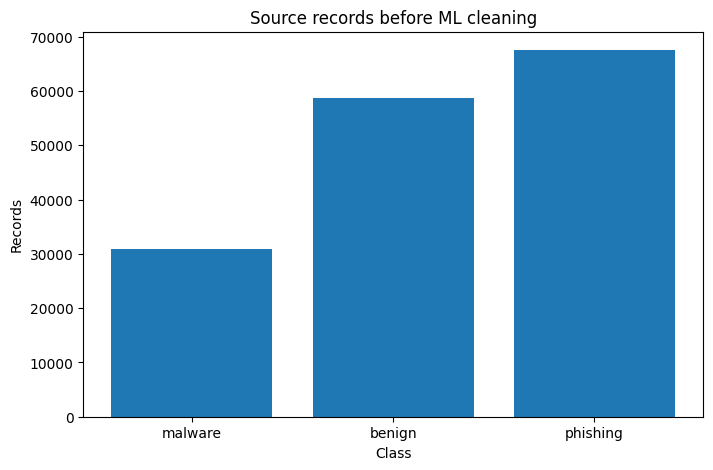

In [8]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    source_counts["label"],
    source_counts["rows"],
)

ax.set_title(
    "Source records before ML cleaning"
)
ax.set_xlabel("Class")
ax.set_ylabel("Records")

plt.show()

## 3.1 PhishTank — état des observations

Pour le premier modèle, seules les observations :

- `verified = TRUE`
- `online = TRUE`

sont considérées comme candidates phishing. 
La documentation de dump persisté de Phishtank indique qu'il est active-only, càd il contient les urls de phishing actuellement online. 

In [9]:
PHISHTANK_STATUS_SQL = text(
    """
    SELECT
        verified,
        online,
        COUNT(*) AS records
    FROM normalized.phishtank_phishing
    GROUP BY verified, online
    ORDER BY records DESC
    """
)

with read_connection() as connection:
    phishtank_status = pd.read_sql_query(
        PHISHTANK_STATUS_SQL,
        connection,
    )

phishtank_status

,verified,online,records
0,True,True,67524


## 3.2 URLhaus — état des observations

Le statut URLhaus ne sera pas utilisé comme feature.

Il représente une information de source et pourrait provoquer une fuite de label ou un biais de collecte.

On l'étudie uniquement pour comprendre la population disponible.

In [10]:
URLHAUS_STATUS_SQL = text(
    """
    SELECT
        COALESCE(
            url_status,
            '<null>'
        ) AS url_status,
        COUNT(*) AS records
    FROM normalized.urlhaus_url
    GROUP BY url_status
    ORDER BY records DESC
    """
)

with read_connection() as connection:
    urlhaus_status = pd.read_sql_query(
        URLHAUS_STATUS_SQL,
        connection,
    )

urlhaus_status

,url_status,records
0,online,16998
1,offline,13882


## 4. Chargement minimal des URLs nécessaires à l'EDA

Seules les colonnes nécessaires à l'EDA sont chargées.

Aucun payload RAW, description CTI ou autre donnée inutile n'est chargé.

Cela réduit :

- l'utilisation mémoire ;
- l'exposition de données ;
- le temps d'exécution.


In [11]:
BENIGN_SQL = text(
    """
    SELECT
        id::text AS record_id,
        canonical_value AS url,
        value_hash AS stored_value_hash,
        hostname AS stored_hostname,
        registered_domain,
        source_rank,
        source_snapshot,
        observed_at
    FROM normalized.http_archive_page
    WHERE source_snapshot = :snapshot
    """
)


PHISHING_SQL = text(
    """
    SELECT
        id::text AS record_id,
        phishing_url AS url,
        hostname AS stored_hostname,
        COALESCE(
            verification_time,
            submission_time,
            normalized_at
        ) AS observed_at,
        verified,
        online
    FROM normalized.phishtank_phishing
    WHERE verified IS TRUE
      AND online IS TRUE
      AND phishing_url IS NOT NULL
    """
)


MALWARE_SQL = text(
    """
    SELECT
        id::text AS record_id,
        malicious_url AS url,
        hostname AS stored_hostname,
        COALESCE(
            date_added,
            normalized_at
        ) AS observed_at,
        url_status,
        threat_type
    FROM normalized.urlhaus_url
    WHERE malicious_url IS NOT NULL
    """
)

In [12]:
with read_connection() as connection:
    benign_raw = pd.read_sql_query(
        BENIGN_SQL,
        connection,
        params={
            "snapshot": HTTP_ARCHIVE_SNAPSHOT,
        },
    )

    phishing_raw = pd.read_sql_query(
        PHISHING_SQL,
        connection,
    )

    malware_raw = pd.read_sql_query(
        MALWARE_SQL,
        connection,
    )


print("benign:", len(benign_raw))
print("phishing:", len(phishing_raw))
print("malware:", len(malware_raw))

benign: 58668
phishing: 67524
malware: 30880


## 5. Canonicalisation uniforme et contrôles d'intégrité

HTTP Archive a déjà été canonicalisé lors de sa persistance.

PhishTank et URLhaus sont néanmoins repassés par le même `CanonicalURLNormalizer`.

Cette opération garantit que :

- les hashes sont comparables ;
- les doublons exacts sont correctement détectés ;
- les overlaps entre classes sont mesurés sur la même représentation ;
- l'extraction des features ne dépend pas de la source.


In [13]:
normalizer = CanonicalURLNormalizer()

feature_extractor = URLFeatureExtractor()

print(
    "Canonicalization version:",
    normalizer.CANONICALIZATION_VERSION,
)

print(
    "Feature set version:",
    feature_extractor.VERSION,
)

Canonicalization version: 1
Feature set version: 1.0.0


In [14]:
def canonicalize_source(
    frame: pd.DataFrame,
    *,
    label: str,
) -> tuple[
    pd.DataFrame,
    dict[str, int],
]:
    records: list[
        dict[str, object]
    ] = []

    rejected = 0
    integrity_hash_mismatch = 0
    integrity_hostname_mismatch = 0

    for row in frame.itertuples(
        index=False
    ):
        try:
            identity = (
                normalizer.normalize(
                    row.url
                )
            )

        except (
            CanonicalURLNormalizationError,
            TypeError,
        ):
            rejected += 1
            continue

        stored_hash = getattr(
            row,
            "stored_value_hash",
            None,
        )

        if (
            stored_hash is not None
            and stored_hash
            != identity.value_hash
        ):
            integrity_hash_mismatch += 1

        stored_hostname = getattr(
            row,
            "stored_hostname",
            None,
        )

        if (
            stored_hostname
            and stored_hostname.lower()
            != identity.hostname.lower()
        ):
            integrity_hostname_mismatch += 1

        records.append(
            {
                "record_id": row.record_id,
                "label": label,
                "canonical_value": (
                    identity.canonical_value
                ),
                "value_hash": (
                    identity.value_hash
                ),
                "hostname": (
                    identity.hostname
                ),
                "canonicalization_version": (
                    identity
                    .canonicalization_version
                ),
                "observed_at": (
                    row.observed_at
                ),
            }
        )

    result = pd.DataFrame(
        records
    )

    diagnostics = {
        "input_rows": len(frame),
        "accepted_rows": len(result),
        "rejected_rows": rejected,
        "hash_mismatch": (
            integrity_hash_mismatch
        ),
        "hostname_mismatch": (
            integrity_hostname_mismatch
        ),
    }

    return result, diagnostics

In [15]:
benign_canonical, benign_diag = (
    canonicalize_source(
        benign_raw,
        label="benign",
    )
)

phishing_canonical, phishing_diag = (
    canonicalize_source(
        phishing_raw,
        label="phishing",
    )
)

malware_canonical, malware_diag = (
    canonicalize_source(
        malware_raw,
        label="malware",
    )
)


canonicalization_diagnostics = (
    pd.DataFrame(
        [
            {
                "source": "benign",
                **benign_diag,
            },
            {
                "source": "phishing",
                **phishing_diag,
            },
            {
                "source": "malware",
                **malware_diag,
            },
        ]
    )
)

canonicalization_diagnostics

,source,input_rows,accepted_rows,rejected_rows,hash_mismatch,hostname_mismatch
0,benign,58668,58668,0,0,0
1,phishing,67524,67514,10,0,3
2,malware,30880,30880,0,0,0


### Interprétation des rejets de canonicalisation

Les **10 URLs PhishTank rejetées** ont été acceptées par le normalizer historique de la source, mais ne respectent pas les règles plus strictes du `CanonicalURLNormalizer` utilisé pour le pipeline ML.

Ce comportement est attendu : le contrat canonique V1 impose une représentation uniforme et déterministe des URLs avant l'extraction des features. Ces quelques URLs sont donc exclues plutôt que d'assouplir les règles de canonicalisation.

Les **3 `hostname_mismatch` ne sont pas des rejets**. Les URLs restent valides, mais le hostname recalculé diffère légèrement de celui stocké historiquement, probablement à cause d'une normalisation supplémentaire telle que l'IDNA, la normalisation d'une adresse IP ou la suppression d'un point terminal.

Avec seulement **10 rejets sur 67 524 URLs PhishTank**, l'impact sur le dataset est négligeable et la qualité globale de la source reste très bonne.


In [16]:
if benign_diag["hash_mismatch"] != 0:
    raise RuntimeError(
        "HTTP Archive hash integrity "
        "mismatch detected"
    )

if benign_diag["hostname_mismatch"] != 0:
    raise RuntimeError(
        "HTTP Archive hostname integrity "
        "mismatch detected"
    )

## 6. Déduplication intra-classe

Les sources peuvent contenir plusieurs observations d'une même URL.

Le modèle ne doit pas recevoir plusieurs copies du même indicateur sous prétexte qu'il a été observé plusieurs fois.

La clé d'identité choisie est :

`(canonicalization_version, value_hash)`


In [17]:
def duplicate_summary(
    frame: pd.DataFrame,
) -> dict[str, int]:
    unique_urls = (
        frame["value_hash"]
        .nunique()
    )

    return {
        "rows": len(frame),
        "unique_urls": unique_urls,
        "duplicate_rows": (
            len(frame)
            - unique_urls
        ),
        "unique_hostnames": (
            frame["hostname"]
            .nunique()
        ),
    }


duplicate_stats = pd.DataFrame(
    [
        {
            "class": "benign",
            **duplicate_summary(
                benign_canonical
            ),
        },
        {
            "class": "phishing",
            **duplicate_summary(
                phishing_canonical
            ),
        },
        {
            "class": "malware",
            **duplicate_summary(
                malware_canonical
            ),
        },
    ]
)

duplicate_stats

,class,rows,unique_urls,duplicate_rows,unique_hostnames
0,benign,58668,58668,0,58667
1,phishing,67514,67228,286,34693
2,malware,30880,29928,952,7776


### Interprétation de la déduplication

Les doublons représentent plusieurs observations d'une même URL canonicalisée. Ils restent conservés dans les tables de threat intelligence afin de préserver l'historique et les preuves de collecte.

Pour le dataset ML, chaque URL canonique ne doit cependant apparaître qu'une seule fois. Conserver les doublons donnerait davantage de poids aux URLs fréquemment observées et pourrait introduire une fuite de données si une même URL apparaissait à la fois dans les ensembles d'entraînement et de test.

La déduplication est donc réalisée **uniquement dans la préparation ML**, avant l'équilibrage et le split, à partir de l'identité `(canonicalization_version, value_hash)`.


In [18]:
benign_unique = (
    benign_canonical
    .drop_duplicates(
        subset=[
            "canonicalization_version",
            "value_hash",
        ]
    )
    .reset_index(drop=True)
)

phishing_unique = (
    phishing_canonical
    .drop_duplicates(
        subset=[
            "canonicalization_version",
            "value_hash",
        ]
    )
    .reset_index(drop=True)
)

malware_unique = (
    malware_canonical
    .drop_duplicates(
        subset=[
            "canonicalization_version",
            "value_hash",
        ]
    )
    .reset_index(drop=True)
)

## 7. Chevauchements inter-classes et ambiguïtés de labels

Une même URL ne doit pas apparaître avec plusieurs labels dans un dataset de classification single-label.

On étudie donc :

- overlap exact des URLs ;
- overlap des hostnames.

Les overlaps exacts seront exclus du dataset final.

Un overlap de hostname n'implique pas nécessairement une contradiction :

un même domaine peut héberger simultanément du contenu légitime et malveillant.


In [19]:
hash_sets = {
    "benign": set(
        benign_unique[
            "value_hash"
        ]
    ),
    "phishing": set(
        phishing_unique[
            "value_hash"
        ]
    ),
    "malware": set(
        malware_unique[
            "value_hash"
        ]
    ),
}


hostname_sets = {
    "benign": set(
        benign_unique[
            "hostname"
        ]
    ),
    "phishing": set(
        phishing_unique[
            "hostname"
        ]
    ),
    "malware": set(
        malware_unique[
            "hostname"
        ]
    ),
}

In [20]:
overlap_summary = pd.DataFrame(
    [
        {
            "comparison": (
                "benign ↔ phishing"
            ),
            "exact_url_overlap": len(
                hash_sets["benign"]
                & hash_sets["phishing"]
            ),
            "hostname_overlap": len(
                hostname_sets["benign"]
                & hostname_sets["phishing"]
            ),
        },
        {
            "comparison": (
                "benign ↔ malware"
            ),
            "exact_url_overlap": len(
                hash_sets["benign"]
                & hash_sets["malware"]
            ),
            "hostname_overlap": len(
                hostname_sets["benign"]
                & hostname_sets["malware"]
            ),
        },
        {
            "comparison": (
                "phishing ↔ malware"
            ),
            "exact_url_overlap": len(
                hash_sets["phishing"]
                & hash_sets["malware"]
            ),
            "hostname_overlap": len(
                hostname_sets["phishing"]
                & hostname_sets["malware"]
            ),
        },
    ]
)

overlap_summary

,comparison,exact_url_overlap,hostname_overlap
0,benign ↔ phishing,0,55
1,benign ↔ malware,0,5
2,phishing ↔ malware,3,14


### Interprétation des chevauchements de hostname

Certaines URLs de classes différentes partagent le même hostname, mais correspondent à des chemins ou ressources distincts. Ce chevauchement est réaliste : un même domaine peut héberger à la fois du contenu légitime et malveillant.

Nous choisissons donc de **conserver ces URLs** afin de ne pas simplifier artificiellement le problème de classification.

Pour éviter le data leakage lors de l'entraînement, nous appliquerons ensuite une stratégie de **group-aware split** : toutes les URLs appartenant au même `registered_domain` — ou à la même IP normalisée — devront rester dans un seul et même split (`train`, `validation` ou `test`).


In [21]:
ambiguous_hashes = (
    (
        hash_sets["benign"]
        & hash_sets["phishing"]
    )
    | (
        hash_sets["benign"]
        & hash_sets["malware"]
    )
    | (
        hash_sets["phishing"]
        & hash_sets["malware"]
    )
)

print(
    "Exact ambiguous URLs:",
    len(ambiguous_hashes),
)

Exact ambiguous URLs: 3


### Interprétation des URLs ambiguës

Une URL est considérée comme **ambiguë** lorsqu’une même URL canonicalisée apparaît dans plusieurs classes avec des labels différents.

Dans notre dataset, **3 URLs exactes sont présentes à la fois dans PhishTank et URLhaus**, donc associées simultanément aux labels `phishing` et `malware`.

Comme notre premier modèle est **multiclass single-label**, une URL ne peut recevoir qu’une seule classe. Ces cas seront donc **exclus du dataset ML V1** afin d’éviter un choix arbitraire de label et du bruit supervisé.

Les observations originales restent toutefois conservées dans les tables de threat intelligence pour préserver les preuves et l’historique des sources.


In [22]:
def remove_ambiguous(
    frame: pd.DataFrame,
) -> pd.DataFrame:
    return (
        frame[
            ~frame[
                "value_hash"
            ].isin(
                ambiguous_hashes
            )
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


benign_clean = remove_ambiguous(
    benign_unique
)

phishing_clean = remove_ambiguous(
    phishing_unique
)

malware_clean = remove_ambiguous(
    malware_unique
)

## 8. Capacité maximale d'un dataset équilibré

Le dataset final doit utiliser le même nombre d'URLs pour chaque classe.

La taille maximale par classe est donc le minimum du nombre de samples propres disponibles.

- L’objectif 1: est d’éviter qu’une classe majoritaire influence artificiellement le modèle et de rendre les métriques par classe plus faciles à interpréter.
- L'objectif 2 : on mesure d’abord si les features permettent réellement de distinguer benign, phishing et malware, sans ajouter tout de suite la complexité des proportions réelles du trafic en production.


In [23]:
available_by_class = pd.Series(
    {
        "benign": len(
            benign_clean
        ),
        "phishing": len(
            phishing_clean
        ),
        "malware": len(
            malware_clean
        ),
    },
    name="available_samples",
)

available_by_class

benign      58668
phishing    67225
malware     29925
Name: available_samples, dtype: int64

In [24]:
balanced_target = int(
    available_by_class.min()
)

print(
    "Maximum balanced samples "
    "per class:",
    f"{balanced_target:,}",
)

print(
    "Maximum balanced dataset:",
    f"{balanced_target * 3:,}",
)

Maximum balanced samples per class: 29,925
Maximum balanced dataset: 89,775


### Transition des données nettoyées vers la représentation ML

Les volumes, doublons et ambiguïtés sont maintenant compris. La suite de l'EDA se concentre sur la représentation lexicale des URLs : d'abord le Feature Set de base, puis des candidates engineered étudiées.

## 9. Extraction du Feature Set de base

Les features sont extraites depuis la **canonical URL avant projection ML**.

C'est un point architectural critique.

Une projection ML peut modifier :

- les query values ;
- les tokens ;
- certains segments ;
- le fragment.

Extraire les features après projection introduirait donc une représentation artificielle de l'URL.


In [25]:
FEATURE_COLUMNS = [
    "url_length",
    "hostname_length",
    "path_length",
    "query_length",
    "fragment_length",
    "dot_count",
    "hyphen_count",
    "digit_count",
    "special_char_count",
    "path_segment_count",
    "query_parameter_count",
    "has_ip_address",
    "has_https",
    "has_non_default_port",
    "has_punycode",
    "has_percent_encoding",
]


NUMERIC_FEATURES = [
    "url_length",
    "hostname_length",
    "path_length",
    "query_length",
    "fragment_length",
    "dot_count",
    "hyphen_count",
    "digit_count",
    "special_char_count",
    "path_segment_count",
    "query_parameter_count",
]


BINARY_FEATURES = [
    "has_ip_address",
    "has_https",
    "has_non_default_port",
    "has_punycode",
    "has_percent_encoding",
]

In [26]:
def extract_features(
    frame: pd.DataFrame,
) -> tuple[
    pd.DataFrame,
    int,
]:
    records: list[
        dict[str, object]
    ] = []

    rejected = 0

    for row in frame.itertuples(
        index=False
    ):
        try:
            features = (
                feature_extractor.extract(
                    row.canonical_value
                )
            )

        except (
            URLFeatureExtractionError,
            TypeError,
        ):
            rejected += 1
            continue

        records.append(
            {
                "record_id": row.record_id,
                "label": row.label,
                "value_hash": row.value_hash,
                "hostname": row.hostname,
                "observed_at": row.observed_at,
                **{
                    column: getattr(
                        features,
                        column,
                    )
                    for column
                    in FEATURE_COLUMNS
                },
            }
        )

    return (
        pd.DataFrame(records),
        rejected,
    )

In [27]:
benign_features, benign_feature_rejected = (
    extract_features(
        benign_clean
    )
)

phishing_features, phishing_feature_rejected = (
    extract_features(
        phishing_clean
    )
)

malware_features, malware_feature_rejected = (
    extract_features(
        malware_clean
    )
)


print(
    "Feature extraction rejects:"
)
print(
    "benign:",
    benign_feature_rejected,
)
print(
    "phishing:",
    phishing_feature_rejected,
)
print(
    "malware:",
    malware_feature_rejected,
)

Feature extraction rejects:
benign: 0
phishing: 0
malware: 0


In [28]:
features_df = pd.concat(
    [
        benign_features,
        phishing_features,
        malware_features,
    ],
    ignore_index=True,
)

features_df.shape

(155818, 21)

## 10. Construction des features candidates

Une feature candidate devra satisfaire autant que possible :

- calculable uniquement depuis l’URL au moment de la prédiction 
- déterministe et sans réseau 
- coût proche de O(n) par URL 
- aucune dépendance à la source (PhishTank, URLhaus, HTTP Archive) 
- pas de hostname/domain brut utilisé comme catégorie 
- explicable 
- non constante ou quasi constante 
- apport d’information par rapport aux 16 features actuelles 
- pas de fuite de données évidente 
- comportement identique en entraînement et en production.


In [29]:
#helpers
def shannon_entropy(
    value: str,
) -> float:
    """
    Calcule l'entropie de Shannon d'une chaîne.

    Complexité : O(n).
    Aucun accès réseau.
    """
    if not value:
        return 0.0

    counts = Counter(
        value
    )

    length = len(
        value
    )

    entropy = 0.0

    for count in counts.values():
        probability = (
            count
            / length
        )

        entropy -= (
            probability
            * log2(
                probability
            )
        )

    return float(
        entropy
    )


def max_consecutive_run(
    value: str,
    predicate,
) -> int:
    """
    Retourne la plus longue séquence consécutive
    satisfaisant predicate(character).
    """
    maximum = 0
    current = 0

    for character in value:
        if predicate(
            character
        ):
            current += 1

            if current > maximum:
                maximum = current

        else:
            current = 0

    return maximum

In [30]:
#Extraction des nouvelles candidates
def extract_experimental_features(
    canonical_value: str,
) -> dict[str, float | int]:
    parsed = urlsplit(
        canonical_value
    )

    hostname = (
        parsed.hostname
        or ""
    )

    path = (
        parsed.path
        or "/"
    )

    query = (
        parsed.query
        or ""
    )

    hostname_labels = [
        label
        for label
        in hostname.split(".")
        if label
    ]

    path_segments = [
        segment
        for segment
        in path.split("/")
        if segment
    ]

    hostname_label_lengths = [
        len(label)
        for label
        in hostname_labels
    ]

    path_segment_lengths = [
        len(segment)
        for segment
        in path_segments
    ]

    url_length = max(
        len(canonical_value),
        1,
    )

    hostname_length = max(
        len(hostname),
        1,
    )

    digit_count = sum(
        character.isdigit()
        for character
        in canonical_value
    )

    special_char_count = sum(
        not character.isalnum()
        for character
        in canonical_value
    )

    hostname_digit_count = sum(
        character.isdigit()
        for character
        in hostname
    )

    return {
        # ----------------------------
        # Hostname structure
        # ----------------------------
        "hostname_dot_count": (
            hostname.count(".")
        ),
        "hostname_hyphen_count": (
            hostname.count("-")
        ),
        "hostname_digit_count": (
            hostname_digit_count
        ),
        "hostname_label_count": (
            len(
                hostname_labels
            )
        ),
        "max_hostname_label_length": (
            max(
                hostname_label_lengths,
                default=0,
            )
        ),
        "mean_hostname_label_length": (
            float(
                np.mean(
                    hostname_label_lengths
                )
            )
            if hostname_label_lengths
            else 0.0
        ),

        # ----------------------------
        # Path structure
        # ----------------------------
        "path_digit_count": sum(
            character.isdigit()
            for character
            in path
        ),
        "path_special_char_count": sum(
            not character.isalnum()
            for character
            in path
        ),
        "path_slash_count": (
            path.count("/")
        ),
        "max_path_segment_length": (
            max(
                path_segment_lengths,
                default=0,
            )
        ),
        "mean_path_segment_length": (
            float(
                np.mean(
                    path_segment_lengths
                )
            )
            if path_segment_lengths
            else 0.0
        ),

        # ----------------------------
        # Encoding
        # ----------------------------
        "percent_encoding_count": (
            len(
                _PERCENT_ENCODING_RE.findall(
                    canonical_value
                )
            )
        ),

        # ----------------------------
        # Ratios
        # ----------------------------
        "digit_ratio": (
            digit_count
            / url_length
        ),
        "special_char_ratio": (
            special_char_count
            / url_length
        ),
        "hostname_digit_ratio": (
            hostname_digit_count
            / hostname_length
        ),
        "path_to_url_length_ratio": (
            len(path)
            / url_length
        ),
        "query_to_url_length_ratio": (
            len(query)
            / url_length
        ),

        # ----------------------------
        # Lexical complexity
        # ----------------------------
        "hostname_entropy": (
            shannon_entropy(
                hostname
            )
        ),
        "path_entropy": (
            shannon_entropy(
                path
            )
        ),

        # ----------------------------
        # Sequential patterns
        # ----------------------------
        "max_consecutive_digits": (
            max_consecutive_run(
                canonical_value,
                str.isdigit,
            )
        ),
        "max_consecutive_special_chars": (
            max_consecutive_run(
                canonical_value,
                lambda character: (
                    not character.isalnum()
                ),
            )
        ),
    }

In [31]:
# liste explicite
EXPERIMENTAL_FEATURES = [
    "hostname_dot_count",
    "hostname_hyphen_count",
    "hostname_digit_count",
    "hostname_label_count",
    "max_hostname_label_length",
    "mean_hostname_label_length",

    "path_digit_count",
    "path_special_char_count",
    "path_slash_count",
    "max_path_segment_length",
    "mean_path_segment_length",

    "percent_encoding_count",

    "digit_ratio",
    "special_char_ratio",
    "hostname_digit_ratio",
    "path_to_url_length_ratio",
    "query_to_url_length_ratio",

    "hostname_entropy",
    "path_entropy",

    "max_consecutive_digits",
    "max_consecutive_special_chars",
]

len(
    EXPERIMENTAL_FEATURES
)

21

In [32]:
# construction de dataset expérimental
def build_experimental_feature_frame(
    frame: pd.DataFrame,
) -> pd.DataFrame:
    records: list[
        dict[str, object]
    ] = []

    for row in frame.itertuples(
        index=False
    ):
        candidate_features = (
            extract_experimental_features(
                row.canonical_value
            )
        )

        records.append(
            {
                "record_id": (
                    row.record_id
                ),
                "label": (
                    row.label
                ),
                **candidate_features,
            }
        )

    return pd.DataFrame(
        records
    )

In [33]:
benign_experimental = (
    build_experimental_feature_frame(
        benign_clean
    )
)

phishing_experimental = (
    build_experimental_feature_frame(
        phishing_clean
    )
)

malware_experimental = (
    build_experimental_feature_frame(
        malware_clean
    )
)

experimental_features_df = (
    pd.concat(
        [
            benign_experimental,
            phishing_experimental,
            malware_experimental,
        ],
        ignore_index=True,
    )
)

experimental_features_df.shape

(155818, 23)

In [34]:
# fusion avec le feature Dataframe actuelle
features_df = (
    features_df.merge(
        experimental_features_df,
        on=[
            "record_id",
            "label",
        ],
        how="inner",
        validate="one_to_one",
    )
)

features_df.shape

(155818, 42)

### 10.1 Sécurité mémoire après construction des features candidates

Les URLs complètes ne sont plus nécessaires après l'extraction.

On supprime donc explicitement les DataFrames contenant les URLs afin de réduire :

- l'exposition accidentelle dans le notebook ;
- la consommation mémoire ;
- le risque d'affichage involontaire.


In [35]:
del benign_raw
del phishing_raw
del malware_raw

del benign_canonical
del phishing_canonical
del malware_canonical

del benign_unique
del phishing_unique
del malware_unique

del benign_clean
del phishing_clean
del malware_clean

gc.collect()

print(
    "Raw URL DataFrames removed from memory."
)

Raw URL DataFrames removed from memory.


In [36]:
assert (
    "canonical_value"
    not in features_df.columns
)

assert (
    "url"
    not in features_df.columns
)

print(
    "No raw/canonical URL column "
    "exists in the feature DataFrame."
)

No raw/canonical URL column exists in the feature DataFrame.


## 11. Qualité du Feature Dataset

On vérifie :

- valeurs manquantes ;
- doublons ;
- types ;
- valeurs négatives impossibles ;
- distribution des classes.


In [37]:
quality_summary = pd.DataFrame(
    {
        "dtype": (
            features_df.dtypes
            .astype(str)
        ),
        "missing": (
            features_df
            .isna()
            .sum()
        ),
        "missing_pct": (
            features_df
            .isna()
            .mean()
            .mul(100)
            .round(4)
        ),
        "unique": (
            features_df
            .nunique(
                dropna=False
            )
        ),
    }
)

quality_summary

,dtype,missing,missing_pct,unique
record_id,object,0,0.0,155818
label,object,0,0.0,3
value_hash,object,0,0.0,155818
hostname,object,0,0.0,101061
observed_at,"datetime64[ns, UTC]",0,0.0,40729
url_length,int64,0,0.0,624
hostname_length,int64,0,0.0,89
path_length,int64,0,0.0,399
query_length,int64,0,0.0,524
fragment_length,int64,0,0.0,73


In [38]:
class_distribution = (
    features_df[
        "label"
    ]
    .value_counts()
    .reindex(
        LABEL_ORDER
    )
)

class_distribution

label
benign      58668
phishing    67225
malware     29925
Name: count, dtype: int64

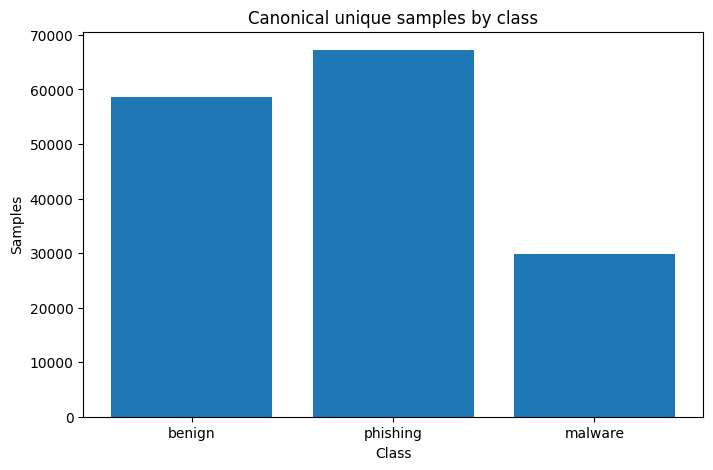

In [39]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    class_distribution.index,
    class_distribution.values,
)

ax.set_title(
    "Canonical unique samples by class"
)
ax.set_xlabel("Class")
ax.set_ylabel("Samples")

plt.show()

### 11.1 Statistiques descriptives des features de base

Les moyennes seules sont insuffisantes pour les URLs.

Les distributions lexicales sont généralement asymétriques.

On analyse donc également :

- médiane ;
- P75 ;
- P90 ;
- P95 ;
- P99 ;
- maximum.


In [40]:
descriptive_stats = (
    features_df
    .groupby(
        "label"
    )[
        NUMERIC_FEATURES
    ]
    .describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

descriptive_stats

url_length                                                                      hostname_length                                                     \
              count       mean        std   min   50%   75%    90%    95%    99%     max           count       mean        std  min   50%   75%   90%   95%   
label                                                                                                                                                         
benign      58668.0  61.272210  47.386832  17.0  47.0  70.0  110.0  135.0  220.0  2332.0         58668.0  16.149553   4.829325  4.0  16.0  19.0  22.0  25.0   
malware     29925.0  61.657043  36.146198  18.0  45.0  89.0  113.0  125.0  153.0   949.0         29925.0  16.510242   5.781628  5.0  14.0  20.0  25.0  25.0   
phishing    67225.0  57.071700  64.179896  13.0  39.0  56.0  131.0  175.0  253.0  3654.0         67225.0  20.778029  12.978998  4.0  18.0  28.0  37.0  43.0   

                      path_length                                                                    query_length                                             \
           99%    max       count       mean        std  min   50%   75%   90%    95%    99%     max        count       mean        std  min  50%  75%   90%   
label                                                                                                                                                          
benign    30.0   54.0     58668.0  32.618344  40.484106  1.0  20.0  38.0  77.0  102.0  167.0  1922.0      58668.0   4.394644  25.890936  0.0  0.0  0.0   7.0   
malware   35.0   74.0     29925.0  34.564311  33.867969  1.0  17.0  60.0  85.0   94.0  121.0   305.0      29925.0   0.931696   8.527393  0.0  0.0  0.0   0.0   
phishing  74.0  109.0     67225.0  17.218163  30.915985  1.0   7.0  14.0  60.0  108.0  108.0   997.0      67225.0  10.783340  49.945129  0.0  0.0  0.0  41.0   

                              fragment_length                                                           ... hyphen_count                                     \
           95%    99%     max           count      mean       std  min  50%  75%  90%  95%  99%    max  ...        count      mean       std  min  50%  75%   
label                                                                                                   ...                                                   
benign    23.0   92.0  2264.0         58668.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0  0.0    0.0  ...      58668.0  2.574453  4.385745  0.0  1.0  3.0   
malware    0.0   42.0   826.0         29925.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0  0.0    0.0  ...      29925.0  1.212431  1.963956  0.0  0.0  2.0   
phishing  46.0  191.0  3624.0         67225.0  0.195954  4.418746  0.0  0.0  0.0  0.0  0.0  0.0  500.0  ...      67225.0  0.920000  1.598513  0.0  0.0  1.0   

                                 digit_count                                                                  special_char_count                             \
          90%   95%   99%    max       count       mean        std  min   50%   75%   90%   95%    99%    max              count       mean        std  min   
label                                                                                                                                                         
benign    9.0  12.0  19.0  237.0     58668.0   3.619367  12.658170  0.0   0.0   4.0   8.0  14.0  50.33  698.0            58668.0  11.394150  11.763358  5.0   
malware   4.0   5.0   8.0   40.0     29925.0  13.936909   9.635866  0.0  14.0  17.0  29.0  33.0  43.00  200.0            29925.0  11.885714   4.942732  5.0   
phishing  2.0   4.0   7.0   50.0     67225.0   5.957679  12.582169  0.0   1.0   7.0  19.0  23.0  49.00  643.0            67225.0   8.933447   6.658054  5.0   

                                             path_segment_count                                                          query_parameter_count            \
          50%   75%   90%  

In [41]:
quantile_rows: list[
    dict[str, object]
] = []

for label in LABEL_ORDER:
    class_frame = (
        features_df[
            features_df[
                "label"
            ]
            == label
        ]
    )

    for feature in (
        NUMERIC_FEATURES
    ):
        series = (
            class_frame[
                feature
            ]
        )

        quantile_rows.append(
            {
                "label": label,
                "feature": feature,
                "mean": series.mean(),
                "median": series.median(),
                "p90": series.quantile(0.90),
                "p95": series.quantile(0.95),
                "p99": series.quantile(0.99),
                "max": series.max(),
            }
        )


quantile_summary = (
    pd.DataFrame(
        quantile_rows
    )
)

quantile_summary

,label,feature,mean,median,p90,p95,p99,max
0,benign,url_length,61.272210,47.0,110.0,135.0,220.00,2332
1,benign,hostname_length,16.149553,16.0,22.0,25.0,30.00,54
2,benign,path_length,32.618344,20.0,77.0,102.0,167.00,1922
3,benign,query_length,4.394644,0.0,7.0,23.0,92.00,2264
4,benign,fragment_length,0.000000,0.0,0.0,0.0,0.00,0
5,benign,dot_count,2.023897,2.0,3.0,3.0,4.00,22
6,benign,hyphen_count,2.574453,1.0,9.0,12.0,19.00,237
7,benign,digit_count,3.619367,0.0,8.0,14.0,50.33,698
8,benign,special_char_count,11.394150,9.0,19.0,23.0,52.00,655
9,benign,path_segment_count,1.911826,2.0,3.0,4.0,6.00,16


### 11.2 Distribution des features numériques de base

Pour rendre les graphiques lisibles malgré quelques URLs très longues, chaque histogramme est limité au P99 global.

Les outliers ne sont pas supprimés.

Ils seront étudiés séparément.


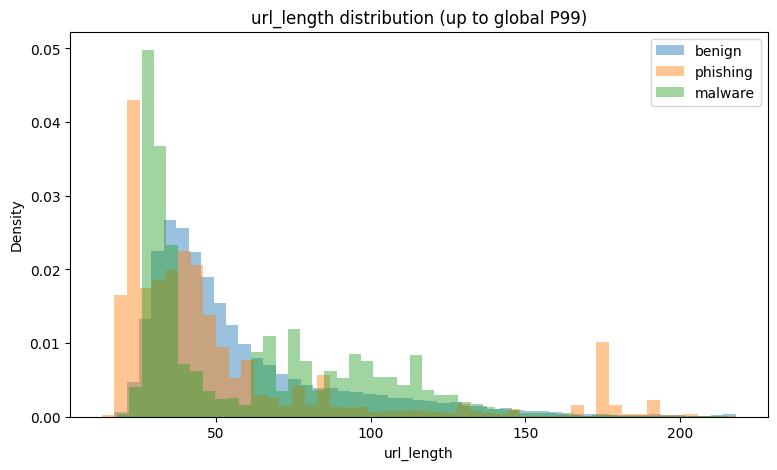

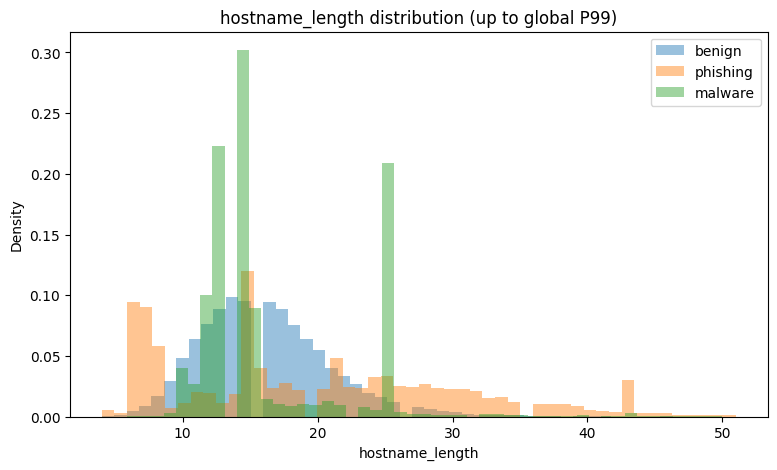

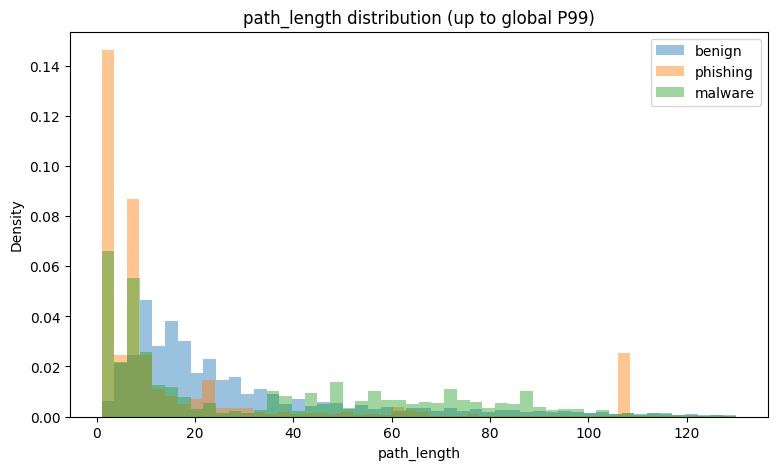

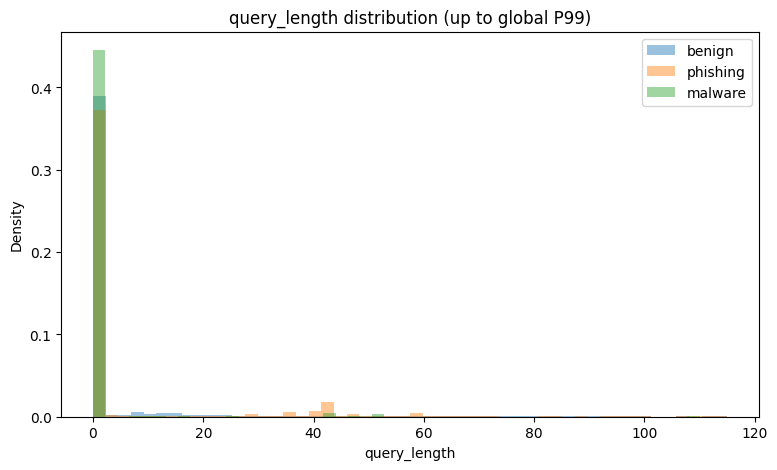

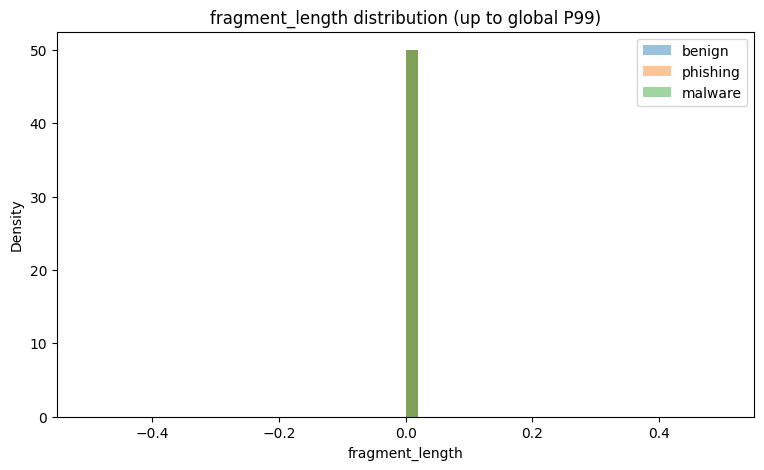

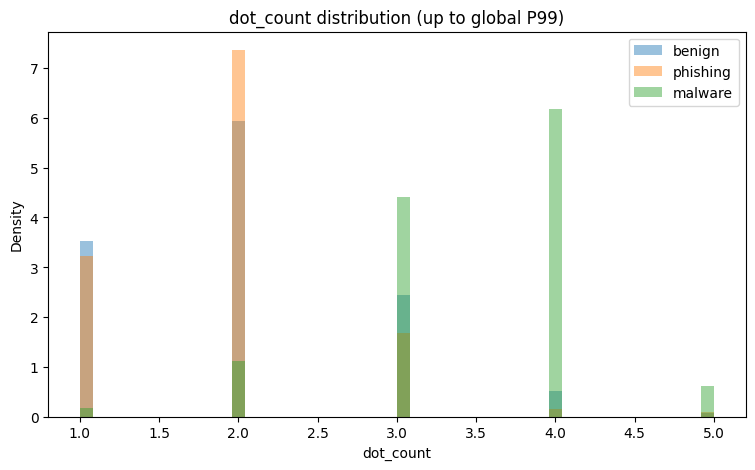

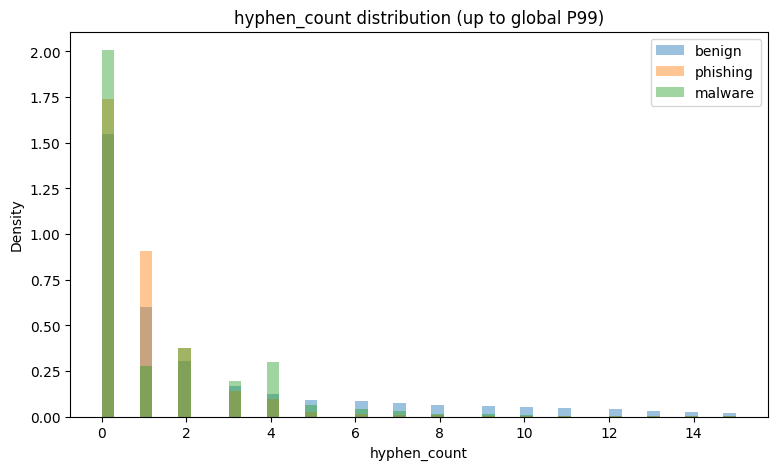

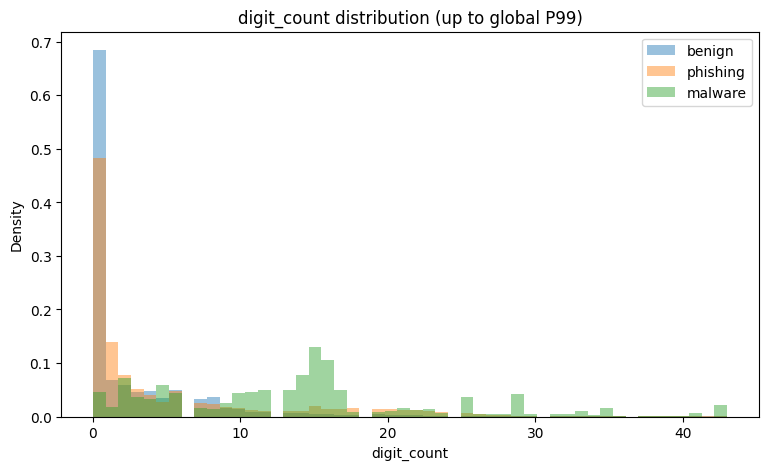

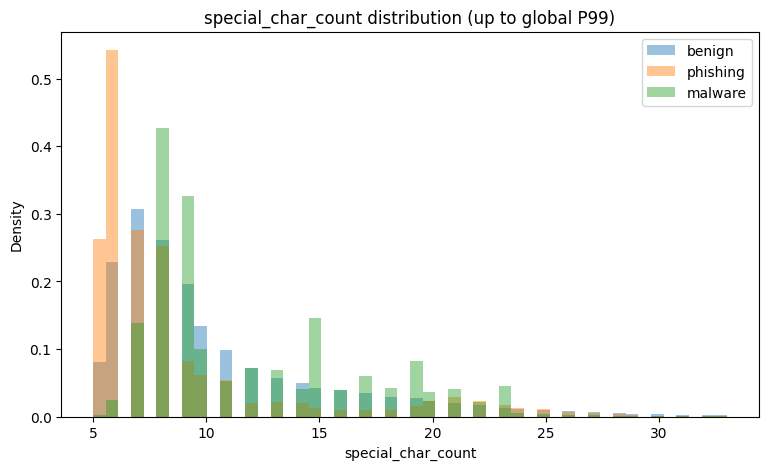

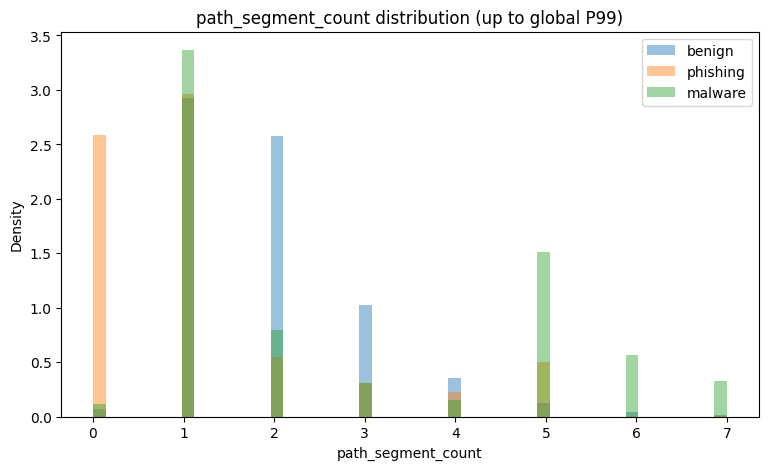

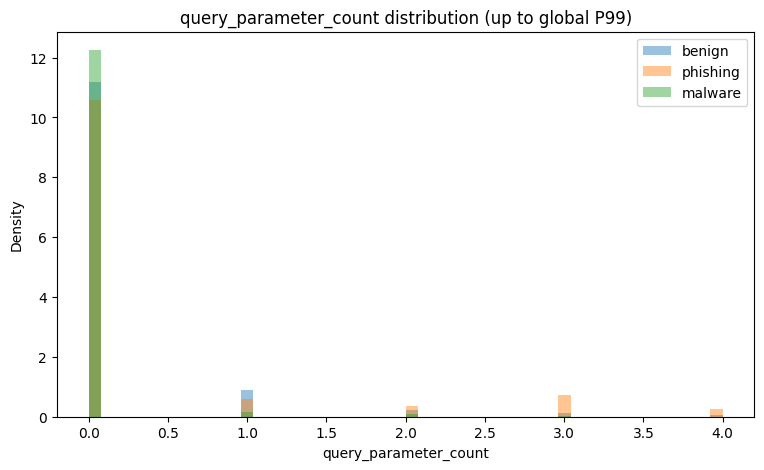

In [42]:
for feature in NUMERIC_FEATURES:
    upper = (
        features_df[
            feature
        ]
        .quantile(
            0.99
        )
    )

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )

    for label in LABEL_ORDER:
        values = (
            features_df.loc[
                features_df[
                    "label"
                ]
                == label,
                feature,
            ]
        )

        values = values[
            values <= upper
        ]

        ax.hist(
            values,
            bins=50,
            alpha=0.45,
            density=True,
            label=label,
        )

    ax.set_title(
        f"{feature} distribution "
        "(up to global P99)"
    )
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")
    ax.legend()

    plt.show()

## Interprétation des distributions des features de base

Les histogrammes suivants comparent les distributions des features numériques entre les trois classes `benign`, `phishing` et `malware`.

Pour améliorer la lisibilité, les distributions sont affichées jusqu'au **P99 global** de chaque feature. Les valeurs extrêmes au-delà de ce seuil ne sont donc pas visibles dans ces graphiques et seront étudiées séparément lors de l'analyse des outliers.

Les histogrammes sont normalisés en **densité**. Ils permettent ainsi de comparer la forme des distributions entre classes, indépendamment du nombre d'observations de chaque classe.

L'objectif à ce stade n'est pas encore de décider définitivement quelles features seront conservées, mais d'identifier :

- les features présentant des distributions différentes entre classes ;
- les features très creuses ou quasi constantes ;
- les possibles redondances ;
- les signaux susceptibles de représenter la **source des données** plutôt que la classe réelle.

---

#### `url_length`

La longueur totale des URLs présente une séparation partielle entre les classes.

Les distributions `benign` et `phishing` se chevauchent fortement dans la zone des URLs courtes à moyennes. La classe `malware` montre cependant une distribution plus étendue, avec davantage d'observations correspondant à des URLs relativement longues.

La classe `phishing` présente également quelques concentrations distinctes dans les grandes longueurs.

Cela indique que `url_length` contient probablement une information utile, mais qu'elle ne permet pas à elle seule de distinguer proprement les trois classes.

Une partie du signal peut également provenir des différences de construction des URLs entre les sources.

**Première lecture :** feature potentiellement informative, mais principalement comme composante d'un ensemble multivarié.

---

#### `hostname_length`

Les distributions de `hostname_length` diffèrent visiblement entre les classes.

Les URLs `benign` sont principalement concentrées autour de hostnames de longueur intermédiaire.

Les URLs `phishing` présentent une distribution plus étendue, incluant à la fois des hostnames relativement courts et des hostnames plus longs.

La classe `malware` présente quant à elle plusieurs pics très marqués à certaines longueurs spécifiques.

Ces concentrations discrètes suggèrent que `hostname_length` peut contenir un signal discriminant, mais elles nécessitent également de la prudence : des pics très précis peuvent provenir de structures caractéristiques de la source URLhaus plutôt que d'une propriété générale des URLs malware.

**Première lecture :** feature informative, à conserver pour les analyses multivariées et les tests de source proxy.

---

#### `path_length`

Les distributions de longueur du path montrent des différences importantes.

La classe `phishing` contient une forte proportion de paths très courts ou vides.

Les URLs `benign` sont davantage réparties sur des paths de longueur courte à moyenne.

La classe `malware` présente une distribution beaucoup plus étendue avec une proportion importante de paths longs.

Cette feature semble donc fortement informative.

Cependant, la présence de formes très spécifiques dans les distributions `phishing` et `malware` suggère encore une possible dépendance aux sources de données.

**Première lecture :** signal structurel important, mais potentiellement redondant avec `url_length`, `path_segment_count` ou les futures features relatives au path.

---

#### `query_length`

La majorité des URLs possèdent une query absente ou très courte.

Les trois classes présentent donc une forte concentration proche de zéro.

Une partie des URLs `phishing` possède cependant des queries nettement plus longues, tandis que les classes `benign` et `malware` présentent également quelques observations dispersées.

La distribution est donc fortement **zero-inflated** : une grande proportion des observations partage exactement ou presque la même valeur.

Cela limite probablement la capacité discriminante directe de cette feature.

**Première lecture :** feature relativement sparse dont l'intérêt devra être confirmé par les analyses quantitatives et multivariées.

---

#### `fragment_length`

`fragment_length` est pratiquement constant à zéro pour les trois classes.

Aucune séparation visuelle significative n'apparaît entre les distributions.

Une feature quasi constante apporte généralement très peu d'information au modèle.

**Première lecture :** très faible intérêt discriminant et candidate naturelle à l'exclusion.

---

#### `dot_count`

Le nombre de points présente une différence particulièrement visible pour la classe `malware`.

Les classes `benign` et `phishing` sont principalement concentrées autour d'un faible nombre de points, tandis que `malware` présente davantage d'observations avec trois ou quatre points.

Ce résultat doit cependant être interprété avec beaucoup de prudence.

Une URL utilisant directement une adresse IPv4 contient naturellement plusieurs points. Or la classe malware issue de URLhaus contient une proportion importante d'URLs utilisant directement des adresses IP.

La séparation observée peut donc refléter en partie :

`malware → URLhaus → utilisation fréquente d'IP`

plutôt qu'une relation générale :

`nombre de points élevé → malware`.

**Première lecture :** feature potentiellement informative, mais présentant un risque clair de `source proxy`. Elle devra être testée dans le sous-dataset contrôlé.

---

#### `hyphen_count`

Une grande partie des URLs contient peu ou pas de tirets.

La classe `phishing` présente une concentration visible autour d'un tiret, tandis que les URLs `benign` semblent posséder une queue plus étendue pour les nombres élevés de tirets.

La séparation reste toutefois beaucoup moins marquée que pour certaines autres features.

**Première lecture :** signal individuel probablement modeste, mais qui peut apporter une information complémentaire dans un modèle multivarié.

---

#### `digit_count`

La distribution de `digit_count` montre l'une des différences les plus importantes entre les classes.

Les URLs `benign` et `phishing` sont fortement concentrées autour de faibles nombres de chiffres.

La classe `malware` présente au contraire une distribution beaucoup plus étendue, avec plusieurs concentrations à des valeurs élevées et une longue queue.

Cette observation rend `digit_count` potentiellement très informative.

Elle soulève cependant également un risque important de `source proxy`.

Les URLs URLhaus peuvent contenir davantage :

- d'adresses IP ;
- de ports ;
- d'identifiants numériques ;
- de structures de chemins numériques.

Une partie importante de la séparation peut donc être spécifique à la source malware utilisée dans V1.

**Première lecture :** feature très intéressante statistiquement, mais qui devra impérativement être réévaluée après neutralisation des principaux proxies IP/HTTPS/port.

---

#### `special_char_count`

Les distributions de `special_char_count` présentent des différences visibles entre les classes.

La classe `phishing` semble davantage concentrée sur les valeurs basses.

Les classes `benign` et surtout `malware` possèdent des distributions plus étendues, avec plusieurs concentrations à des valeurs supérieures.

Cette feature représente cependant une quantité absolue et reste donc naturellement liée à `url_length`.

Une URL plus longue possède mécaniquement davantage d'opportunités de contenir des caractères spéciaux.

Cela motive également l'étude ultérieure d'une version relative :

`special_char_ratio`

qui permettra de mesurer la **densité** de caractères spéciaux plutôt que leur simple nombre.

**Première lecture :** feature potentiellement informative, à analyser conjointement avec `url_length` et sa version normalisée.

---

#### `path_segment_count`

La structure du path diffère fortement entre les classes.

Les URLs `phishing` présentent une proportion importante de paths sans segment ou très peu segmentés.

Les URLs `benign` montrent davantage de paths comportant quelques segments.

La classe `malware` présente une structure plus hétérogène, avec plusieurs concentrations correspondant à des nombres de segments plus importants.

Cette différence suggère que la segmentation du path contient une information structurelle complémentaire à sa simple longueur.

Deux URLs peuvent en effet posséder un `path_length` similaire tout en ayant des organisations très différentes :

`/very-long-single-segment`

et

`/a/b/c/d/e`

**Première lecture :** feature structurelle intéressante, potentiellement complémentaire à `path_length`.

---

#### `query_parameter_count`

La majorité des URLs des trois classes ne contient aucun paramètre de query.

La distribution est donc fortement concentrée à zéro.

La classe `phishing` présente davantage d'URLs comportant plusieurs paramètres, mais ces observations restent minoritaires.

Cette feature semble également fortement liée à `query_length` : une query comportant plusieurs paramètres tend naturellement à être plus longue.

Une redondance importante entre ces deux variables est donc plausible.

**Première lecture :** feature sparse et probablement redondante avec `query_length`, à vérifier par corrélation et ablation.

---

### Vue d'ensemble des distributions

Cette première exploration montre que les features lexicales et structurelles ne possèdent pas toutes le même niveau d'information.

Plusieurs groupes apparaissent.

#### Signaux visuellement prometteurs

Les distributions montrent des différences importantes pour :

- `url_length`
- `hostname_length`
- `path_length`
- `digit_count`
- `special_char_count`
- `path_segment_count`

Ces variables constituent de bons candidats pour les analyses quantitatives suivantes.

#### Features potentiellement faibles ou très sparse

Les distributions suggèrent une information limitée pour :

- `fragment_length`
- `query_length`
- `query_parameter_count`

`fragment_length` est particulièrement proche d'une feature constante.

#### Risque de source proxy

Certaines séparations très fortes doivent être considérées avec prudence, notamment pour :

- `dot_count`
- `digit_count`
- certaines structures de `hostname_length`
- certaines structures de `path_length`

La classe `malware` provient actuellement de URLhaus, alors que les autres classes proviennent d'autres sources.

Une différence de distribution peut donc refléter :

`classe`

mais également :

`source de collecte`.

Cette distinction ne peut pas être résolue uniquement avec les histogrammes.

---

#### Conclusion de cette étape

L'analyse visuelle montre qu'il existe suffisamment de différences structurelles entre les classes pour poursuivre une approche de classification basée sur les caractéristiques lexicales des URLs.

Cependant, aucun histogramme ne justifie à lui seul la sélection définitive d'une feature.

La suite de l'EDA devra donc compléter cette lecture visuelle par :

1. l'étude quantitative des distributions ;
2. la Mutual Information ;
3. les différences standardisées entre classes ;
4. l'analyse des corrélations et de la redondance ;
5. l'analyse des valeurs dominantes et de la sparsité ;
6. les tests spécifiques de `source proxy` ;
7. puis les ablations multivariées.

Cette progression permettra de distinguer les features réellement complémentaires des simples artefacts de source ou des représentations redondantes d'une même propriété de l'URL.

### 11.3 Boxplots et prévalence des features binaires

Les boxplots donnent une vue rapide :

- de la médiane ;
- de la dispersion ;
- de l'asymétrie ;
- des différences structurelles entre classes.


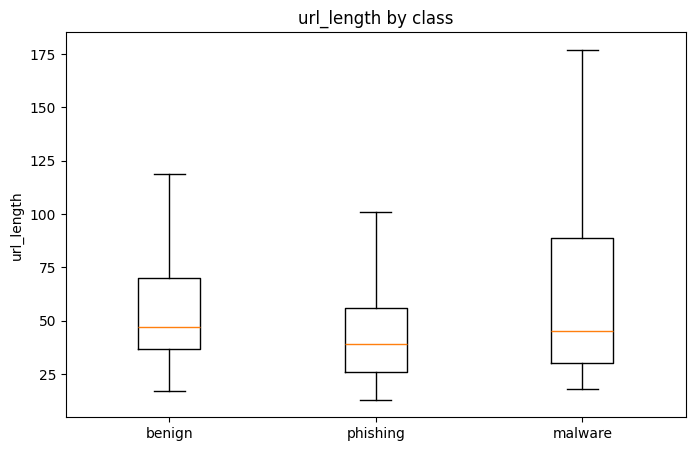

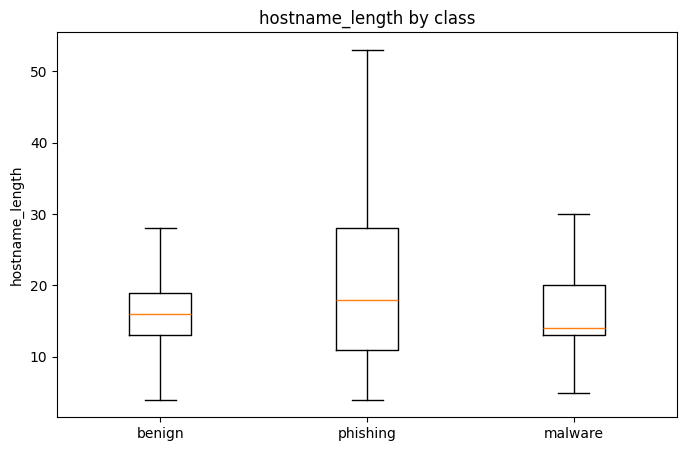

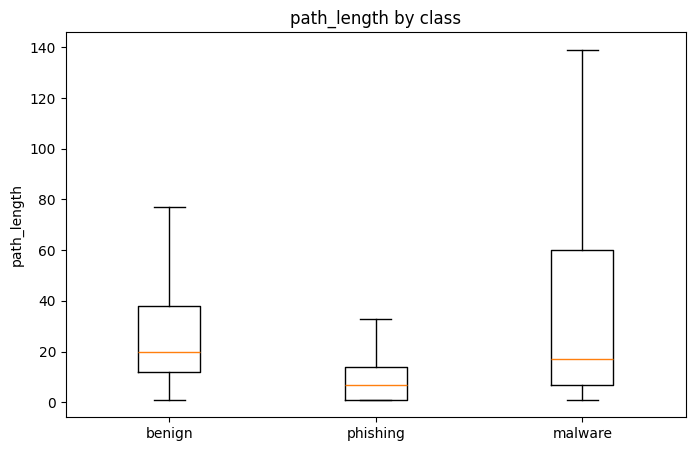

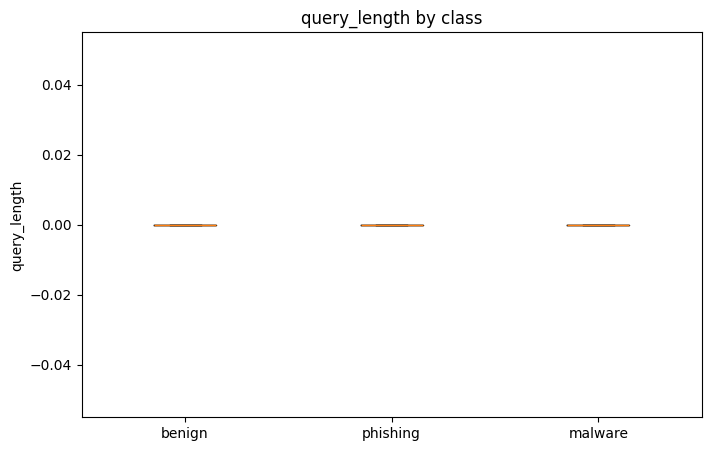

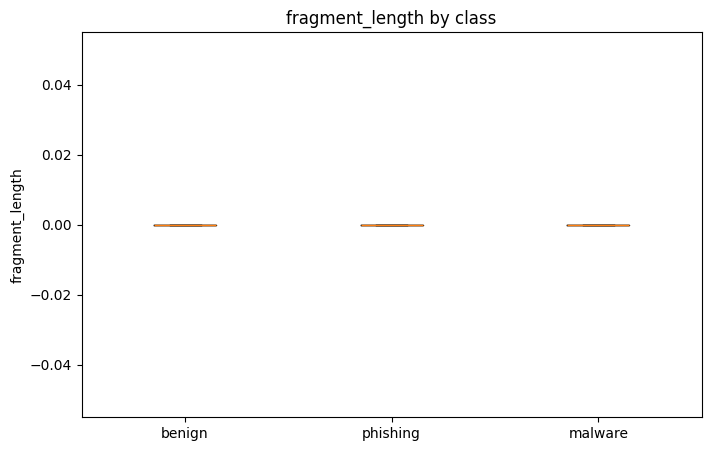

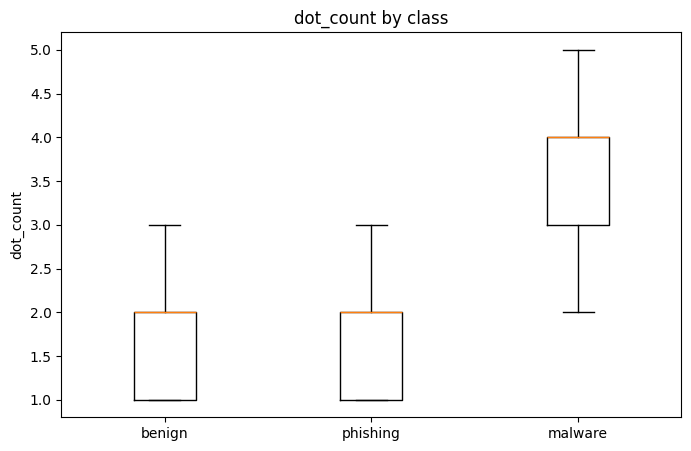

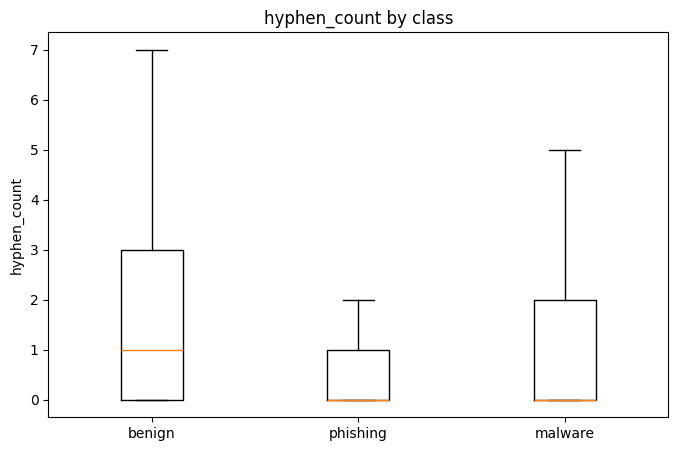

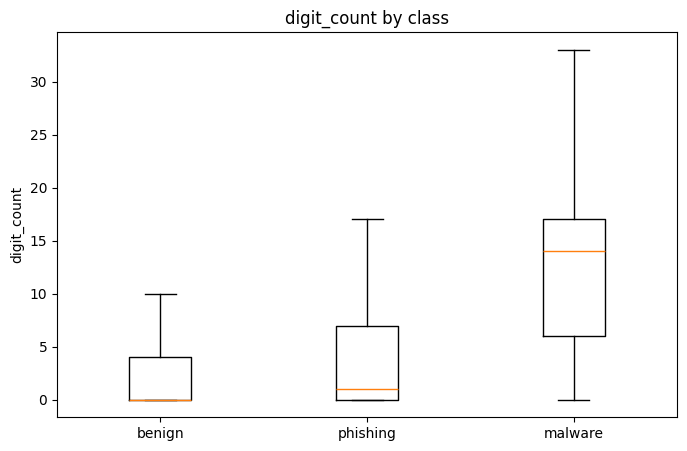

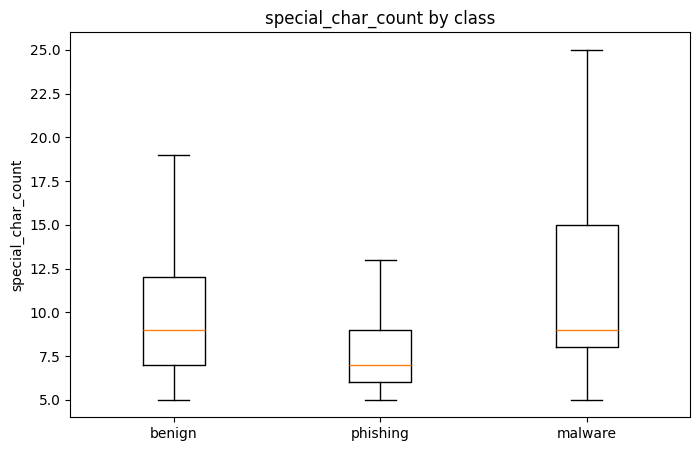

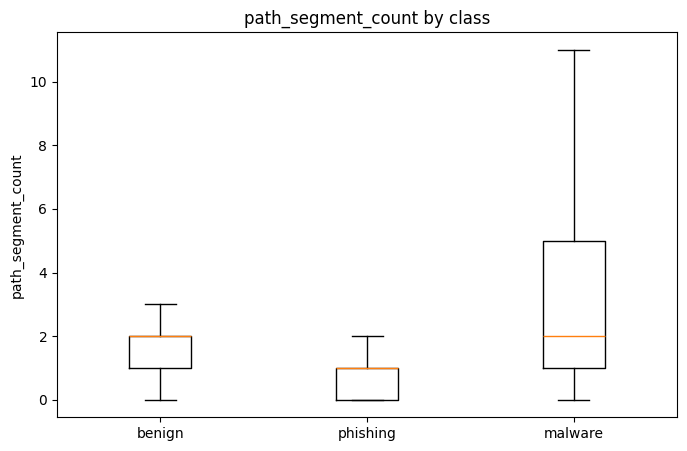

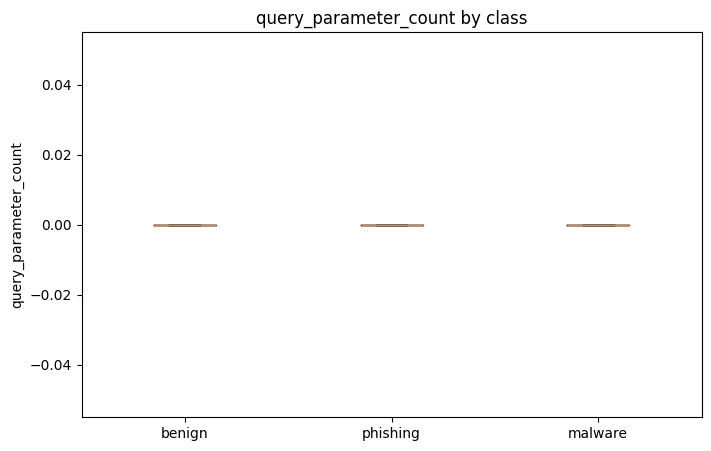

In [43]:
for feature in NUMERIC_FEATURES:
    data = [
        features_df.loc[
            features_df[
                "label"
            ]
            == label,
            feature,
        ].to_numpy()
        for label in LABEL_ORDER
    ]

    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    ax.boxplot(
        data,
        tick_labels=LABEL_ORDER,
        showfliers=False,
    )

    ax.set_title(
        f"{feature} by class"
    )
    ax.set_ylabel(feature)

    plt.show()

### Interprétation des boxplots par classe

Les boxplots complètent les histogrammes précédents en donnant une lecture plus synthétique de la **position centrale** et de la **dispersion** de chaque feature selon les classes `benign`, `phishing` et `malware`.

Ils permettent notamment d'observer :

- la médiane de chaque distribution ;
- l'intervalle interquartile, qui contient la partie centrale des observations ;
- l'étendue des valeurs représentées par les moustaches ;
- le niveau de chevauchement entre les classes.

Ils doivent toutefois être interprétés avec prudence pour les variables fortement **zero-inflated**. Lorsqu'au moins 50 à 75 % des observations valent zéro, la médiane et parfois l'ensemble de l'intervalle interquartile peuvent être égaux à zéro, même si une partie non négligeable des observations possède des valeurs positives. C'est notamment visible pour les features liées aux queries.

---

#### `url_length`

Les trois classes présentent des médianes relativement proches, mais leur dispersion diffère sensiblement.

La classe `phishing` semble globalement concentrée sur des URLs plus courtes, avec une médiane inférieure à celles des classes `benign` et `malware`.

Les distributions `benign` et `malware` possèdent des médianes comparables, mais la classe `malware` présente une dispersion nettement plus importante ainsi qu'une extension vers des URLs beaucoup plus longues.

Cela confirme l'observation faite sur les histogrammes : `url_length` contient de l'information, mais les classes restent largement chevauchantes.

**Interprétation :** la longueur totale de l'URL est probablement utile comme signal complémentaire plutôt que comme critère discriminant isolé.

---

#### `hostname_length`

La classe `phishing` présente la médiane la plus élevée ainsi que la plus forte dispersion.

Les URLs `benign` possèdent une distribution plus compacte autour de valeurs intermédiaires.

La classe `malware` semble également relativement compacte dans sa partie centrale, avec une médiane légèrement inférieure à celle des URLs `benign`, même si les histogrammes précédents révélaient plusieurs concentrations particulières qui ne sont pas directement visibles dans le boxplot.

Cette différence entre histogramme et boxplot est importante : le boxplot résume la distribution et peut masquer une structure multimodale.

**Interprétation :** `hostname_length` semble contenir un signal structurel intéressant, notamment pour `phishing`, mais son utilité doit être confirmée dans un contexte multivarié.

---

#### `path_length`

Les différences entre classes sont plus marquées.

La classe `phishing` présente une médiane faible et une dispersion relativement limitée, ce qui indique qu'une grande partie de ces URLs possède des paths courts.

Les URLs `benign` présentent des paths généralement plus longs.

La classe `malware` possède une médiane proche de celle des URLs `benign`, mais une dispersion beaucoup plus importante, avec une forte extension vers des paths longs.

Cette observation confirme que la structure du path diffère selon les classes.

**Interprétation :** `path_length` possède un signal discriminant important, mais sa forte relation potentielle avec `url_length`, `path_segment_count` et les futures features dérivées du path devra être étudiée pour éviter la redondance.

---

#### `query_length`

Le boxplot apparaît entièrement aplati autour de zéro pour les trois classes.

Cela ne signifie pas que toutes les URLs ont une query vide.

Les histogrammes précédents montraient clairement l'existence d'observations possédant des queries parfois longues.

Le résultat indique plutôt qu'une proportion suffisamment importante des URLs possède une query absente ou vide pour que :

- la médiane soit égale à zéro ;
- les quartiles soient également concentrés autour de zéro.

Le boxplot devient donc peu informatif pour cette variable.

**Interprétation :** `query_length` est fortement zero-inflated. Son analyse nécessite davantage les histogrammes, les taux de zéro et les statistiques quantitatives que le boxplot seul.

---

#### `fragment_length`

La situation est encore plus nette pour `fragment_length`.

Les trois boxplots sont entièrement concentrés à zéro.

Cela confirme que cette feature est pratiquement constante dans le dataset étudié.

Contrairement à `query_length`, les histogrammes ne montraient pas non plus de structure significative en dehors de zéro.

**Interprétation :** `fragment_length` possède très probablement un pouvoir discriminant extrêmement faible et constitue une candidate naturelle à l'exclusion.

---

#### `dot_count`

La séparation entre `malware` et les deux autres classes est particulièrement visible.

Les classes `benign` et `phishing` présentent des distributions centrales très similaires, principalement concentrées sur un faible nombre de points.

La classe `malware` possède au contraire une médiane nettement plus élevée et une distribution centrale décalée vers des valeurs supérieures.

Visuellement, il s'agit donc d'une feature très discriminante.

Cependant, cette séparation est également suspecte.

Une partie importante des URLs malware provenant de URLhaus utilise directement des adresses IPv4, ce qui augmente mécaniquement le nombre de caractères `.`.

Le boxplot peut donc révéler autant une différence de **source** qu'une différence de **classe**.

**Interprétation :** signal statistiquement fort mais présentant un risque élevé de `source proxy`. Il ne doit pas être retenu uniquement sur cette séparation visuelle.

---

#### `hyphen_count`

La majorité des URLs des trois classes contient peu de tirets.

La classe `benign` présente néanmoins une médiane légèrement supérieure et une dispersion plus importante.

Les classes `phishing` et `malware` possèdent une médiane proche de zéro, même si leurs distributions présentent quelques valeurs positives.

La séparation entre classes reste limitée par rapport aux features précédentes.

**Interprétation :** `hyphen_count` semble être une feature individuelle relativement faible, mais son information peut rester complémentaire dans un modèle multivarié.

---

#### `digit_count`

La séparation entre les classes est très importante.

Les URLs `benign` sont principalement concentrées autour de faibles nombres de chiffres.

Les URLs `phishing` présentent une médiane légèrement supérieure et une dispersion plus importante.

La classe `malware` est clairement décalée vers des valeurs beaucoup plus élevées, avec une médiane et un intervalle interquartile nettement supérieurs.

Cette différence constitue l'un des signaux visuels les plus forts de cette étape.

Cependant, comme pour `dot_count`, une interprétation prudente est nécessaire.

La présence fréquente :

- d'adresses IP ;
- de ports ;
- de chemins numériques ;
- d'identifiants numériques

dans URLhaus peut expliquer une partie de cette séparation.

**Interprétation :** `digit_count` semble fortement informative, mais représente également une candidate prioritaire pour les tests de robustesse au `source proxy`.

---

#### `special_char_count`

Les trois classes présentent des différences plus modérées.

La classe `phishing` possède une médiane légèrement inférieure et une distribution centrale plus compacte.

Les classes `benign` et `malware` présentent des médianes relativement proches.

`malware` possède cependant une dispersion plus importante et s'étend vers des valeurs supérieures.

Le chevauchement entre les trois distributions reste important.

**Interprétation :** `special_char_count` ne sépare pas directement les classes, mais semble apporter une information structurelle potentiellement utile. Son lien avec `url_length` justifie également l'étude de la feature normalisée `special_char_ratio`.

---

#### `path_segment_count`

La segmentation du path montre des différences nettes.

La classe `phishing` est principalement concentrée sur zéro ou un petit nombre de segments.

Les URLs `benign` possèdent généralement quelques segments, avec une distribution relativement compacte.

La classe `malware` présente une dispersion beaucoup plus importante, avec plusieurs URLs possédant des paths fortement segmentés.

Le boxplot confirme ainsi que `path_segment_count` ne mesure pas exactement la même information que `path_length`.

Un path peut être long tout en contenant peu de segments, ou inversement être composé de plusieurs petits segments.

**Interprétation :** `path_segment_count` constitue une feature structurelle intéressante et potentiellement complémentaire aux mesures de longueur.

---

#### `query_parameter_count`

Comme `query_length`, les boxplots sont complètement aplatis autour de zéro.

La majorité des URLs ne possède donc aucun paramètre de query, ou suffisamment peu pour que les quartiles restent nuls.

Les histogrammes précédents montrent cependant qu'il existe bien des URLs comportant un ou plusieurs paramètres.

Le boxplot ne permet donc pas à lui seul de décrire correctement cette feature.

Ce comportement renforce également l'hypothèse d'une forte redondance avec `query_length`.

**Interprétation :** feature fortement zero-inflated, probablement peu informative seule et potentiellement redondante avec `query_length`.

---

#### Vue globale apportée par les boxplots

Les boxplots confirment plusieurs observations faites avec les histogrammes, tout en apportant une lecture plus claire de la dispersion intra-classe.

Les différences les plus visibles concernent notamment :

- `dot_count` ;
- `digit_count` ;
- `path_length` ;
- `path_segment_count` ;
- dans une moindre mesure `url_length` et `hostname_length`.

À l'inverse, certaines variables apparaissent extrêmement concentrées :

- `fragment_length` ;
- `query_length` ;
- `query_parameter_count`.

Cependant, cette visualisation met aussi en évidence deux limites importantes.

Premièrement, une forte séparation visuelle n'implique pas nécessairement une bonne feature générale. `dot_count` et `digit_count` illustrent particulièrement ce problème : leur séparation de la classe `malware` pourrait être partiellement liée aux caractéristiques spécifiques de URLhaus.

Deuxièmement, les boxplots sont peu adaptés aux variables très zero-inflated. Pour `query_length` et `query_parameter_count`, ils masquent presque entièrement les observations non nulles pourtant visibles dans les histogrammes.

---

#### Transition vers l'analyse quantitative

Les histogrammes et les boxplots montrent donc qu'il existe des différences lexicales et structurelles entre les classes, mais ils ne permettent pas encore de quantifier précisément leur pouvoir discriminant.

La prochaine étape consiste à compléter cette analyse visuelle par des mesures quantitatives capables de répondre à plusieurs questions :

- quelle quantité d'information chaque feature apporte-t-elle sur le label ?
- quelles différences entre classes sont réellement importantes ?
- quelles features sont principalement constantes ou dominées par zéro ?
- quelles variables représentent essentiellement le même signal ?
- quels signaux restent présents après contrôle des principaux biais de source ?



- On étudie maintenant la prévalence binaire et sa distribution entre les 3 classes.

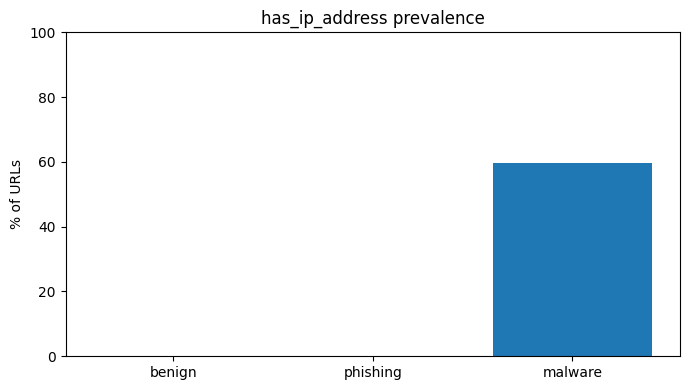

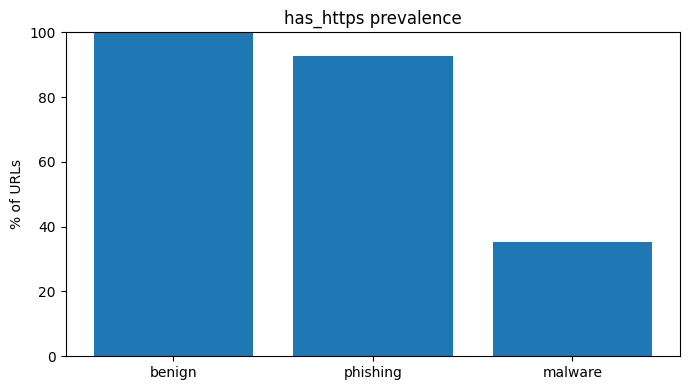

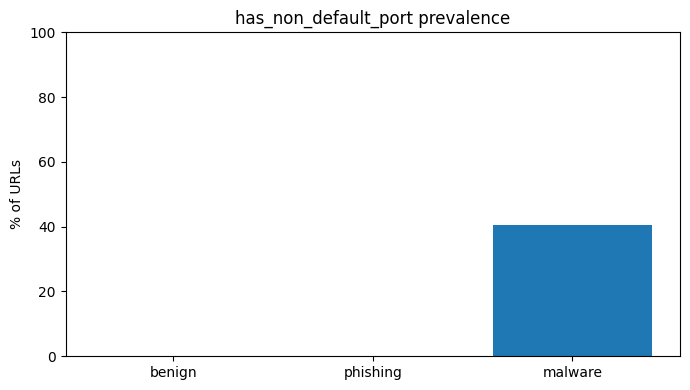

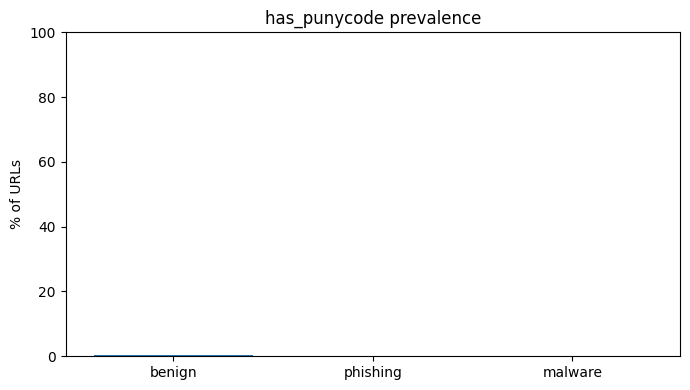

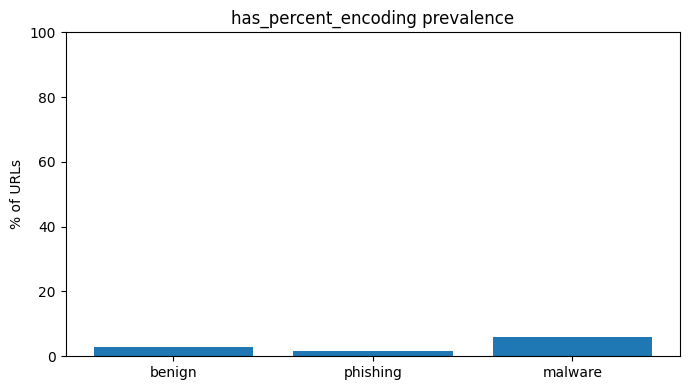

In [44]:
binary_prevalence = (
    features_df
    .groupby("label")[BINARY_FEATURES]
    .mean()
    .mul(100)
    .reindex(LABEL_ORDER)
)

for feature in BINARY_FEATURES:
    values = binary_prevalence[feature]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(values.index, values.values)
    ax.set_ylim(0, 100)
    ax.set_title(f"{feature} prevalence")
    ax.set_ylabel("% of URLs")
    plt.tight_layout()
    plt.show()


### Interprétation de la prévalence des features binaires et risque de source proxy

Les features binaires étudiées décrivent la présence ou l'absence de propriétés structurelles simples dans les URLs :

- `has_ip_address`
- `has_https`
- `has_non_default_port`
- `has_punycode`
- `has_percent_encoding`

Contrairement aux features numériques précédentes, nous n'étudions pas ici une distribution continue, mais la **prévalence** d'une propriété dans chaque classe.

Cette analyse est particulièrement importante dans notre dataset, car chaque classe principale provient actuellement d'une source différente :

```text
benign
→ HTTP Archive

phishing
→ PhishTank

malware
→ URLhaus
````

Cette structure crée un risque méthodologique important : **le label et la source sont fortement confondus**.

Une feature très présente dans une seule classe peut donc être informative pour deux raisons différentes :

```text
Feature
   ↓
propriété réellement associée à la classe
```

ou :

```text
Feature
   ↓
propriété caractéristique de la source
   ↓
source presque équivalente au label dans notre dataset
```

Dans le second cas, le modèle peut apprendre à reconnaître la provenance statistique d'une URL plutôt que sa nature réellement `benign`, `phishing` ou `malware`.

Il s'agit principalement d'un problème de **source-label confounding** ou de **source proxy**.

Ce phénomène est proche d'une fuite d'information dans ses conséquences, mais il est important de ne pas le confondre avec un `data leakage` classique : aucune colonne `source` n'est directement fournie au modèle. Le problème est que certaines features peuvent agir comme des **identifiants indirects de la source**.

---

#### `has_ip_address`

La prévalence observée est extrêmement différente entre les classes :

```text
benign      ≈ 0.000 %
phishing    ≈ 0.149 %
malware     ≈ 59.709 %
```

Près de 60 % des URLs de la classe `malware` utilisent directement une adresse IP comme hostname, alors que cette propriété est pratiquement absente des classes `benign` et `phishing`.

Statistiquement, cette feature serait donc extrêmement attractive pour un classifieur.

Un modèle pourrait facilement apprendre une règle proche de :

```text
has_ip_address = True
→ forte probabilité de malware
```

Cependant, dans le dataset actuel :

```text
malware
→ URLhaus
```

Nous ne disposons pas encore de plusieurs sources indépendantes de malware permettant de déterminer si cette proportion est représentative de la population malware générale.

Il est donc possible que le modèle apprenne en réalité :

```text
has_ip_address = True
→ URL ressemblant fortement aux observations URLhaus
→ malware dans le dataset d'entraînement
```

plutôt qu'une relation véritablement généralisable.

Le problème est encore plus important car l'utilisation directe d'une IPv4 influence mécaniquement plusieurs autres features.

Une adresse telle que :

```text
192.0.2.42
```

contient naturellement :

* plusieurs caractères `.`;
* beaucoup de chiffres ;
* une structure de hostname particulière.

Ainsi, `has_ip_address` peut indirectement expliquer une partie des séparations observées sur :

* `dot_count`
* `digit_count`
* `hostname_length`

Le risque de source proxy ne concerne donc pas uniquement la feature binaire elle-même : il peut contaminer plusieurs signaux lexicaux corrélés.

**Interprétation :** `has_ip_address` est extrêmement discriminante dans le dataset actuel, mais présente un risque majeur de source proxy. Elle ne doit pas être considérée comme une feature robuste simplement parce qu'elle sépare fortement la classe `malware`.

---

#### `has_https`

La prévalence observée est également très différente :

```text
benign      ≈ 99.652 %
phishing    ≈ 92.797 %
malware     ≈ 35.425 %
```

La quasi-totalité des URLs `benign` provenant de HTTP Archive utilisent HTTPS.

La majorité des URLs `phishing` utilisent également HTTPS.

À l'inverse, seulement environ un tiers des URLs `malware` provenant de URLhaus utilisent HTTPS.

Un modèle pourrait donc apprendre une règle implicite proche de :

```text
HTTPS
→ plutôt benign / phishing

HTTP
→ plutôt malware
```

Cette règle pourrait produire d'excellentes performances sur un dataset conservant la même composition de sources.

Elle serait cependant particulièrement dangereuse en production.

HTTPS ne constitue pas une preuve de légitimité. Une infrastructure malveillante peut parfaitement utiliser TLS et un certificat valide.

La séparation observée peut donc refléter davantage les caractéristiques des trois mécanismes de collecte que les classes elles-mêmes :

```text
HTTP Archive
→ Web moderne largement HTTPS

PhishTank
→ nombreuses pages de phishing également HTTPS

URLhaus
→ davantage d'infrastructures HTTP observées dans notre échantillon
```

Le modèle risquerait ainsi d'apprendre une propriété de l'écosystème de collecte actuel.

Cette feature présente également un **risque de généralisation temporelle** : l'utilisation de HTTPS continue d'évoluer, y compris dans les infrastructures malveillantes.

**Interprétation :** `has_https` possède un fort pouvoir discriminant sur le dataset actuel, mais cette séparation est trop fortement liée à la composition des sources pour constituer un signal V1 fiable.

---

#### `has_non_default_port`

La prévalence observée est encore plus asymétrique :

```text
benign      ≈ 0.034 %
phishing    ≈ 0.021 %
malware     ≈ 40.571 %
```

Les ports non standards sont pratiquement absents des classes `benign` et `phishing`, alors qu'ils apparaissent dans une part très importante des URLs `malware`.

Un classifieur pourrait donc facilement apprendre :

```text
has_non_default_port = True
→ malware
```

Il est plausible que certaines infrastructures malveillantes utilisent effectivement plus souvent des ports non standards.

Cependant, notre dataset actuel ne permet pas de déterminer si cette caractéristique correspond à :

```text
une propriété générale des URLs malware
```

ou :

```text
une propriété fréquente des URLs actuellement collectées par URLhaus
```

Cette feature est également susceptible d'être corrélée avec :

* `has_ip_address`
* `has_https`
* `digit_count`
* certaines structures de `url_length`

Elle peut donc participer à un ensemble de signaux permettant au modèle d'identifier indirectement URLhaus.

**Interprétation :** `has_non_default_port` constitue un source proxy particulièrement préoccupant et ne doit pas être retenu uniquement sur la base de sa forte séparation entre classes.

---

#### Effet combiné de `has_ip_address`, `has_https` et `has_non_default_port`

Le risque devient encore plus important lorsque ces trois features sont considérées simultanément.

Une partie importante des URLs malware de notre dataset présente un profil proche de :

```text
IP directe
+
HTTP
+
port non standard
```

alors que le benign HTTP Archive présente beaucoup plus souvent un profil proche de :

```text
hostname DNS
+
HTTPS
+
port standard
```

Ces propriétés combinées peuvent former une véritable **signature de source**.

Le modèle pourrait alors apprendre implicitement :

```text
IP + HTTP + port non standard
≈ URLhaus
≈ malware
```

Cette stratégie pourrait produire de très bonnes métriques sur des données possédant la même structure de collecte.

Mais elle pourrait échouer sur une URL malware provenant d'une autre source avec un profil parfaitement moderne :

```text
https://example-domain.tld/...
+
hostname DNS
+
port 443
```

Inversement, une infrastructure légitime utilisant une adresse IP, HTTP ou un port non standard pourrait être artificiellement orientée vers `malware`.

Pour une plateforme de Threat Intelligence destinée à recevoir des données provenant de sources hétérogènes, ce comportement serait particulièrement problématique.

Ces trois features sont donc considérées comme les **principaux signaux suspects de source proxy identifiés pendant cette phase EDA**.

---

#### `has_punycode`

La prévalence de Punycode est extrêmement faible dans les trois classes :

```text
benign      ≈ 0.252 %
phishing    ≈ 0.122 %
malware     ≈ 0.013 %
```

Contrairement aux trois variables précédentes, aucune classe ne présente une prévalence importante.

La feature est donc très sparse.

Le Punycode peut être pertinent dans certains scénarios particuliers, notamment pour représenter certains noms de domaine internationalisés, mais notre dataset actuel contient trop peu d'observations pour en faire un signal statistique robuste.

Il serait notamment incorrect de conclure :

```text
Punycode
→ phishing
```

à partir de ces données.

La prévalence observée est même légèrement supérieure dans la classe `benign`.

**Interprétation :** feature rare et faiblement informative dans ce dataset. Elle ne présente pas le même danger de source proxy massif que les trois variables précédentes, mais sa sparsité limite fortement son intérêt pour V1.

---

#### `has_percent_encoding`

La prévalence observée reste faible dans les trois classes :

```text
benign      ≈ 2.971 %
phishing    ≈ 1.531 %
malware     ≈ 6.052 %
```

La classe `malware` utilise plus fréquemment du percent-encoding, mais l'écart est beaucoup moins extrême que pour :

* `has_ip_address`
* `has_https`
* `has_non_default_port`

Cette feature peut représenter certaines particularités lexicales ou structurelles des URLs.

Cependant, elle reste relativement rare dans l'ensemble du dataset.

Par ailleurs, la simple présence d'un caractère percent-encoded ne constitue pas en soi une propriété malveillante. L'encodage `%xx` est un mécanisme standard des URLs et peut apparaître dans du trafic parfaitement légitime.

Une fréquence supérieure dans URLhaus pourrait donc encore provenir partiellement de la composition de la source.

**Interprétation :** signal légèrement différencié mais sparse, avec une valeur individuelle limitée. La différence observée ne justifie pas à elle seule son intégration dans le Feature Set V1.

---

#### Vue globale du risque de source proxy

Cette analyse fait apparaître deux groupes très différents de features binaires.

Les trois variables les plus préoccupantes sont :

```text
has_ip_address
has_https
has_non_default_port
```

Elles présentent simultanément :

* de très fortes différences de prévalence entre classes ;
* une séparation particulièrement forte de `malware` ;
* une forte plausibilité de dépendance à URLhaus ;
* des effets indirects possibles sur d'autres features lexicales.

Elles constituent donc les principaux candidats à un phénomène de :

```text
source
↓
feature
↓
label
```

alors que nous souhaitons apprendre une relation :

```text
propriétés intrinsèques de l'URL
↓
classe
```

Les deux autres variables :

```text
has_punycode
has_percent_encoding
```

présentent un problème différent : elles sont surtout rares et relativement peu discriminantes dans le dataset actuel.

---

#### Conséquence méthodologique pour la suite de l'EDA

Cette observation modifie directement la manière dont les autres features doivent être évaluées.

Il ne suffit plus de mesurer leur Mutual Information sur le dataset complet.

Certaines variables continues comme :

* `digit_count`
* `dot_count`
* `hostname_digit_ratio`
* éventuellement certaines longueurs

peuvent récupérer indirectement le même signal que :

```text
has_ip_address
has_https
has_non_default_port
```

Nous devons donc créer un **proxy-controlled subset** dans lequel les principaux raccourcis sont neutralisés :

```text
has_ip_address = False
has_https = True
has_non_default_port = False
```

Puis réévaluer les features sur cette population plus homogène.

L'objectif n'est pas de prétendre que ce filtrage supprime tout biais de source.

Il permet seulement de répondre à une question plus précise :

> une feature conserve-t-elle de l'information lorsque les trois différences structurelles les plus évidentes entre URLhaus et les autres sources sont neutralisées ?

Une feature dont l'information s'effondre après ce contrôle sera considérée avec beaucoup plus de prudence.

À l'inverse, une feature qui reste informative dans le sous-dataset contrôlé possède davantage de chances de représenter un signal lexical ou structurel complémentaire.

---

#### Limite importante : ce contrôle ne supprime pas totalement le source-label confounding

Même après neutralisation de :

```text
has_ip_address
has_https
has_non_default_port
```

la structure fondamentale du dataset reste :

```text
HTTP Archive
→ benign

PhishTank
→ phishing

URLhaus
→ malware
```

Il est donc impossible, avec ce dataset seul, de démontrer qu'une feature est totalement indépendante de la source.

Le proxy-controlled stress test est une **mesure de robustesse**, pas une preuve d'absence de biais.

Une validation beaucoup plus forte nécessitera ultérieurement plusieurs sources indépendantes pour une même classe, par exemple :

```text
malware source A
malware source B
malware source C
```

afin de pouvoir tester si les signaux appris persistent indépendamment de l'origine des données.

---

#### Conclusion

L'analyse de la prévalence des features binaires révèle le premier risque méthodologique majeur de l'EDA : certaines caractéristiques extrêmement discriminantes semblent également fortement associées à la source de collecte.

En particulier :

```text
has_ip_address
has_https
has_non_default_port
```

pourraient permettre au modèle de reconnaître indirectement URLhaus et donc d'obtenir artificiellement de bonnes performances sur la classe `malware`.

Ces features ne seront donc pas considérées comme des signaux fiables simplement en raison de leur forte séparation statistique.

Cette observation motive directement l'étape suivante de l'EDA : **tester les features dans un environnement proxy-controlled**, afin d'identifier celles dont le pouvoir discriminant subsiste lorsque les raccourcis de source les plus évidents sont neutralisés.


### 11.4 Analyse des outliers

Un outlier n'est pas nécessairement une anomalie.

Une URL malveillante peut légitimement être :

- extrêmement longue ;
- profondément imbriquée ;
- fortement encodée ;
- composée de nombreux paramètres.

L'objectif est donc d'identifier les extrêmes avant de décider d'un éventuel clipping pour le modèle.


In [45]:
outlier_rows = []

for label in LABEL_ORDER:
    class_frame = (
        features_df[
            features_df[
                "label"
            ]
            == label
        ]
    )

    for feature in (
        NUMERIC_FEATURES
    ):
        series = (
            class_frame[
                feature
            ]
        )

        p99 = series.quantile(0.99)
        p999 = series.quantile(0.999)

        outlier_rows.append(
            {
                "label": label,
                "feature": feature,
                "p99": p99,
                "p99_9": p999,
                "max": series.max(),
                "above_p99": int(
                    (
                        series
                        > p99
                    )
                    .sum()
                ),
            }
        )


outlier_summary = (
    pd.DataFrame(
        outlier_rows
    )
)

outlier_summary

,label,feature,p99,p99_9,max,above_p99
0,benign,url_length,220.00,474.999,2332,566
1,benign,hostname_length,30.00,38.000,54,515
2,benign,path_length,167.00,370.999,1922,580
3,benign,query_length,92.00,272.000,2264,584
4,benign,fragment_length,0.00,0.000,0,0
5,benign,dot_count,4.00,7.000,22,448
6,benign,hyphen_count,19.00,29.000,237,460
7,benign,digit_count,50.33,137.000,698,587
8,benign,special_char_count,52.00,138.000,655,582
9,benign,path_segment_count,6.00,8.000,16,222



### Résumé de l'analyse des outliers

L'analyse des quantiles extrêmes montre que plusieurs features possèdent des distributions fortement asymétriques avec des queues longues, en particulier :

- `url_length`
- `path_length`
- `query_length`
- `hyphen_count`
- `digit_count`
- `special_char_count`

Les écarts entre `P99`, `P99.9` et `max` confirment la présence de valeurs rares parfois très éloignées du cœur de distribution. Par exemple, certaines URLs `benign` ou `phishing` atteignent plusieurs milliers de caractères alors que leur P99 reste inférieur à quelques centaines.

Ces valeurs extrêmes ne sont cependant pas nécessairement des anomalies. Elles peuvent correspondre à des URLs valides comportant :

- de longues queries ;
- des paths volumineux ;
- de nombreux paramètres ;
- des identifiants numériques ;
- des structures lexicales atypiques.

L'analyse montre également que les valeurs extrêmes ne sont pas exclusivement associées aux classes malveillantes. Certaines des valeurs maximales les plus importantes apparaissent dans `benign` ou `phishing`. Il serait donc incorrect d'utiliser des seuils arbitraires comme règle de nettoyage ou comme proxy de malveillance.

`fragment_length` présente un comportement différent : elle est constante à zéro pour `benign` et `malware` et presque toujours nulle pour `phishing`. Son problème principal est donc la très faible variance plutôt que la présence d'outliers.

`query_length` et `query_parameter_count` combinent quant à elles deux caractéristiques :

- une forte concentration à zéro ;
- une petite proportion de valeurs très élevées.

Elles sont donc fortement `zero-inflated`, ce qui explique pourquoi les boxplots précédents représentaient mal leur distribution réelle.

#### Stratégie retenue

La stratégie V1 est de **ne pas supprimer automatiquement les outliers statistiques**.

La règle retenue est :

```text
valeur extrême
+
URL valide
+
feature correctement calculée
→ conservation
````

En revanche :

```text
valeur impossible
ou
donnée corrompue
ou
incohérence avec l'URL canonique
→ rejet ou correction au niveau du pipeline de qualité
```

Aucun clipping ou seuil basé sur le label ne sera appliqué, car cela pourrait introduire une fuite d'information.

Si certaines valeurs extrêmes posent un problème pendant l'entraînement, leur traitement sera réalisé explicitement dans le pipeline ML, par exemple avec :

* une transformation robuste ;
* éventuellement `log1p` pour certaines variables positives fortement asymétriques ;
* ou un modèle moins sensible aux différences d'échelle.

Toute transformation devra être ajustée uniquement sur le jeu d'entraînement.

#### Décision EDA

Les outliers valides sont donc **conservés dans le dataset**.

L'objectif est de préserver la diversité réelle des URLs et d'éviter un nettoyage agressif qui supprimerait potentiellement des cas rares mais importants pour une plateforme de Threat Intelligence.

Le traitement éventuel de leur influence est reporté à la phase de modélisation, où il pourra être évalué proprement avec les métriques de performance, de stabilité et de généralisation.



### 11.5 Concentration par hostname et risque de leakage de split

Une mauvaise séparation train/test peut produire un résultat artificiellement élevé si plusieurs URLs du même domaine sont réparties entre train et test.

On ne construit pas encore le split ici.

On mesure cependant la concentration des URLs par hostname afin d'évaluer ce risque.

Le dataset final utilisera un `group_key` basé sur le registered domain, ou l'IP normalisée lorsque le hostname est une IP.


In [46]:
hostname_concentration_rows = []

for label in LABEL_ORDER:
    class_frame = (
        features_df[
            features_df[
                "label"
            ]
            == label
        ]
    )

    counts = (
        class_frame[
            "hostname"
        ]
        .value_counts()
    )

    hostname_concentration_rows.append(
        {
            "label": label,
            "unique_hostnames": (
                counts.size
            ),
            "mean_urls_per_hostname": (
                counts.mean()
            ),
            "median_urls_per_hostname": (
                counts.median()
            ),
            "p95_urls_per_hostname": (
                counts.quantile(
                    0.95
                )
            ),
            "max_urls_per_hostname": (
                counts.max()
            ),
            "top_10_hostname_share_pct": (
                counts
                .head(10)
                .sum()
                / counts.sum()
                * 100
            ),
        }
    )


hostname_concentration = (
    pd.DataFrame(
        hostname_concentration_rows
    )
)

hostname_concentration

,label,unique_hostnames,mean_urls_per_hostname,median_urls_per_hostname,p95_urls_per_hostname,max_urls_per_hostname,top_10_hostname_share_pct
0,benign,58667,1.000017,1.0,1.0,2,0.018750
1,phishing,34690,1.937878,1.0,2.0,5550,33.353663
2,malware,7773,3.849865,1.0,6.0,5489,39.645781


### Résumé de la concentration des URLs par hostname

L'analyse montre des profils très différents selon les classes.

Pour `benign`, la distribution est presque parfaitement diffuse :

- `58 667` hostnames uniques ;
- environ `1` URL par hostname en moyenne ;
- médiane = `1` ;
- P95 = `1` ;
- maximum = `2` ;
- les 10 hostnames les plus fréquents représentent seulement `0.019 %` des URLs.

Cela indique que la classe `benign` contient pratiquement une URL différente par hostname, avec très peu de répétition.

À l'inverse, `phishing` et `malware` présentent une forte concentration.

Pour `phishing` :

- `34 690` hostnames uniques ;
- moyenne ≈ `1.94` URL par hostname ;
- médiane = `1` ;
- maximum = `5 550` URLs pour un même hostname ;
- les 10 hostnames les plus fréquents représentent environ `33.35 %` des URLs.

Pour `malware` :

- seulement `7 773` hostnames uniques ;
- moyenne ≈ `3.85` URLs par hostname ;
- médiane = `1` ;
- P95 = `6` ;
- maximum = `5 489` URLs pour un même hostname ;
- les 10 hostnames les plus fréquents représentent environ `39.65 %` des URLs.

Ces résultats montrent donc une forte asymétrie :

```text
benign
→ très forte diversité de hostnames
→ très faible répétition

phishing / malware
→ présence de hostnames très dominants
→ nombreuses URLs rattachées aux mêmes infrastructures
````

Cette concentration représente un risque important de **data leakage entre train et test** si les URLs sont réparties aléatoirement ligne par ligne.

Dans ce cas, plusieurs URLs appartenant au même hostname pourraient apparaître simultanément dans le train et dans le test. Le modèle pourrait alors apprendre des caractéristiques spécifiques à une infrastructure déjà vue plutôt que généraliser vers de nouveaux domaines.

La stratégie de split doit donc être **group-aware**.

Le `hostname` peut être utilisé pendant l'EDA comme approximation prudente, mais le split final sera plus strict et basé sur le **registered domain**, afin de maintenir dans le même groupe les sous-domaines appartenant à une même entité DNS.

Pour les URLs utilisant directement une adresse IP :

```text
group_key = normalized_ip
```

Cette analyse confirme donc que le futur split ML ne devra pas être réalisé par tirage aléatoire simple des URLs.



### 11.6 Analyse temporelle

La dimension temporelle peut être importante pour éviter un futur leakage.

Pour les menaces :

- PhishTank utilise prioritairement `verification_time` ;
- URLhaus utilise `date_added`.

HTTP Archive correspond à un snapshot déterminé.

Les timestamps ne seront **pas utilisés comme features**.

Ils servent uniquement à préparer plus tard une stratégie de split temporel éventuelle.


In [47]:
features_df[
    "observed_at"
] = pd.to_datetime(
    features_df[
        "observed_at"
    ],
    utc=True,
    errors="coerce",
)

temporal_summary = (
    features_df
    .groupby(
        "label"
    )[
        "observed_at"
    ]
    .agg(
        [
            "min",
            "max",
            "count",
        ]
    )
    .reindex(
        LABEL_ORDER
    )
)

temporal_summary

,min,max,count
label,,,
benign,2026-07-01 00:00:00+00:00,2026-07-01 00:00:00+00:00,58668
phishing,2011-02-19 00:05:43+00:00,2026-07-31 15:12:34+00:00,67225
malware,2018-06-05 22:09:14+00:00,2026-08-10 13:51:21+00:00,29925


In [48]:
temporal_frame = (
    features_df[
        features_df[
            "observed_at"
        ]
        .notna()
    ]
    .copy()
)

temporal_frame[
    "month"
] = (
    temporal_frame[
        "observed_at"
    ]
    .dt
    .to_period("M")
    .astype(str)
)

monthly_counts = (
    temporal_frame
    .groupby(
        [
            "label",
            "month",
        ]
    )
    .size()
    .rename(
        "records"
    )
    .reset_index()
)

monthly_counts.tail(
    20
)

C:\Users\J.P.M\AppData\Local\Temp\ipykernel_12776\3413815518.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .to_period("M")


,label,month,records
170,phishing,2024-12,1007
171,phishing,2025-01,702
172,phishing,2025-02,513
173,phishing,2025-03,845
174,phishing,2025-04,860
175,phishing,2025-05,775
176,phishing,2025-06,510
177,phishing,2025-07,1124
178,phishing,2025-08,1517
179,phishing,2025-09,1039


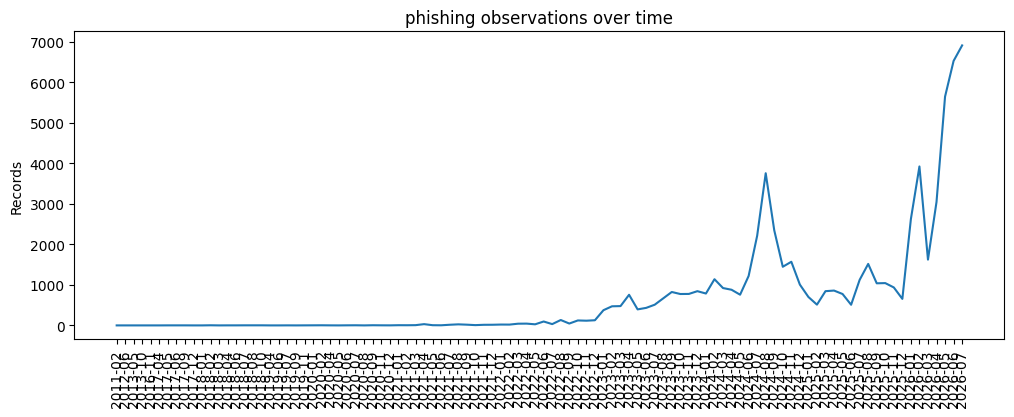

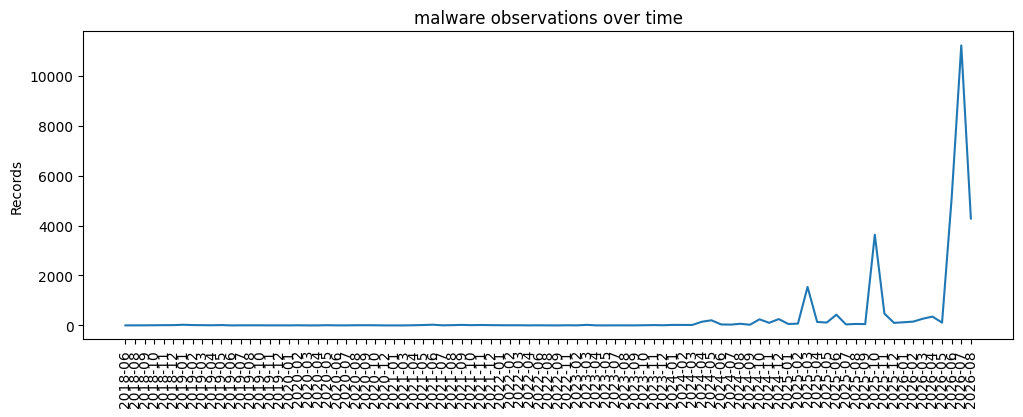

In [49]:
for label in [
    "phishing",
    "malware",
]:
    frame = (
        monthly_counts[
            monthly_counts[
                "label"
            ]
            == label
        ]
    )

    if frame.empty:
        continue

    fig, ax = plt.subplots(
        figsize=(12, 4)
    )

    ax.plot(
        frame["month"],
        frame["records"],
    )

    ax.set_title(
        f"{label} observations over time"
    )
    ax.set_ylabel("Records")
    ax.tick_params(
        axis="x",
        rotation=90,
    )

    plt.show()

### Résumé de la couverture temporelle des classes

L'analyse temporelle montre que les trois classes ne possèdent **pas la même profondeur historique** :

```text
benign
→ uniquement 2026-07-01
→ 58 668 observations

phishing
→ de 2011-02 à 2026-07
→ 67 225 observations

malware
→ de 2018-06 à 2026-08
→ 29 925 observations
````

La classe `benign` constitue donc un **snapshot temporel unique**, correspondant au crawl HTTP Archive de juillet 2026, alors que `phishing` et `malware` couvrent plusieurs années.

Pour `phishing`, les données les plus récentes sont nettement plus représentées : les volumes augmentent fortement en 2026, avec notamment plus de `5 000` observations par mois entre mai et juillet. Le dataset contient donc un historique long, mais sa masse principale est beaucoup plus récente.

Cette asymétrie crée un nouveau risque de **confounding temporel** :

```text
classe
↕
source
↕
période d'observation
```

Le modèle ne doit donc recevoir **aucune feature temporelle directe** permettant d'utiliser l'année, le mois ou l'ancienneté comme raccourci de classification.

Il serait par exemple dangereux qu'il apprenne implicitement :

```text
observation datée exactement de juillet 2026
→ probablement benign
```

alors que cette propriété provient du mode de construction du dataset HTTP Archive et non de la nature intrinsèque d'une URL légitime.

Cette structure limite également la possibilité d'effectuer immédiatement un simple split temporel commun aux trois classes : `benign` ne possède actuellement aucune profondeur historique permettant de construire un train et un test temporel représentatifs.

#### Décision pour V1

Les timestamps restent des **métadonnées de provenance et d'audit**, mais ne font pas partie des features ML.

Le snapshot final devra conserver dans son manifest :

* la période couverte par chaque source ;
* la date du snapshot HTTP Archive ;
* les bornes temporelles des observations phishing et malware.

La validation V1 reposera principalement sur un split **group-aware par registered domain**, tandis qu'une véritable validation temporelle sera considérée comme une étape ultérieure lorsque plusieurs snapshots temporels comparables seront disponibles pour les différentes classes.

Cette analyse met donc en évidence une limite importante du dataset actuel : au-delà du `source-label confounding`, nous devons également surveiller un **source-time confounding** susceptible de produire une généralisation artificiellement optimiste.



### De la qualité descriptive à la sélection des features

Les contrôles précédents établissent la qualité générale du Feature Dataset et les principaux risques de concentration, d'outliers et de temporalité. Nous pouvons maintenant comparer quantitativement les features candidates selon leur information, leur redondance et leur robustesse face aux sources.

### 12.1 Contrôle de faisabilité des features expérimentales
Avant même d'étudier les performances statistiques, vérifions que ces features sont correctement calculées.


In [50]:
experimental_feasibility_rows = []

for feature in EXPERIMENTAL_FEATURES:
    series = (
        features_df[
            feature
        ]
    )

    frequencies = (
        series
        .value_counts(
            normalize=True,
            dropna=False,
        )
    )

    dominant_share = (
        float(
            frequencies.iloc[0]
        )
        if not frequencies.empty
        else 1.0
    )

    experimental_feasibility_rows.append(
        {
            "feature": feature,
            "dtype": str(
                series.dtype
            ),
            "missing": int(
                series
                .isna()
                .sum()
            ),
            "unique_values": int(
                series
                .nunique(
                    dropna=False
                )
            ),
            "dominant_value_share_pct": (
                dominant_share
                * 100
            ),
            "min": (
                float(
                    series.min()
                )
            ),
            "max": (
                float(
                    series.max()
                )
            ),
        }
    )


experimental_feasibility = (
    pd.DataFrame(
        experimental_feasibility_rows
    )
    .sort_values(
        "dominant_value_share_pct",
        ascending=False,
    )
)

experimental_feasibility

,feature,dtype,missing,unique_values,dominant_value_share_pct,min,max
20,max_consecutive_special_chars,int64,0,13,99.893465,3.000000,102.000000
11,percent_encoding_count,int64,0,141,97.058748,0.000000,615.000000
16,query_to_url_length_ratio,float64,0,3704,88.509030,0.000000,0.991790
1,hostname_hyphen_count,int64,0,12,81.731892,0.000000,11.000000
2,hostname_digit_count,int64,0,41,71.700317,0.000000,44.000000
14,hostname_digit_ratio,float64,0,641,71.700317,0.000000,0.800000
6,path_digit_count,int64,0,178,63.590856,0.000000,636.000000
0,hostname_dot_count,int64,0,8,54.933961,1.000000,8.000000
3,hostname_label_count,int64,0,8,54.933961,2.000000,9.000000
8,path_slash_count,int64,0,19,52.284717,1.000000,102.000000


#### Remarques : 
- Ces résultats sont utiles pour un premier filtrage, mais ils ne sont pas suffisants pour décider définitivement quelles features garder.
- Une feature peut varier énormément et ne rien apporter pour distinguer les classes.

### 12.2 Périmètre des features analysées


In [51]:
ALL_FEATURES = [
    *FEATURE_COLUMNS,
    *EXPERIMENTAL_FEATURES,
]

if len(ALL_FEATURES) != len(set(ALL_FEATURES)):
    raise RuntimeError(
        "Duplicate feature names detected"
    )

missing_features = [
    feature
    for feature in ALL_FEATURES
    if feature not in features_df.columns
]

if missing_features:
    raise RuntimeError(
        "Some analysis features are missing"
    )

print(
    "Total candidate features:",
    len(ALL_FEATURES),
)

print(
    "Base features:",
    len(FEATURE_COLUMNS),
)

print(
    "Experimental features:",
    len(EXPERIMENTAL_FEATURES),
)

Total candidate features: 37
Base features: 16
Experimental features: 21


### 12.3 Focus sur les distributions numériques par classe


In [52]:
ANALYSIS_NUMERIC_FEATURES = [
    feature
    for feature in ALL_FEATURES
    if feature not in BINARY_FEATURES
]


distribution_rows = []

for feature in ANALYSIS_NUMERIC_FEATURES:
    for label, group in features_df.groupby(
        "label",
        sort=False,
    ):
        series = (
            group[feature]
            .dropna()
        )

        quantiles = (
            series.quantile(
                [
                    0.10,
                    0.25,
                    0.50,
                    0.75,
                    0.90,
                    0.99,
                ]
            )
        )

        distribution_rows.append(
            {
                "feature": feature,
                "class": label,
                "count": int(
                    series.size
                ),
                "mean": float(
                    series.mean()
                ),
                "std": float(
                    series.std()
                ),
                "p10": float(
                    quantiles.loc[0.10]
                ),
                "p25": float(
                    quantiles.loc[0.25]
                ),
                "median": float(
                    quantiles.loc[0.50]
                ),
                "p75": float(
                    quantiles.loc[0.75]
                ),
                "p90": float(
                    quantiles.loc[0.90]
                ),
                "p99": float(
                    quantiles.loc[0.99]
                ),
            }
        )


class_distribution_summary = (
    pd.DataFrame(
        distribution_rows
    )
)

class_distribution_summary.head(
    15
)

,feature,class,count,mean,std,p10,p25,median,p75,p90,p99
0,url_length,benign,58668,61.272210,47.386832,31.0,37.0,47.0,70.0,110.0,220.0
1,url_length,phishing,67225,57.071700,64.179896,22.0,26.0,39.0,56.0,131.0,253.0
2,url_length,malware,29925,61.657043,36.146198,28.0,30.0,45.0,89.0,113.0,153.0
3,hostname_length,benign,58668,16.149553,4.829325,10.0,13.0,16.0,19.0,22.0,30.0
4,hostname_length,phishing,67225,20.778029,12.978998,7.0,11.0,18.0,28.0,37.0,74.0
5,hostname_length,malware,29925,16.510242,5.781628,12.0,13.0,14.0,20.0,25.0,35.0
6,path_length,benign,58668,32.618344,40.484106,8.0,12.0,20.0,38.0,77.0,167.0
7,path_length,phishing,67225,17.218163,30.915985,1.0,1.0,7.0,14.0,60.0,108.0
8,path_length,malware,29925,34.564311,33.867969,2.0,7.0,17.0,60.0,85.0,121.0
9,query_length,benign,58668,4.394644,25.890936,0.0,0.0,0.0,0.0,7.0,92.0


In [53]:
#visualisation de distribution par classe

DISTRIBUTION_FEATURES = [
    "url_length",
    "hostname_length",
    "path_length",
    "query_length",
    "fragment_length",
]

CLASS_ORDER = [
    "benign",
    "phishing",
    "malware",
]

In [54]:
def plot_feature_distribution(
    frame: pd.DataFrame,
    feature: str,
) -> None:
    """
    Compare une feature entre classes.

    L'affichage est borné au P99 global afin
    d'éviter que quelques valeurs extrêmes
    rendent le graphique illisible.
    """
    upper_bound = float(
        frame[
            feature
        ].quantile(
            0.99
        )
    )

    plot_data = [
        frame.loc[
            frame["label"] == label,
            feature,
        ]
        .clip(
            upper=upper_bound
        )
        .to_numpy()
        for label in CLASS_ORDER
    ]

    fig, ax = plt.subplots(
        figsize=(
            8,
            5,
        )
    )

    ax.boxplot(
        plot_data,
        tick_labels=CLASS_ORDER,
        showfliers=False,
    )

    ax.set_title(
        f"{feature} distribution by class — clipped at P99"
    )

    ax.set_xlabel(
        "Class"
    )

    ax.set_ylabel(
        feature
    )

    ax.grid(
        axis="y",
        alpha=0.2,
    )

    plt.tight_layout()
    plt.show()

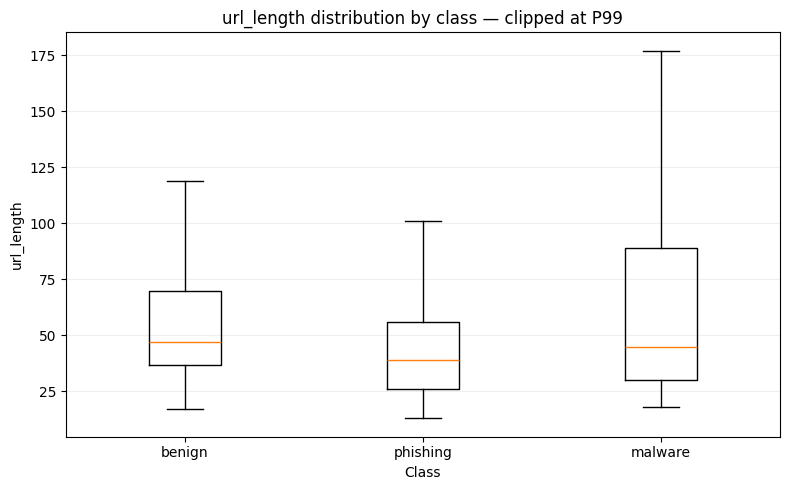

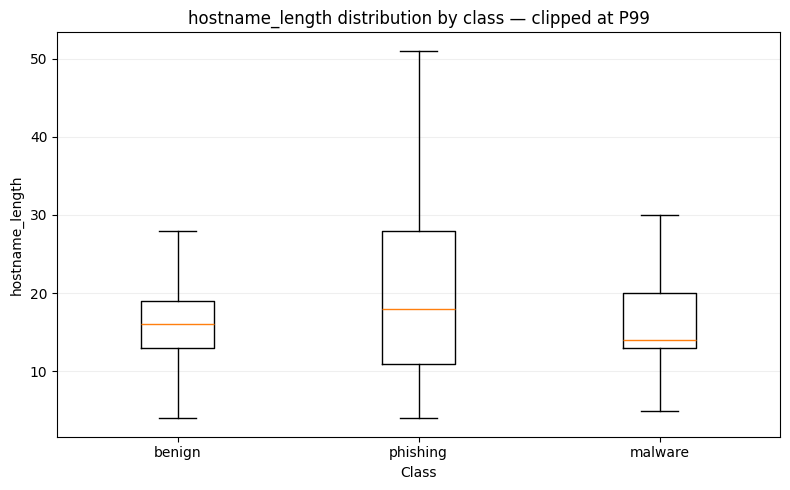

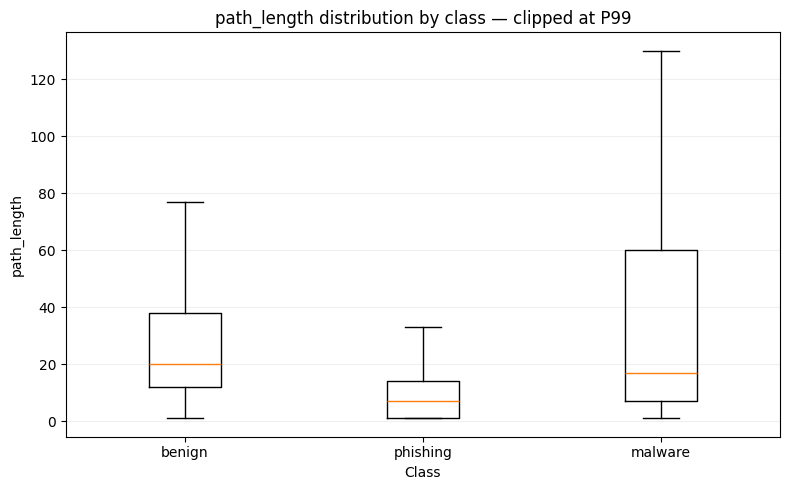

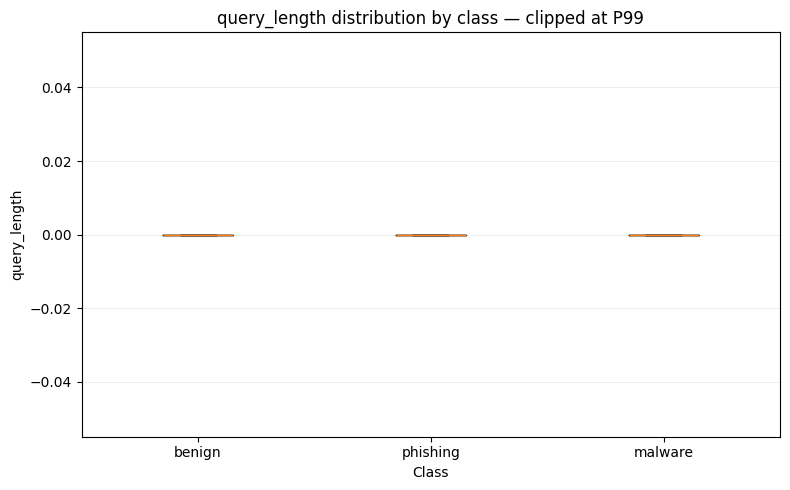

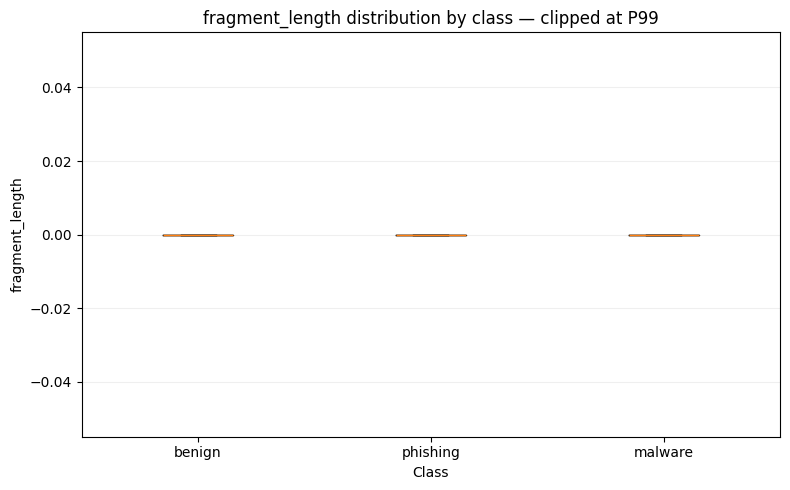

In [55]:
for feature in DISTRIBUTION_FEATURES:
    plot_feature_distribution(
        features_df,
        feature,
    )

### Interprétation des distributions par classe

Les premières statistiques montrent que les features lexicales ne se comportent pas de manière identique entre les trois classes.

`hostname_length` et `path_length` présentent notamment des différences visibles entre benign, phishing et malware. `query_length` est généralement nulle, mais sa distribution supérieure est nettement plus importante pour le phishing, ce qui peut constituer un signal discriminant.

À l'inverse, `fragment_length` est quasiment toujours nulle et apparaît pour l'instant comme une feature très sparse.

Ces observations restent exploratoires : une différence de distribution ne garantit pas qu'une feature soit utile au modèle. Les prochaines analyses devront mesurer son pouvoir discriminant, sa redondance avec les autres variables et son éventuel lien avec la source de collecte.


### 12.4 Prévalence des features binaires par classe


In [56]:
binary_prevalence_rows = []

for feature in BINARY_FEATURES:
    for label, group in features_df.groupby(
        "label",
        sort=False,
    ):
        prevalence = (
            group[feature]
            .astype(bool)
            .mean()
        )

        binary_prevalence_rows.append(
            {
                "feature": feature,
                "class": label,
                "true_pct": (
                    float(prevalence)
                    * 100
                ),
                "false_pct": (
                    float(
                        1.0 - prevalence
                    )
                    * 100
                ),
            }
        )


binary_prevalence_by_class = (
    pd.DataFrame(
        binary_prevalence_rows
    )
)

binary_prevalence_by_class

,feature,class,true_pct,false_pct
0,has_ip_address,benign,0.000000,100.000000
1,has_ip_address,phishing,0.148754,99.851246
2,has_ip_address,malware,59.709273,40.290727
3,has_https,benign,99.652281,0.347719
4,has_https,phishing,92.797322,7.202678
5,has_https,malware,35.425230,64.574770
6,has_non_default_port,benign,0.034090,99.965910
7,has_non_default_port,phishing,0.020826,99.979174
8,has_non_default_port,malware,40.571429,59.428571
9,has_punycode,benign,0.252267,99.747733


### Interprétation des features binaires

Les features binaires présentent des comportements très différents selon les classes.

`has_ip_address`, `has_https` et `has_non_default_port` montrent des écarts particulièrement importants entre malware et les deux autres classes. Ces variables peuvent donc être fortement discriminantes, mais elles présentent également un **risque élevé de source leakage**, car chaque classe provient actuellement d'une source de collecte différente.

`has_punycode` est très rare dans l'ensemble du dataset et son utilité devra être confirmée. `has_percent_encoding` présente une variation plus modérée entre les classes et reste une candidate intéressante.

Aucune feature n'est supprimée à ce stade : ces résultats seront confrontés aux analyses de corrélation, de Mutual Information et de leakage avant la sélection finale du Feature Set V1.


### 12.5 SMD de référence sur les 16 features de base

Cette première lecture du SMD sert de référence sur le Feature Set de base. La section suivante étend ensuite exactement la même logique à l'ensemble des features candidates, y compris les 21 variables expérimentales.

On mesure ici la différence de moyenne relativement à la dispersion des deux populations.

Cette métrique ne constitue pas une décision finale mais aide à identifier :

- les features peu discriminantes ;
- les features extrêmement discriminantes ;
- les features qui pourraient refléter un biais de source.


In [57]:
def standardized_mean_difference(
    first: pd.Series,
    second: pd.Series,
) -> float:
    first = (
        first
        .astype(float)
        .dropna()
    )

    second = (
        second
        .astype(float)
        .dropna()
    )

    if (
        len(first) < 2
        or len(second) < 2
    ):
        return 0.0

    pooled_variance = (
        (
            first.var(
                ddof=1
            )
            + second.var(
                ddof=1
            )
        )
        / 2
    )

    if pooled_variance <= 0:
        return 0.0

    return float(
        (
            first.mean()
            - second.mean()
        )
        / np.sqrt(
            pooled_variance
        )
    )

In [58]:
pairwise_rows = []

comparisons = [
    (
        "benign",
        "phishing",
    ),
    (
        "benign",
        "malware",
    ),
    (
        "phishing",
        "malware",
    ),
]

for feature in (
    NUMERIC_FEATURES
    + BINARY_FEATURES
):
    for first_label, second_label in comparisons:
        first = (
            features_df.loc[
                features_df[
                    "label"
                ]
                == first_label,
                feature,
            ]
        )

        second = (
            features_df.loc[
                features_df[
                    "label"
                ]
                == second_label,
                feature,
            ]
        )

        smd = (
            standardized_mean_difference(
                first,
                second,
            )
        )

        pairwise_rows.append(
            {
                "feature": feature,
                "comparison": (
                    f"{first_label}"
                    f" ↔ "
                    f"{second_label}"
                ),
                "standardized_difference": smd,
                "absolute_difference": abs(smd),
            }
        )


pairwise_difference = (
    pd.DataFrame(
        pairwise_rows
    )
    .sort_values(
        "absolute_difference",
        ascending=False,
    )
)

pairwise_difference

,feature,comparison,standardized_difference,absolute_difference
37,has_https,benign ↔ malware,1.884835,1.884835
34,has_ip_address,benign ↔ malware,-1.721576,1.721576
16,dot_count,benign ↔ malware,-1.720164,1.720164
35,has_ip_address,phishing ↔ malware,-1.712010,1.712010
17,dot_count,phishing ↔ malware,-1.640118,1.640118
38,has_https,phishing ↔ malware,1.492312,1.492312
41,has_non_default_port,phishing ↔ malware,-1.167373,1.167373
40,has_non_default_port,benign ↔ malware,-1.166671,1.166671
22,digit_count,benign ↔ malware,-0.917198,0.917198
29,path_segment_count,phishing ↔ malware,-0.892910,0.892910


### 12.6 Séparation entre classes avec le SMD


In [59]:
from itertools import combinations


LABELS = [
    "benign",
    "phishing",
    "malware",
]


def standardized_mean_difference(
    left: pd.Series,
    right: pd.Series,
) -> float:
    left = (
        left
        .dropna()
        .astype(float)
    )

    right = (
        right
        .dropna()
        .astype(float)
    )

    left_variance = (
        left.var()
    )

    right_variance = (
        right.var()
    )

    pooled_std = np.sqrt(
        (
            left_variance
            + right_variance
        )
        / 2.0
    )

    if (
        not np.isfinite(
            pooled_std
        )
        or pooled_std == 0
    ):
        return 0.0

    return float(
        (
            left.mean()
            - right.mean()
        )
        / pooled_std
    )

In [60]:
smd_rows = []

for feature in ALL_FEATURES:
    for left_label, right_label in combinations(
        LABELS,
        2,
    ):
        left = features_df.loc[
            features_df["label"]
            == left_label,
            feature,
        ]

        right = features_df.loc[
            features_df["label"]
            == right_label,
            feature,
        ]

        smd = (
            standardized_mean_difference(
                left,
                right,
            )
        )

        smd_rows.append(
            {
                "feature": feature,
                "comparison": (
                    f"{left_label} ↔ "
                    f"{right_label}"
                ),
                "smd": smd,
                "abs_smd": abs(
                    smd
                ),
            }
        )


pairwise_smd = (
    pd.DataFrame(
        smd_rows
    )
    .sort_values(
        "abs_smd",
        ascending=False,
    )
)

pairwise_smd.head(
    30
)

,feature,comparison,smd,abs_smd
37,has_https,benign ↔ malware,1.884835,1.884835
85,digit_ratio,benign ↔ malware,-1.788616,1.788616
34,has_ip_address,benign ↔ malware,-1.721576,1.721576
16,dot_count,benign ↔ malware,-1.720164,1.720164
91,hostname_digit_ratio,benign ↔ malware,-1.715943,1.715943
35,has_ip_address,phishing ↔ malware,-1.712010,1.712010
55,hostname_digit_count,benign ↔ malware,-1.698966,1.698966
17,dot_count,phishing ↔ malware,-1.640118,1.640118
92,hostname_digit_ratio,phishing ↔ malware,-1.509815,1.509815
38,has_https,phishing ↔ malware,1.492312,1.492312


In [61]:
feature_max_smd = (
    pairwise_smd
    .groupby(
        "feature",
        as_index=False,
    )
    .agg(
        max_abs_smd=(
            "abs_smd",
            "max",
        )
    )
    .sort_values(
        "max_abs_smd",
        ascending=False,
    )
)

feature_max_smd

,feature,max_abs_smd
4,has_https,1.884835
1,digit_ratio,1.788616
5,has_ip_address,1.721576
2,dot_count,1.720164
10,hostname_digit_ratio,1.715943
9,hostname_digit_count,1.698966
11,hostname_dot_count,1.203928
14,hostname_label_count,1.203928
6,has_non_default_port,1.167373
29,path_to_url_length_ratio,1.045085


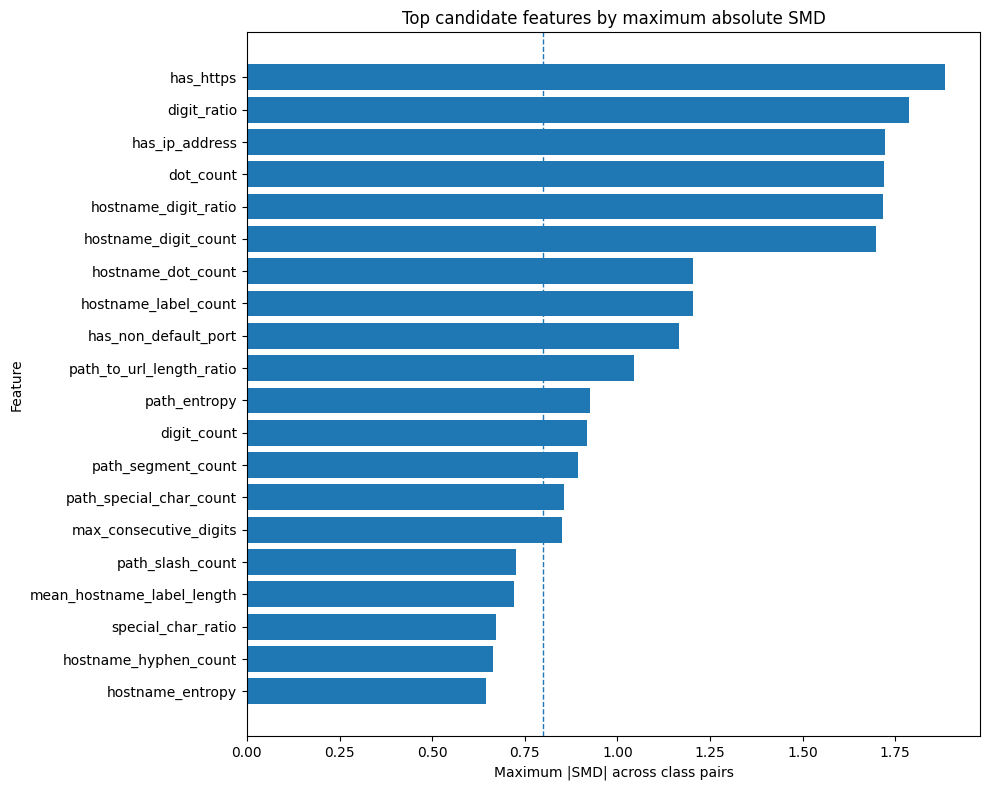

In [62]:
#visualisation de meilleur SMD par feature
top_smd_features = (
    feature_max_smd
    .head(20)
    .sort_values(
        "max_abs_smd",
        ascending=True,
    )
)

fig, ax = plt.subplots(
    figsize=(
        10,
        8,
    )
)

ax.barh(
    top_smd_features[
        "feature"
    ],
    top_smd_features[
        "max_abs_smd"
    ],
)

ax.axvline(
    0.8,
    linestyle="--",
    linewidth=1,
)

ax.set_title(
    "Top candidate features by maximum absolute SMD"
)

ax.set_xlabel(
    "Maximum |SMD| across class pairs"
)

ax.set_ylabel(
    "Feature"
)

plt.tight_layout()
plt.show()

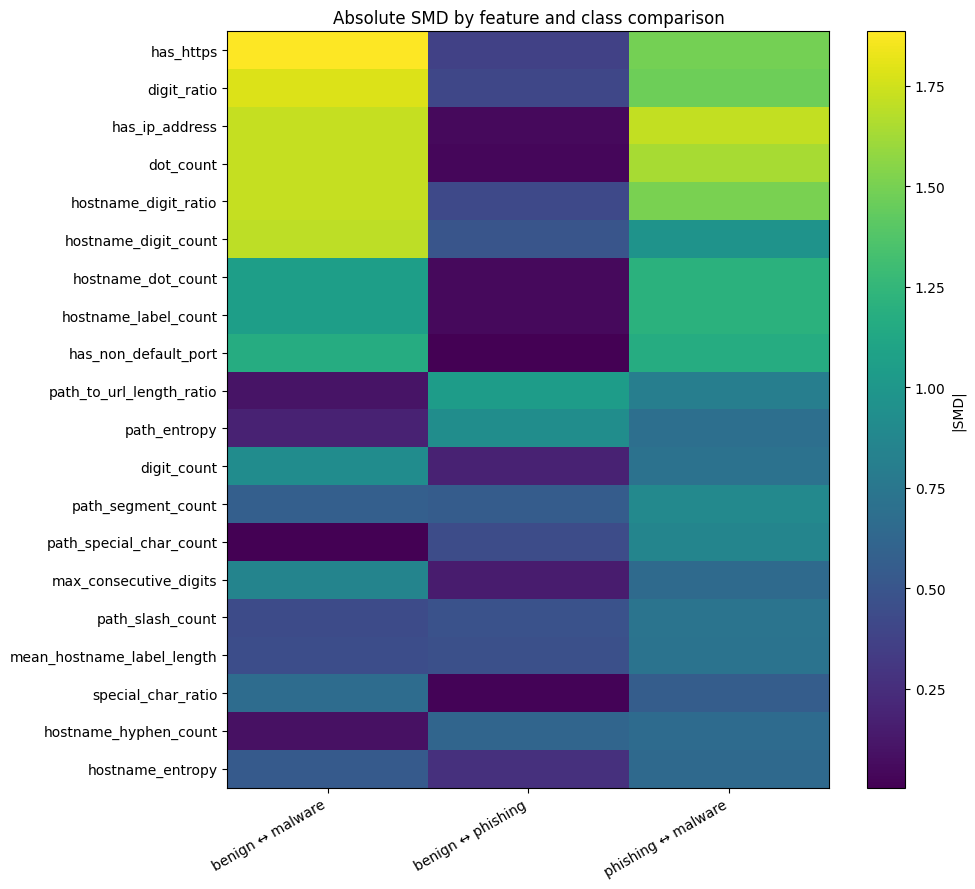

In [63]:
#séparation selon chaque paire de classes
smd_matrix = (
    pairwise_smd
    .pivot(
        index="feature",
        columns="comparison",
        values="abs_smd",
    )
    .fillna(0.0)
)

smd_matrix[
    "max_abs_smd"
] = (
    smd_matrix.max(
        axis=1
    )
)

top_features = (
    smd_matrix
    .sort_values(
        "max_abs_smd",
        ascending=False,
    )
    .head(20)
    .drop(
        columns=[
            "max_abs_smd",
        ]
    )
)

fig, ax = plt.subplots(
    figsize=(
        10,
        9,
    )
)

image = ax.imshow(
    top_features,
    aspect="auto",
)

ax.set_xticks(
    range(
        len(
            top_features.columns
        )
    )
)

ax.set_xticklabels(
    top_features.columns,
    rotation=30,
    ha="right",
)

ax.set_yticks(
    range(
        len(
            top_features.index
        )
    )
)

ax.set_yticklabels(
    top_features.index
)

ax.set_title(
    "Absolute SMD by feature and class comparison"
)

fig.colorbar(
    image,
    ax=ax,
    label="|SMD|",
)

plt.tight_layout()
plt.show()

### Interprétation de la séparation entre classes

Le Standardized Mean Difference met en évidence plusieurs features présentant une forte séparation entre les classes.

Les écarts les plus importants concernent principalement les comparaisons impliquant la classe `malware`, notamment pour `has_https`, `has_ip_address`, `digit_ratio`, `dot_count`, `hostname_digit_ratio` et `has_non_default_port`.

Ces features semblent donc fortement discriminantes, mais ce résultat doit être interprété avec prudence : la classe malware provient actuellement de URLhaus, tandis que les autres classes utilisent des sources différentes. Une forte séparation peut ainsi refléter partiellement les caractéristiques de la source de collecte plutôt que la nature malveillante de l'URL.

Le SMD constitue donc un indicateur de pouvoir discriminant, mais ne suffit pas à sélectionner une feature. Les prochaines analyses de corrélation, Mutual Information et source leakage permettront de confirmer leur pertinence pour le Feature Set V1.


### 12.7 Corrélations et redondance


In [64]:
spearman_correlation = (
    features_df[
        ALL_FEATURES
    ]
    .corr(
        method="spearman"
    )
)

spearman_correlation.shape

(37, 37)

In [65]:
# extraction des corrélations fortes 
strong_correlation_rows = []

for index, left_feature in enumerate(
    ALL_FEATURES
):
    for right_feature in ALL_FEATURES[
        index + 1:
    ]:
        correlation = float(
            spearman_correlation.loc[
                left_feature,
                right_feature,
            ]
        )

        if (
            np.isfinite(
                correlation
            )
            and abs(
                correlation
            ) >= 0.90
        ):
            strong_correlation_rows.append(
                {
                    "feature_1": (
                        left_feature
                    ),
                    "feature_2": (
                        right_feature
                    ),
                    "spearman": (
                        correlation
                    ),
                    "abs_spearman": abs(
                        correlation
                    ),
                }
            )


strong_correlations = (
    pd.DataFrame(
        strong_correlation_rows
    )
)

if not strong_correlations.empty:
    strong_correlations = (
        strong_correlations
        .sort_values(
            "abs_spearman",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )

strong_correlations

,feature_1,feature_2,spearman,abs_spearman
0,hostname_dot_count,hostname_label_count,1.000000,1.000000
1,has_percent_encoding,percent_encoding_count,0.999854,0.999854
2,query_length,query_parameter_count,0.998471,0.998471
3,query_length,query_to_url_length_ratio,0.998399,0.998399
4,query_parameter_count,query_to_url_length_ratio,0.996225,0.996225
5,hostname_digit_count,hostname_digit_ratio,0.995336,0.995336
6,path_length,max_path_segment_length,0.966511,0.966511
7,path_length,path_entropy,0.966032,0.966032
8,max_path_segment_length,mean_path_segment_length,0.965944,0.965944
9,max_hostname_label_length,mean_hostname_label_length,0.963681,0.963681


### 12.8 Visualisation de la matrice de corrélation


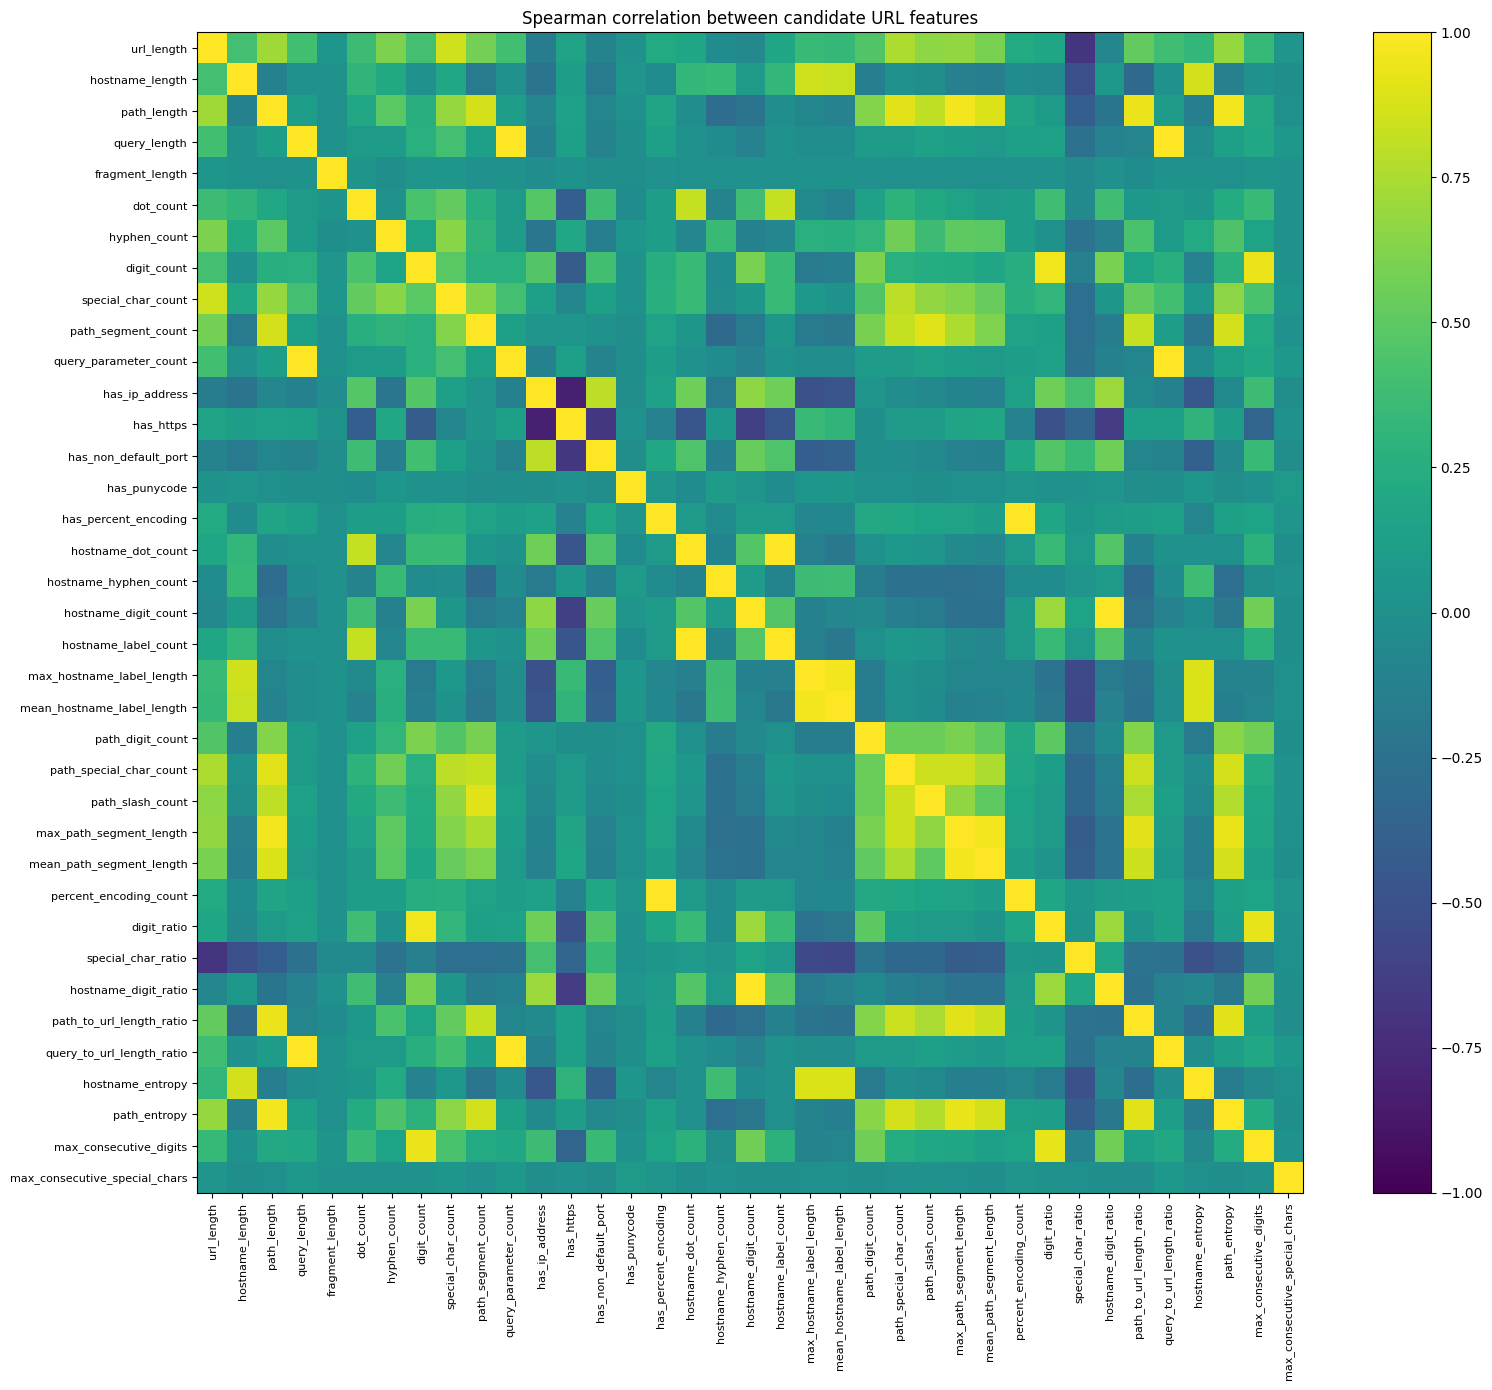

In [66]:
fig, ax = plt.subplots(
    figsize=(
        16,
        14,
    )
)

image = ax.imshow(
    spearman_correlation,
    aspect="auto",
    vmin=-1,
    vmax=1,
)

ax.set_xticks(
    range(
        len(
            ALL_FEATURES
        )
    )
)

ax.set_yticks(
    range(
        len(
            ALL_FEATURES
        )
    )
)

ax.set_xticklabels(
    ALL_FEATURES,
    rotation=90,
    fontsize=8,
)

ax.set_yticklabels(
    ALL_FEATURES,
    fontsize=8,
)

ax.set_title(
    "Spearman correlation between candidate URL features"
)

fig.colorbar(
    image,
    ax=ax,
)

plt.tight_layout()
plt.show()

### Interprétation des corrélations entre features

L'analyse de Spearman révèle plusieurs groupes de features fortement redondantes.

Certaines relations sont presque déterministes, notamment `hostname_dot_count` avec `hostname_label_count`, ainsi que `has_percent_encoding` avec `percent_encoding_count`. Les features liées à la query, aux chiffres et à la structure du path présentent également de fortes corrélations internes.

Ces résultats indiquent qu'un grand nombre de features candidates ne correspondent pas à des signaux indépendants, mais à différentes représentations d'une même propriété lexicale.

La sélection finale devra donc éviter de conserver plusieurs variables fortement corrélées, afin de limiter la redondance, simplifier le modèle et réduire le risque de surpondérer certaines caractéristiques propres aux sources de collecte.

La corrélation seule ne permet toutefois pas de choisir quelle feature conserver dans chaque groupe. La prochaine analyse de Mutual Information permettra de comparer leur pouvoir discriminant avant de décider.


### 12.9 Dataset équilibré pour la Mutual Information


La Mutual Information ne doit pas être calculée naïvement sur les populations déséquilibrées.

On construit donc une vue équilibrée uniquement en mémoire.

In [67]:
class_sizes = (
    features_df[
        "label"
    ]
    .value_counts()
)

balanced_sample_size = int(
    class_sizes.min()
)

print(
    "Balanced rows per class:",
    balanced_sample_size,
)

Balanced rows per class: 29925


In [68]:
balanced_feature_frames = []

for label in LABELS:
    label_frame = (
        features_df.loc[
            features_df["label"]
            == label
        ]
        .sample(
            n=balanced_sample_size,
            random_state=42,
            replace=False,
        )
    )

    balanced_feature_frames.append(
        label_frame
    )


balanced_features_df = (
    pd.concat(
        balanced_feature_frames,
        ignore_index=True,
    )
)

balanced_features_df[
    "label"
].value_counts()

label
benign      29925
phishing    29925
malware     29925
Name: count, dtype: int64

### 12.10 Mutual Information


In [69]:

X_mi = (
    balanced_features_df[
        ALL_FEATURES
    ]
    .astype(float)
)

label_encoder = (
    LabelEncoder()
)

y_mi = (
    label_encoder
    .fit_transform(
        balanced_features_df[
            "label"
        ]
    )
)


discrete_mask = np.array(
    [
        feature
        in BINARY_FEATURES
        for feature
        in ALL_FEATURES
    ],
    dtype=bool,
)

In [70]:
mi_scores = (
    mutual_info_classif(
        X_mi,
        y_mi,
        discrete_features=(
            discrete_mask
        ),
        random_state=42,
    )
)


label_entropy = np.log(
    len(
        LABELS
    )
)


mutual_information = (
    pd.DataFrame(
        {
            "feature": (
                ALL_FEATURES
            ),
            "mutual_information": (
                mi_scores
            ),
            "normalized_mi": (
                mi_scores
                / label_entropy
            ),
            "feature_family": [
                (
                    "base"
                    if feature
                    in FEATURE_COLUMNS
                    else "experimental"
                )
                for feature
                in ALL_FEATURES
            ],
        }
    )
    .sort_values(
        "mutual_information",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

mutual_information

,feature,mutual_information,normalized_mi,feature_family
0,hostname_entropy,0.605294,0.550962,experimental
1,path_to_url_length_ratio,0.568580,0.517544,experimental
2,path_entropy,0.441475,0.401848,experimental
3,mean_hostname_label_length,0.408535,0.371864,experimental
4,digit_ratio,0.391748,0.356584,experimental
5,mean_path_segment_length,0.388167,0.353325,experimental
6,path_length,0.340896,0.310297,base
7,special_char_ratio,0.339298,0.308842,experimental
8,hostname_length,0.338469,0.308088,base
9,hostname_digit_ratio,0.333808,0.303845,experimental


#### Visualisation recommandée — top Mutual Information

Le tableau complet reste la source de vérité. Le graphique suivant facilite uniquement la lecture des principales features informatives et ne constitue pas un critère de sélection à lui seul.

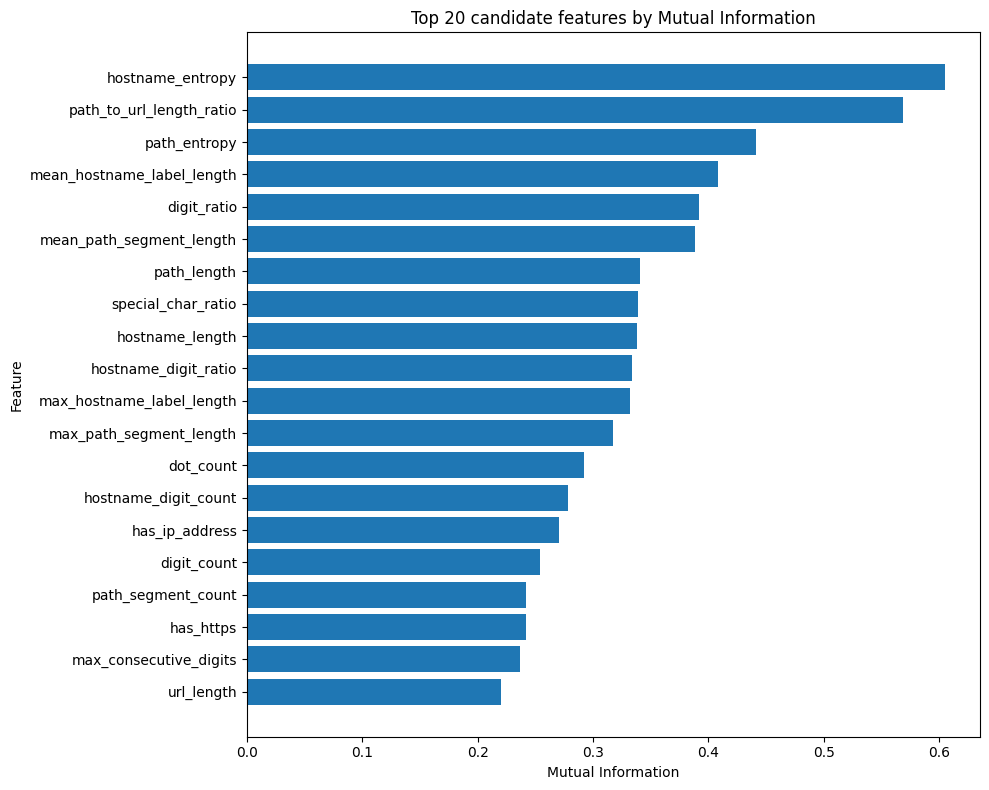

In [71]:
top_mi_plot = (
    mutual_information
    .head(20)
    .sort_values("mutual_information", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    top_mi_plot["feature"],
    top_mi_plot["mutual_information"],
)
ax.set_title("Top 20 candidate features by Mutual Information")
ax.set_xlabel("Mutual Information")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

#### Check méthodologique avant persistance — sensibilité du masque discret de Mutual Information

Dans l'expérience principale, seules les features binaires sont déclarées comme discrètes dans `mutual_info_classif`. Plusieurs compteurs entiers peuvent également être considérés comme discrets. La cellule suivante fournit donc un **sanity check** à exécuter avant persistance définitive : elle recalcule la MI avec un masque discret élargi et compare le classement sans remplacer les résultats historiques déjà documentés.

In [72]:
COUNT_LIKE_FEATURES = {
    "url_length",
    "hostname_length",
    "path_length",
    "query_length",
    "fragment_length",
    "dot_count",
    "hyphen_count",
    "digit_count",
    "special_char_count",
    "path_segment_count",
    "query_parameter_count",
    "hostname_dot_count",
    "hostname_hyphen_count",
    "hostname_digit_count",
    "hostname_label_count",
    "max_hostname_label_length",
    "path_digit_count",
    "path_special_char_count",
    "path_slash_count",
    "max_path_segment_length",
    "percent_encoding_count",
    "max_consecutive_digits",
    "max_consecutive_special_chars",
}

mi_sensitivity_mask = np.array(
    [
        feature in BINARY_FEATURES
        or feature in COUNT_LIKE_FEATURES
        for feature in ALL_FEATURES
    ],
    dtype=bool,
)

mi_sensitivity_scores = mutual_info_classif(
    X_mi,
    y_mi,
    discrete_features=mi_sensitivity_mask,
    random_state=RANDOM_SEED,
)

mi_sensitivity = (
    pd.DataFrame(
        {
            "feature": ALL_FEATURES,
            "mi_original": mi_scores,
            "mi_discrete_sensitivity": mi_sensitivity_scores,
        }
    )
    .assign(
        absolute_delta=lambda frame: (
            frame["mi_discrete_sensitivity"] - frame["mi_original"]
        ).abs()
    )
    .sort_values("absolute_delta", ascending=False)
)

mi_sensitivity.head(20)

,feature,mi_original,mi_discrete_sensitivity,absolute_delta
36,max_consecutive_special_chars,0.007201,0.000371,0.006830
28,digit_ratio,0.391748,0.396036,0.004288
2,path_length,0.340896,0.344795,0.003899
16,hostname_dot_count,0.165948,0.162164,0.003784
9,path_segment_count,0.242121,0.238945,0.003176
19,hostname_label_count,0.165283,0.162164,0.003119
25,max_path_segment_length,0.317387,0.320487,0.003101
0,url_length,0.220631,0.223702,0.003071
4,fragment_length,0.005573,0.002551,0.003022
29,special_char_ratio,0.339298,0.336560,0.002738


### Interprétation de la Mutual Information

La Mutual Information confirme l'intérêt de plusieurs features expérimentales. `hostname_entropy`, `path_to_url_length_ratio`, `path_entropy` et `mean_hostname_label_length` figurent notamment parmi les variables les plus informatives du dataset équilibré.

Les ratios tels que `digit_ratio` et `special_char_ratio` semblent également apporter davantage d'information que certains comptes absolus correspondants.

À l'inverse, `fragment_length`, `has_punycode`, `has_percent_encoding` et `max_consecutive_special_chars` présentent très peu d'information discriminante et deviennent des candidates à la suppression.

Ces résultats ne suffisent toutefois pas encore à figer le Feature Set V1. Une Mutual Information élevée peut également provenir d'une différence entre les sources de collecte. Les features fortement discriminantes devront donc être confrontées à l'audit de source leakage et aux redondances identifiées précédemment.


### 12.11 Détection de signatures de source potentielles


In [73]:
zero_rate_rows = []

for feature in ALL_FEATURES:
    class_zero_rates = {}

    for label in LABELS:
        series = features_df.loc[
            features_df["label"]
            == label,
            feature,
        ]

        zero_rate = float(
            (
                series.astype(float)
                == 0
            )
            .mean()
        )

        class_zero_rates[
            label
        ] = zero_rate

    rates = list(
        class_zero_rates.values()
    )

    zero_rate_rows.append(
        {
            "feature": feature,
            "benign_zero_pct": (
                class_zero_rates[
                    "benign"
                ]
                * 100
            ),
            "phishing_zero_pct": (
                class_zero_rates[
                    "phishing"
                ]
                * 100
            ),
            "malware_zero_pct": (
                class_zero_rates[
                    "malware"
                ]
                * 100
            ),
            "zero_rate_range_pct": (
                (
                    max(rates)
                    - min(rates)
                )
                * 100
            ),
        }
    )


zero_rate_analysis = (
    pd.DataFrame(
        zero_rate_rows
    )
    .sort_values(
        "zero_rate_range_pct",
        ascending=False,
    )
)

zero_rate_analysis.head(
    25
)

,feature,benign_zero_pct,phishing_zero_pct,malware_zero_pct,zero_rate_range_pct
12,has_https,0.347719,7.202678,64.574770,64.227051
11,has_ip_address,100.000000,99.851246,40.290727,59.709273
18,hostname_digit_count,89.827504,73.245073,32.691729,57.135775
30,hostname_digit_ratio,89.827504,73.245073,32.691729,57.135775
28,digit_ratio,58.222540,40.937151,3.903091,54.319449
7,digit_count,58.222540,40.937151,3.903091,54.319449
35,max_consecutive_digits,58.222540,40.937151,3.903091,54.319449
13,has_non_default_port,99.965910,99.979174,59.428571,40.550603
25,max_path_segment_length,0.995432,36.130904,1.563910,35.135472
34,path_entropy,0.995432,36.130904,1.563910,35.135472


### Interprétation des taux de valeurs nulles

L'analyse des zero-rates met en évidence de fortes différences de présence de certains motifs entre les classes.

`has_https`, `has_ip_address`, `has_non_default_port` ainsi que plusieurs features liées aux chiffres présentent les écarts les plus importants. Ces caractéristiques peuvent être fortement discriminantes, mais elles constituent également des candidates importantes pour l'audit de source leakage.

Plusieurs groupes de features possèdent exactement les mêmes taux de zéro, notamment les variables liées aux chiffres, à la query et à la structure du path. Cela confirme qu'elles partagent une partie importante de la même information et renforce la nécessité de réduire leur redondance.

Enfin, `fragment_length`, `has_punycode` et les features liées au percent-encoding sont presque toujours nulles. Combinée à leur faible Mutual Information, cette forte sparsité renforce leur statut de candidates à la suppression.

Le zero-rate reste toutefois un indicateur de présence ou de sparsité : une feature qui ne vaut jamais zéro, telle que `url_length`, peut rester fortement informative.


### 12.12 Cas particulier des features binaires


Pour les booléens, calculons directement l'écart maximal de prévalence.

In [74]:
binary_leakage_rows = []

for feature in BINARY_FEATURES:
    prevalence_by_class = {}

    for label in LABELS:
        prevalence = (
            features_df.loc[
                features_df["label"]
                == label,
                feature,
            ]
            .astype(bool)
            .mean()
        )

        prevalence_by_class[
            label
        ] = float(
            prevalence
        )

    values = list(
        prevalence_by_class.values()
    )

    binary_leakage_rows.append(
        {
            "feature": feature,
            "benign_true_pct": (
                prevalence_by_class[
                    "benign"
                ]
                * 100
            ),
            "phishing_true_pct": (
                prevalence_by_class[
                    "phishing"
                ]
                * 100
            ),
            "malware_true_pct": (
                prevalence_by_class[
                    "malware"
                ]
                * 100
            ),
            "prevalence_range_pct": (
                (
                    max(values)
                    - min(values)
                )
                * 100
            ),
        }
    )


binary_leakage_review = (
    pd.DataFrame(
        binary_leakage_rows
    )
    .sort_values(
        "prevalence_range_pct",
        ascending=False,
    )
)

binary_leakage_review

,feature,benign_true_pct,phishing_true_pct,malware_true_pct,prevalence_range_pct
1,has_https,99.652281,92.797322,35.425230,64.227051
0,has_ip_address,0.000000,0.148754,59.709273,59.709273
2,has_non_default_port,0.034090,0.020826,40.571429,40.550603
4,has_percent_encoding,2.970955,1.530681,6.051796,4.521116
3,has_punycode,0.252267,0.121978,0.013367,0.238900


### 12.13 Audit des features binaires et risque de source leakage

Les features `has_https`, `has_ip_address` et `has_non_default_port` présentent des écarts de prévalence très importants entre les classes, principalement entre `malware` et les deux autres catégories.

Ces variables sont donc fortement discriminantes, mais elles représentent également un risque élevé de **source proxy** : la classe malware provenant actuellement de URLhaus, le modèle pourrait apprendre certaines caractéristiques propres à cette source plutôt que des propriétés générales des URLs malveillantes.

À l'inverse, `has_percent_encoding` présente des écarts beaucoup plus modérés, tandis que `has_punycode` est extrêmement rare dans toutes les classes et apporte très peu d'information.

Ces résultats ne constituent pas encore une preuve de leakage, mais ils justifient de maintenir les trois premières features en `REVIEW` jusqu'à la sélection finale du Feature Set V1.


### 12.14 Première sélection des features expérimentales

Après analyse de la variance, des distributions par classe, des corrélations, du SMD, de la Mutual Information et des risques de source proxy, quatre features expérimentales sont retenues comme candidates principales pour le Feature Set V1 :

* `hostname_entropy`
* `mean_hostname_label_length`
* `path_to_url_length_ratio`
* `special_char_ratio`

Elles apportent des informations complémentaires sur la complexité et la structure des URLs tout en restant déterministes, explicables et peu coûteuses à calculer.

`digit_ratio`, `hostname_digit_ratio` et `path_entropy` restent en observation. Leur pouvoir discriminant est important, mais leur redondance ou leur possible dépendance aux caractéristiques des sources nécessite une validation supplémentaire par ablation.

Les autres features expérimentales ne sont pas retenues pour la V1 en raison d'une information trop faible, d'une forte sparsité ou d'une redondance importante avec des variables plus simples.


## 13. Expérience de feature composite par PCA

Les features `digit_ratio`, `hostname_digit_ratio` et `path_entropy` présentent un pouvoir discriminant intéressant, mais certaines peuvent également refléter des caractéristiques propres aux sources de collecte.

Une combinaison supervisée directement optimisée sur le label risquerait d'amplifier ce biais. Nous étudions donc une représentation composite non supervisée, obtenue à partir des trois variables standardisées.

Cette feature composite vise principalement à réduire la redondance et la dimension du Feature Set. Elle ne sera conservée que si les analyses d'ablation montrent qu'elle maintient une information utile tout en offrant un comportement plus stable que les trois variables prises séparément.

Cette approche ne constitue toutefois pas une preuve de suppression du source leakage, puisque les sources et les classes restent fortement couplées dans le dataset actuel.


In [75]:
COMPOSITE_CANDIDATES = [
    "digit_ratio",
    "hostname_digit_ratio",
    "path_entropy",
]


composite_scaler = StandardScaler()

X_composite_scaled = (
    composite_scaler.fit_transform(
        balanced_features_df[
            COMPOSITE_CANDIDATES
        ]
    )
)


composite_pca = PCA(
    n_components=1,
    random_state=42,
)

composite_score = (
    composite_pca.fit_transform(
        X_composite_scaled
    )
    .ravel()
)


balanced_features_df = (
    balanced_features_df.copy()
)

balanced_features_df[
    "lexical_complexity_score"
] = composite_score

In [76]:
composite_weights = pd.DataFrame(
    {
        "feature": COMPOSITE_CANDIDATES,
        "weight": (
            composite_pca.components_[0]
        ),
    }
)

composite_weights

,feature,weight
0,digit_ratio,0.696211
1,hostname_digit_ratio,0.697009
2,path_entropy,-0.171664


In [77]:
print(
    "Explained variance ratio:",
    float(
        composite_pca
        .explained_variance_ratio_[0]
    ),
)

Explained variance ratio: 0.6383393363386665


In [78]:
# ensuite, on mesure sa MI
composite_mi = mutual_info_classif(
    balanced_features_df[
        [
            "lexical_complexity_score",
        ]
    ],
    y_mi,
    discrete_features=False,
    random_state=42,
)

print(
    "Composite MI:",
    float(
        composite_mi[0]
    ),
)

Composite MI: 0.5489987495740187


In [79]:
#test composite 2
composite_distribution = (
    balanced_features_df
    .groupby(
        "label"
    )[
        "lexical_complexity_score"
    ]
    .agg(
        [
            "count",
            "mean",
            "std",
            "median",
            "min",
            "max",
        ]
    )
)

composite_distribution

,count,mean,std,median,min,max
label,,,,,,
benign,29925,-0.822599,0.333319,-0.950638,-1.163375,2.153165
malware,29925,1.268882,1.651260,2.099379,-1.166935,3.540966
phishing,29925,-0.446283,0.649233,-0.618882,-1.163257,3.295242


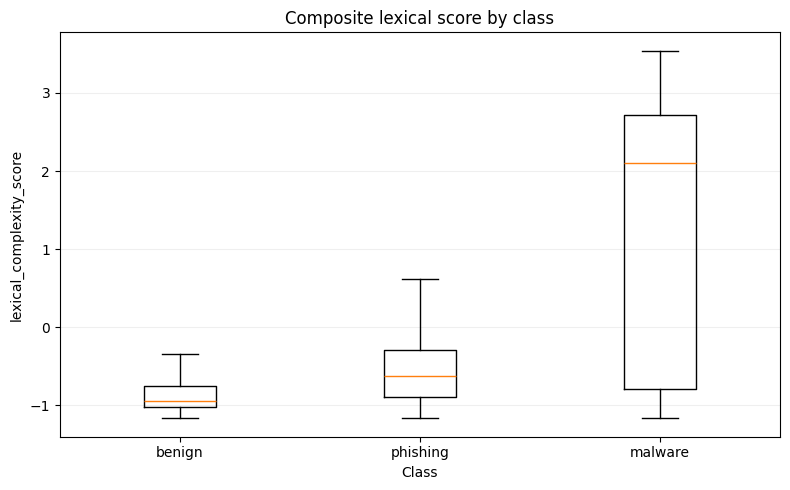

In [80]:
plot_data = [
    balanced_features_df.loc[
        balanced_features_df["label"]
        == label,
        "lexical_complexity_score",
    ]
    .to_numpy()
    for label in LABELS
]

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.boxplot(
    plot_data,
    tick_labels=LABELS,
    showfliers=False,
)

ax.set_title(
    "Composite lexical score by class"
)

ax.set_xlabel(
    "Class"
)

ax.set_ylabel(
    "lexical_complexity_score"
)

ax.grid(
    axis="y",
    alpha=0.2,
)

plt.tight_layout()
plt.show()

### 13.1 Conclusion sur la feature composite

La feature composite obtenue par PCA présente une Mutual Information élevée (`0.549`) et conserve environ `63.8 %` de la variance des trois variables initiales.

Cependant, sa distribution montre une forte séparation de la classe `malware`, tandis que `benign` et `phishing` restent beaucoup plus proches. Ce comportement est cohérent avec les poids élevés attribués à `digit_ratio` et `hostname_digit_ratio`, deux features déjà identifiées comme potentiellement liées aux caractéristiques de la source URLhaus.

La combinaison PCA réduit donc la dimension, mais **ne réduit pas le risque de source proxy** ; elle semble au contraire concentrer ce signal dans une seule variable.

`lexical_complexity_score` n'est donc pas retenue pour le Feature Set V1. L'expérience reste utile pour montrer qu'une combinaison de features biaisées ne constitue pas, à elle seule, une stratégie de mitigation du source leakage.


## 14. Proxy-Controlled Stress Test


In [81]:
proxy_controlled_df = (
    balanced_features_df.loc[
        (~balanced_features_df["has_ip_address"].astype(bool))
        & (balanced_features_df["has_https"].astype(bool))
        & (~balanced_features_df["has_non_default_port"].astype(bool))
    ]
    .copy()
)

proxy_controlled_df[
    "label"
].value_counts()

label
benign      29830
phishing    27773
malware     10357
Name: count, dtype: int64

In [82]:
controlled_class_sizes = (
    proxy_controlled_df[
        "label"
    ]
    .value_counts()
)

controlled_n = int(
    controlled_class_sizes.min()
)

print(
    "Controlled samples per class:",
    controlled_n,
)

Controlled samples per class: 10357


In [83]:
controlled_frames = []

for label in LABELS:
    controlled_frames.append(
        proxy_controlled_df.loc[
            proxy_controlled_df["label"]
            == label
        ]
        .sample(
            n=controlled_n,
            random_state=42,
            replace=False,
        )
    )

controlled_balanced_df = (
    pd.concat(
        controlled_frames,
        ignore_index=True,
    )
)

controlled_balanced_df[
    "label"
].value_counts()

label
benign      10357
phishing    10357
malware     10357
Name: count, dtype: int64

In [84]:
PROXY_STRESS_FEATURES = [
    "hostname_entropy",
    "mean_hostname_label_length",
    "path_to_url_length_ratio",
    "special_char_ratio",

    "digit_ratio",
    "hostname_digit_ratio",
    "path_entropy",

    "hostname_length",
    "path_length",
    "digit_count",
]

In [85]:
X_controlled = (
    controlled_balanced_df[
        PROXY_STRESS_FEATURES
    ]
    .astype(float)
)

y_controlled = (
    label_encoder.transform(
        controlled_balanced_df[
            "label"
        ]
    )
)

controlled_mi_scores = (
    mutual_info_classif(
        X_controlled,
        y_controlled,
        discrete_features=False,
        random_state=42,
    )
)

controlled_mi = (
    pd.DataFrame(
        {
            "feature": (
                PROXY_STRESS_FEATURES
            ),
            "controlled_mi": (
                controlled_mi_scores
            ),
        }
    )
)

In [86]:
proxy_stress_comparison = (
    mutual_information[
        [
            "feature",
            "mutual_information",
        ]
    ]
    .rename(
        columns={
            "mutual_information": (
                "original_mi"
            ),
        }
    )
    .merge(
        controlled_mi,
        on="feature",
        how="inner",
    )
)

proxy_stress_comparison[
    "mi_retention_ratio"
] = (
    proxy_stress_comparison[
        "controlled_mi"
    ]
    / proxy_stress_comparison[
        "original_mi"
    ].replace(
        0,
        np.nan,
    )
)

proxy_stress_comparison = (
    proxy_stress_comparison
    .sort_values(
        "mi_retention_ratio",
        ascending=False,
    )
)

proxy_stress_comparison

,feature,original_mi,controlled_mi,mi_retention_ratio
5,path_length,0.340896,0.445599,1.307142
7,hostname_length,0.338469,0.405671,1.198547
2,path_entropy,0.441475,0.514453,1.165305
1,path_to_url_length_ratio,0.568580,0.643900,1.132471
3,mean_hostname_label_length,0.408535,0.410876,1.005731
0,hostname_entropy,0.605294,0.594329,0.981885
6,special_char_ratio,0.339298,0.326598,0.962570
9,digit_count,0.254138,0.191013,0.751608
4,digit_ratio,0.391748,0.291336,0.743683
8,hostname_digit_ratio,0.333808,0.080289,0.240526


### 14.1 Résultat du premier proxy-controlled stress test

Le stress test neutralise les principaux marqueurs susceptibles de distinguer artificiellement les sources : utilisation d'une adresse IP, absence de HTTPS et utilisation d'un port non standard.

Les features `hostname_entropy`, `mean_hostname_label_length`, `special_char_ratio` et plusieurs caractéristiques liées au path conservent leur pouvoir discriminant après ce contrôle. Elles apparaissent donc plus robustes aux différences évidentes entre les sources.

À l'inverse, `hostname_digit_ratio` perd environ trois quarts de sa Mutual Information, ce qui indique une forte dépendance aux caractéristiques précédemment associées à la population URLhaus. `digit_ratio` reste informative mais montre également une sensibilité notable au contrôle.

Ces résultats renforcent la sélection de `hostname_entropy`, `mean_hostname_label_length`, `path_to_url_length_ratio` et `special_char_ratio` pour le Feature Set V1. Les features plus sensibles au proxy restent exclues ou réservées à de futures analyses d'ablation.


### 14.2 Répétition du stress test sur plusieurs sous-échantillons

Le premier résultat doit être reproductible. Nous répétons donc exactement le même protocole avec deux seeds supplémentaires (`7` et `2026`) afin de vérifier que les conclusions ne dépendent pas du tirage aléatoire `42`.


In [87]:
def compute_proxy_controlled_mi(
    *,
    seed: int,
) -> pd.DataFrame:
    controlled_frames = []

    for label in LABELS:
        label_frame = (
            proxy_controlled_df.loc[
                proxy_controlled_df["label"]
                == label
            ]
            .sample(
                n=controlled_n,
                random_state=seed,
                replace=False,
            )
        )

        controlled_frames.append(
            label_frame
        )

    controlled_balanced = (
        pd.concat(
            controlled_frames,
            ignore_index=True,
        )
    )

    X = (
        controlled_balanced[
            PROXY_STRESS_FEATURES
        ]
        .astype(float)
    )

    y = (
        label_encoder.transform(
            controlled_balanced[
                "label"
            ]
        )
    )

    scores = mutual_info_classif(
        X,
        y,
        discrete_features=False,
        random_state=seed,
    )

    return pd.DataFrame(
        {
            "feature": (
                PROXY_STRESS_FEATURES
            ),
            f"controlled_mi_seed_{seed}": (
                scores
            ),
        }
    )

In [88]:
controlled_mi_seed_7 = (
    compute_proxy_controlled_mi(
        seed=7
    )
)

controlled_mi_seed_2026 = (
    compute_proxy_controlled_mi(
        seed=2026
    )
)

In [89]:
# comparaison avec le premier seed 42
controlled_mi_seed_42 = (
    proxy_stress_comparison[
        [
            "feature",
            "controlled_mi",
        ]
    ]
    .rename(
        columns={
            "controlled_mi": (
                "controlled_mi_seed_42"
            ),
        }
    )
)

In [90]:
proxy_stress_repeated = (
    controlled_mi_seed_42
    .merge(
        controlled_mi_seed_7,
        on="feature",
        how="inner",
    )
    .merge(
        controlled_mi_seed_2026,
        on="feature",
        how="inner",
    )
)

proxy_stress_repeated

,feature,controlled_mi_seed_42,controlled_mi_seed_7,controlled_mi_seed_2026
0,path_length,0.445599,0.439350,0.441753
1,hostname_length,0.405671,0.403456,0.395236
2,path_entropy,0.514453,0.520451,0.510483
3,path_to_url_length_ratio,0.643900,0.647761,0.642164
4,mean_hostname_label_length,0.410876,0.408728,0.403866
5,hostname_entropy,0.594329,0.594630,0.588061
6,special_char_ratio,0.326598,0.327036,0.324797
7,digit_count,0.191013,0.191369,0.186341
8,digit_ratio,0.291336,0.294742,0.289270
9,hostname_digit_ratio,0.080289,0.078583,0.079580


In [91]:
# stabilité des résultats
MI_RUN_COLUMNS = [
    "controlled_mi_seed_42",
    "controlled_mi_seed_7",
    "controlled_mi_seed_2026",
]


proxy_stress_stability = (
    proxy_stress_repeated.copy()
)

proxy_stress_stability[
    "controlled_mi_mean"
] = (
    proxy_stress_stability[
        MI_RUN_COLUMNS
    ]
    .mean(
        axis=1
    )
)

proxy_stress_stability[
    "controlled_mi_std"
] = (
    proxy_stress_stability[
        MI_RUN_COLUMNS
    ]
    .std(
        axis=1
    )
)

proxy_stress_stability[
    "controlled_mi_min"
] = (
    proxy_stress_stability[
        MI_RUN_COLUMNS
    ]
    .min(
        axis=1
    )
)

proxy_stress_stability[
    "controlled_mi_max"
] = (
    proxy_stress_stability[
        MI_RUN_COLUMNS
    ]
    .max(
        axis=1
    )
)

proxy_stress_stability = (
    proxy_stress_stability
    .sort_values(
        "controlled_mi_mean",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

proxy_stress_stability

,feature,controlled_mi_seed_42,controlled_mi_seed_7,controlled_mi_seed_2026,controlled_mi_mean,controlled_mi_std,controlled_mi_min,controlled_mi_max
0,path_to_url_length_ratio,0.643900,0.647761,0.642164,0.644608,0.002865,0.642164,0.647761
1,hostname_entropy,0.594329,0.594630,0.588061,0.592340,0.003709,0.588061,0.594630
2,path_entropy,0.514453,0.520451,0.510483,0.515129,0.005018,0.510483,0.520451
3,path_length,0.445599,0.439350,0.441753,0.442234,0.003152,0.439350,0.445599
4,mean_hostname_label_length,0.410876,0.408728,0.403866,0.407823,0.003591,0.403866,0.410876
5,hostname_length,0.405671,0.403456,0.395236,0.401455,0.005498,0.395236,0.405671
6,special_char_ratio,0.326598,0.327036,0.324797,0.326144,0.001187,0.324797,0.327036
7,digit_ratio,0.291336,0.294742,0.289270,0.291783,0.002763,0.289270,0.294742
8,digit_count,0.191013,0.191369,0.186341,0.189574,0.002805,0.186341,0.191369
9,hostname_digit_ratio,0.080289,0.078583,0.079580,0.079484,0.000857,0.078583,0.080289


In [92]:
# comparaison avec la MI originale :
proxy_stress_stability = (
    proxy_stress_stability
    .merge(
        mutual_information[
            [
                "feature",
                "mutual_information",
            ]
        ],
        on="feature",
        how="left",
    )
    .rename(
        columns={
            "mutual_information": (
                "original_mi"
            ),
        }
    )
)

proxy_stress_stability[
    "mean_retention_ratio"
] = (
    proxy_stress_stability[
        "controlled_mi_mean"
    ]
    / proxy_stress_stability[
        "original_mi"
    ].replace(
        0,
        np.nan,
    )
)

proxy_stress_stability[
    [
        "feature",
        "original_mi",
        "controlled_mi_seed_42",
        "controlled_mi_seed_7",
        "controlled_mi_seed_2026",
        "controlled_mi_mean",
        "controlled_mi_std",
        "mean_retention_ratio",
    ]
]

,feature,original_mi,controlled_mi_seed_42,controlled_mi_seed_7,controlled_mi_seed_2026,controlled_mi_mean,controlled_mi_std,mean_retention_ratio
0,path_to_url_length_ratio,0.568580,0.643900,0.647761,0.642164,0.644608,0.002865,1.133716
1,hostname_entropy,0.605294,0.594329,0.594630,0.588061,0.592340,0.003709,0.978599
2,path_entropy,0.441475,0.514453,0.520451,0.510483,0.515129,0.005018,1.166837
3,path_length,0.340896,0.445599,0.439350,0.441753,0.442234,0.003152,1.297271
4,mean_hostname_label_length,0.408535,0.410876,0.408728,0.403866,0.407823,0.003591,0.998259
5,hostname_length,0.338469,0.405671,0.403456,0.395236,0.401455,0.005498,1.186089
6,special_char_ratio,0.339298,0.326598,0.327036,0.324797,0.326144,0.001187,0.961231
7,digit_ratio,0.391748,0.291336,0.294742,0.289270,0.291783,0.002763,0.744823
8,digit_count,0.254138,0.191013,0.191369,0.186341,0.189574,0.002805,0.745949
9,hostname_digit_ratio,0.333808,0.080289,0.078583,0.079580,0.079484,0.000857,0.238113


#### Visualisation recommandée — stabilité du proxy-controlled stress test

Le graphique suivant juxtapose la MI originale et la MI contrôlée moyenne. Il aide à distinguer les signaux stables des features dont le pouvoir discriminant dépend fortement des marqueurs neutralisés.

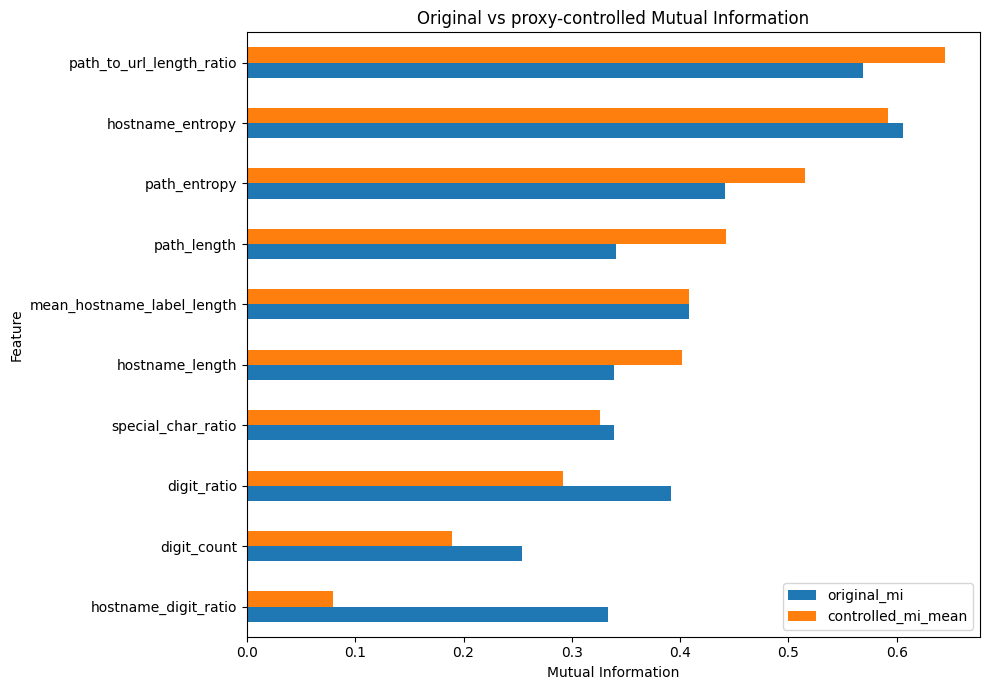

In [93]:
proxy_plot = (
    proxy_stress_stability[
        ["feature", "original_mi", "controlled_mi_mean"]
    ]
    .set_index("feature")
    .sort_values("controlled_mi_mean", ascending=True)
)

ax = proxy_plot.plot.barh(figsize=(10, 7))
ax.set_title("Original vs proxy-controlled Mutual Information")
ax.set_xlabel("Mutual Information")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

### 14.3 Stabilité du proxy-controlled stress test

Le stress test a été répété avec trois échantillonnages indépendants (`42`, `7` et `2026`). Les Mutual Information obtenues présentent de très faibles écarts-types, ce qui montre que les résultats sont stables et ne dépendent pas d'un tirage aléatoire particulier.

`hostname_entropy`, `mean_hostname_label_length`, `path_to_url_length_ratio` et `special_char_ratio` conservent presque entièrement leur pouvoir discriminant après neutralisation des principaux proxies. Ces résultats renforcent leur sélection pour le Feature Set V1.

`path_entropy` reste également très informative, mais demeure en observation en raison de sa forte redondance avec d'autres caractéristiques du path.

À l'inverse, `hostname_digit_ratio` perd plus de 75 % de son information de manière reproductible, ce qui confirme sa forte dépendance au contexte associé à la population URLhaus. `digit_ratio` présente une baisse plus modérée mais systématique et reste réservée à de futures analyses d'ablation.

Ces répétitions renforcent donc la sélection d'un Feature Set V1 compact privilégiant les signaux les plus stables face aux principaux risques de source proxy.


## 15. Exploration contrôlée des interactions entre features

Après sélection des features robustes, nous testons si certaines relations simples entre deux variables contiennent une information complémentaire. L'exploration reste volontairement limitée afin d'éviter le feature mining.

Transformations étudiées :

- Produit : $x 	\times y$
- Ratio : $\frac{x}{y + \varepsilon}$
- Ratio borné : $\frac{x}{|x| + |y| + \varepsilon}$
- Produit normalisé : $\frac{x}{1 + |x|} \times \frac{y}{1 + |y|}$

Les ratios bruts sont conservés uniquement à titre exploratoire ; les produits normalisés sont préférés lorsqu'ils apportent un signal comparable, car ils sont bornés et numériquement plus stables.


In [94]:
EPSILON = 1e-9


def normalized_product(
    left: pd.Series,
    right: pd.Series,
) -> pd.Series:
    return (
        left
        / (1.0 + left.abs())
    ) * (
        right
        / (1.0 + right.abs())
    )


def bounded_ratio(
    left: pd.Series,
    right: pd.Series,
) -> pd.Series:
    return (
        left
        / (
            left.abs()
            + right.abs()
            + EPSILON
        )
    )

In [95]:

INTERACTION_SOURCE_FEATURES = [
    "url_length",
    "hostname_length",
    "path_length",

    "hostname_entropy",
    "mean_hostname_label_length",
    "path_to_url_length_ratio",
    "special_char_ratio",

    # Feature encore en review,
    # mais robuste au proxy-controlled stress test.
    "path_entropy",
]


missing_interaction_features = [
    feature
    for feature in INTERACTION_SOURCE_FEATURES
    if feature not in features_df.columns
]

if missing_interaction_features:
    raise RuntimeError(
        "Missing interaction source features: "
        f"{missing_interaction_features}"
    )

print(
    "Interaction source features:",
    len(INTERACTION_SOURCE_FEATURES),
)

Interaction source features: 8


In [96]:
interaction_columns = {
    "label": features_df["label"],
    "record_id": features_df["record_id"],
}
interaction_metadata = []
candidate_index = 1

for left_feature, right_feature in combinations(
    INTERACTION_SOURCE_FEATURES,
    2,
):
    left = features_df[left_feature].astype(float)
    right = features_df[right_feature].astype(float)

    transformations = {
        "product": left * right,
        "ratio": left / (right.abs() + EPSILON),
        "bounded_ratio": bounded_ratio(left, right),
        "normalized_product": normalized_product(left, right),
    }

    for operation, values in transformations.items():
        candidate_name = f"interaction_{candidate_index:03d}"
        interaction_columns[candidate_name] = values
        interaction_metadata.append({
            "candidate": candidate_name,
            "left_feature": left_feature,
            "right_feature": right_feature,
            "operation": operation,
        })
        candidate_index += 1

interaction_df = pd.DataFrame(interaction_columns)
interaction_metadata_df = pd.DataFrame(interaction_metadata)

print(
    "Generated interaction candidates:",
    len(interaction_metadata_df),
)
interaction_df.shape


Generated interaction candidates: 112


(155818, 114)

In [97]:
INTERACTION_COLUMNS = (
    interaction_metadata_df[
        "candidate"
    ]
    .tolist()
)


interaction_quality_rows = []

for feature in INTERACTION_COLUMNS:
    series = (
        interaction_df[
            feature
        ]
        .replace(
            [
                np.inf,
                -np.inf,
            ],
            np.nan,
        )
    )

    interaction_quality_rows.append(
        {
            "candidate": feature,
            "missing": int(
                series.isna().sum()
            ),
            "unique_values": int(
                series.nunique(
                    dropna=True
                )
            ),
            "std": float(
                series.std()
            ),
            "p01": float(
                series.quantile(
                    0.01
                )
            ),
            "median": float(
                series.median()
            ),
            "p99": float(
                series.quantile(
                    0.99
                )
            ),
        }
    )


interaction_quality = (
    pd.DataFrame(
        interaction_quality_rows
    )
    .merge(
        interaction_metadata_df,
        on="candidate",
        how="left",
    )
)

interaction_quality

,candidate,missing,unique_values,std,p01,median,p99,left_feature,right_feature,operation
0,interaction_001,0,3362,1.316236e+03,126.000000,816.000000,6.142000e+03,url_length,hostname_length,product
1,interaction_002,0,6415,3.759684e+00,1.187787,2.809524,1.445455e+01,url_length,hostname_length,ratio
2,interaction_003,0,6415,1.040557e-01,0.542917,0.737500,9.352941e-01,url_length,hostname_length,bounded_ratio
3,interaction_004,0,6102,3.504668e-02,0.818182,0.922438,9.694892e-01,url_length,hostname_length,normalized_product
4,interaction_005,0,5665,1.887537e+04,24.000000,490.000000,2.120900e+04,url_length,path_length,product
...,...,...,...,...,...,...,...,...,...,...
107,interaction_108,0,52159,1.175481e-01,0.000000,0.184986,3.730849e-01,path_to_url_length_ratio,path_entropy,normalized_product
108,interaction_109,0,63777,2.754505e-01,0.000000,0.615431,1.017584e+00,special_char_ratio,path_entropy,product
109,interaction_110,0,64876,7.131376e+07,0.020150,0.061508,2.558140e+08,special_char_ratio,path_entropy,ratio
110,interaction_111,0,64594,3.479530e-01,0.019752,0.057944,1.000000e+00,special_char_ratio,path_entropy,bounded_ratio


In [98]:
# dataset équilibré pour analyser les interactions
balanced_interactions_df = (
    balanced_features_df[
        [
            "record_id",
            "label",
        ]
    ]
    .merge(
        interaction_df,
        on=[
            "record_id",
            "label",
        ],
        how="inner",
        validate="one_to_one",
    )
)

balanced_interactions_df.shape

(89775, 114)

In [99]:
# MI des interactions
X_interactions = (
    balanced_interactions_df[
        INTERACTION_COLUMNS
    ]
    .replace(
        [
            np.inf,
            -np.inf,
        ],
        np.nan,
    )
    .fillna(0.0)
)


y_interactions = (
    label_encoder.transform(
        balanced_interactions_df[
            "label"
        ]
    )
)


interaction_mi_scores = (
    mutual_info_classif(
        X_interactions,
        y_interactions,
        discrete_features=False,
        random_state=42,
    )
)


interaction_mi = (
    pd.DataFrame(
        {
            "candidate": (
                INTERACTION_COLUMNS
            ),
            "mutual_information": (
                interaction_mi_scores
            ),
        }
    )
    .merge(
        interaction_metadata_df,
        on="candidate",
        how="left",
    )
    .sort_values(
        "mutual_information",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

interaction_mi.head(
    30
)

,candidate,mutual_information,left_feature,right_feature,operation
0,interaction_044,0.749792,hostname_length,path_to_url_length_ratio,normalized_product
1,interaction_092,0.739075,mean_hostname_label_length,path_to_url_length_ratio,normalized_product
2,interaction_090,0.736398,mean_hostname_label_length,path_to_url_length_ratio,ratio
3,interaction_091,0.735057,mean_hostname_label_length,path_to_url_length_ratio,bounded_ratio
4,interaction_080,0.732873,hostname_entropy,path_to_url_length_ratio,normalized_product
5,interaction_042,0.730939,hostname_length,path_to_url_length_ratio,ratio
6,interaction_078,0.727935,hostname_entropy,path_to_url_length_ratio,ratio
7,interaction_079,0.727749,hostname_entropy,path_to_url_length_ratio,bounded_ratio
8,interaction_077,0.724294,hostname_entropy,path_to_url_length_ratio,product
9,interaction_055,0.719883,path_length,hostname_entropy,bounded_ratio


In [100]:
# comparer les interactions à ces deux parents
base_mi_lookup = (
    mutual_information
    .set_index(
        "feature"
    )[
        "mutual_information"
    ]
    .to_dict()
)


interaction_gain_rows = []

for row in interaction_mi.itertuples(
    index=False
):
    left_mi = float(
        base_mi_lookup[
            row.left_feature
        ]
    )

    right_mi = float(
        base_mi_lookup[
            row.right_feature
        ]
    )

    best_parent_mi = max(
        left_mi,
        right_mi,
    )

    interaction_gain_rows.append(
        {
            "candidate": (
                row.candidate
            ),
            "left_feature": (
                row.left_feature
            ),
            "right_feature": (
                row.right_feature
            ),
            "operation": (
                row.operation
            ),
            "interaction_mi": (
                row.mutual_information
            ),
            "best_parent_mi": (
                best_parent_mi
            ),
            "absolute_gain": (
                row.mutual_information
                - best_parent_mi
            ),
            "relative_gain_pct": (
                (
                    row.mutual_information
                    / best_parent_mi
                    - 1.0
                )
                * 100
                if best_parent_mi > 0
                else np.nan
            ),
        }
    )


interaction_gain = (
    pd.DataFrame(
        interaction_gain_rows
    )
    .sort_values(
        "absolute_gain",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

interaction_gain.head(
    30
)

,candidate,left_feature,right_feature,operation,interaction_mi,best_parent_mi,absolute_gain,relative_gain_pct
0,interaction_046,hostname_length,special_char_ratio,ratio,0.669823,0.339298,0.330525,97.414518
1,interaction_066,path_length,special_char_ratio,ratio,0.649857,0.340896,0.308961,90.632065
2,interaction_068,path_length,special_char_ratio,normalized_product,0.644298,0.340896,0.303402,89.001204
3,interaction_016,url_length,mean_hostname_label_length,normalized_product,0.708428,0.408535,0.299894,73.407157
4,interaction_067,path_length,special_char_ratio,bounded_ratio,0.633325,0.340896,0.292429,85.782605
5,interaction_008,url_length,path_length,normalized_product,0.630559,0.340896,0.289663,84.971179
6,interaction_004,url_length,hostname_length,normalized_product,0.622089,0.338469,0.283620,83.794961
7,interaction_065,path_length,special_char_ratio,product,0.616142,0.340896,0.275246,80.741976
8,interaction_048,hostname_length,special_char_ratio,normalized_product,0.608281,0.339298,0.268983,79.276443
9,interaction_094,mean_hostname_label_length,special_char_ratio,ratio,0.673947,0.408535,0.265412,64.966883


In [101]:
# filtre pour conserver les expériences prometteuses
PROMISING_MIN_ABSOLUTE_GAIN = 0.03
PROMISING_MIN_RELATIVE_GAIN = 0.05


promising_interactions = (
    interaction_gain.loc[
        (
            interaction_gain[
                "absolute_gain"
            ]
            >= PROMISING_MIN_ABSOLUTE_GAIN
        )
        & (
            interaction_gain[
                "relative_gain_pct"
            ]
            >= (
                PROMISING_MIN_RELATIVE_GAIN
                * 100
            )
        )
    ]
    .copy()
)

promising_interactions

,candidate,left_feature,right_feature,operation,interaction_mi,best_parent_mi,absolute_gain,relative_gain_pct
0,interaction_046,hostname_length,special_char_ratio,ratio,0.669823,0.339298,0.330525,97.414518
1,interaction_066,path_length,special_char_ratio,ratio,0.649857,0.340896,0.308961,90.632065
2,interaction_068,path_length,special_char_ratio,normalized_product,0.644298,0.340896,0.303402,89.001204
3,interaction_016,url_length,mean_hostname_label_length,normalized_product,0.708428,0.408535,0.299894,73.407157
4,interaction_067,path_length,special_char_ratio,bounded_ratio,0.633325,0.340896,0.292429,85.782605
5,interaction_008,url_length,path_length,normalized_product,0.630559,0.340896,0.289663,84.971179
6,interaction_004,url_length,hostname_length,normalized_product,0.622089,0.338469,0.283620,83.794961
7,interaction_065,path_length,special_char_ratio,product,0.616142,0.340896,0.275246,80.741976
8,interaction_048,hostname_length,special_char_ratio,normalized_product,0.608281,0.339298,0.268983,79.276443
9,interaction_094,mean_hostname_label_length,special_char_ratio,ratio,0.673947,0.408535,0.265412,64.966883


### 15.1 Interprétation des interactions générées

Plusieurs interactions apportent une Mutual Information nettement supérieure à celle de leurs features parentes, ce qui montre que certaines relations entre caractéristiques lexicales contiennent une information supplémentaire utile.

Les meilleurs résultats impliquent notamment la structure du hostname, la proportion du path dans l'URL et la complexité lexicale.

Pour la V1, les ratios bruts sont toutefois considérés avec prudence, car une division par une valeur faible peut générer des distributions instables et des valeurs extrêmes. Les **produits normalisés** sont privilégiés : ils offrent de fortes Mutual Information tout en restant bornés, déterministes et peu coûteux à calculer.

Une shortlist réduite d'interactions sera maintenant soumise au même proxy-controlled stress test que les features individuelles. L'objectif est de ne retenir au final qu'une ou deux interactions réellement robustes et complémentaires.


### 15.2 Stress test des cinq interactions les plus prometteuses


In [102]:
# on prépare les 5 candidats
INTERACTION_SHORTLIST = [
    "interaction_044",
    "interaction_092",
    "interaction_080",
    "interaction_016",
    "interaction_068",
]


shortlist_metadata = (
    interaction_metadata_df.loc[
        interaction_metadata_df["candidate"]
        .isin(INTERACTION_SHORTLIST)
    ]
    .copy()
)


if len(shortlist_metadata) != len(
    INTERACTION_SHORTLIST
):
    missing = sorted(
        set(INTERACTION_SHORTLIST)
        - set(
            shortlist_metadata[
                "candidate"
            ]
        )
    )

    raise RuntimeError(
        "Missing interaction candidates: "
        f"{missing}"
    )


shortlist_metadata[
    [
        "candidate",
        "left_feature",
        "right_feature",
        "operation",
    ]
]

,candidate,left_feature,right_feature,operation
15,interaction_016,url_length,mean_hostname_label_length,normalized_product
43,interaction_044,hostname_length,path_to_url_length_ratio,normalized_product
67,interaction_068,path_length,special_char_ratio,normalized_product
79,interaction_080,hostname_entropy,path_to_url_length_ratio,normalized_product
91,interaction_092,mean_hostname_label_length,path_to_url_length_ratio,normalized_product


In [103]:
# Rattacher les interactions au dataset contrôlé
proxy_controlled_interactions_df = (
    proxy_controlled_df[
        [
            "record_id",
            "label",
        ]
    ]
    .merge(
        interaction_df[
            [
                "record_id",
                "label",
                *INTERACTION_SHORTLIST,
            ]
        ],
        on=[
            "record_id",
            "label",
        ],
        how="inner",
        validate="one_to_one",
    )
)


print(
    "Controlled rows:",
    len(
        proxy_controlled_interactions_df
    ),
)

print()

print(
    proxy_controlled_interactions_df[
        "label"
    ]
    .value_counts()
)

Controlled rows: 67960

label
benign      29830
phishing    27773
malware     10357
Name: count, dtype: int64


In [104]:
# controle de sécurité numérique
interaction_values = (
    proxy_controlled_interactions_df[
        INTERACTION_SHORTLIST
    ]
    .to_numpy(
        dtype=float
    )
)


if not np.isfinite(
    interaction_values
).all():
    raise RuntimeError(
        "Non-finite values detected "
        "in interaction shortlist."
    )


print(
    "All shortlisted interactions "
    "contain finite values."
)

All shortlisted interactions contain finite values.


In [105]:
# fonction de stresse test
def compute_controlled_interaction_mi(
    *,
    seed: int,
) -> pd.DataFrame:
    sampled_frames = []

    for label in LABELS:
        label_frame = (
            proxy_controlled_interactions_df.loc[
                proxy_controlled_interactions_df[
                    "label"
                ]
                == label
            ]
        )

        if len(label_frame) < controlled_n:
            raise RuntimeError(
                f"Not enough controlled samples "
                f"for label={label!r}: "
                f"{len(label_frame)} "
                f"< {controlled_n}"
            )

        sampled_frames.append(
            label_frame.sample(
                n=controlled_n,
                replace=False,
                random_state=seed,
            )
        )

    controlled_sample = (
        pd.concat(
            sampled_frames,
            ignore_index=True,
        )
    )

    X = (
        controlled_sample[
            INTERACTION_SHORTLIST
        ]
        .astype(float)
    )

    y = (
        label_encoder.transform(
            controlled_sample[
                "label"
            ]
        )
    )

    scores = mutual_info_classif(
        X,
        y,
        discrete_features=False,
        random_state=seed,
    )

    return pd.DataFrame(
        {
            "candidate": (
                INTERACTION_SHORTLIST
            ),
            f"controlled_mi_seed_{seed}": (
                scores
            ),
        }
    )

In [106]:
# répéter sur 3 seeds
INTERACTION_STRESS_SEEDS = [
    42,
    7,
    2026,
]


interaction_stress_runs = [
    compute_controlled_interaction_mi(
        seed=seed
    )
    for seed in INTERACTION_STRESS_SEEDS
]


interaction_stress_repeated = (
    interaction_stress_runs[0]
)

for run in interaction_stress_runs[1:]:
    interaction_stress_repeated = (
        interaction_stress_repeated.merge(
            run,
            on="candidate",
            how="inner",
            validate="one_to_one",
        )
    )


interaction_stress_repeated

,candidate,controlled_mi_seed_42,controlled_mi_seed_7,controlled_mi_seed_2026
0,interaction_044,0.696773,0.698283,0.698531
1,interaction_092,0.702337,0.713648,0.706846
2,interaction_080,0.697287,0.697464,0.697696
3,interaction_016,0.693698,0.698502,0.694111
4,interaction_068,0.608633,0.613209,0.610712


In [107]:
# moyenne et stabilité
INTERACTION_MI_RUN_COLUMNS = [
    f"controlled_mi_seed_{seed}"
    for seed in INTERACTION_STRESS_SEEDS
]


interaction_stress_stability = (
    interaction_stress_repeated.copy()
)


interaction_stress_stability[
    "controlled_mi_mean"
] = (
    interaction_stress_stability[
        INTERACTION_MI_RUN_COLUMNS
    ]
    .mean(
        axis=1
    )
)


interaction_stress_stability[
    "controlled_mi_std"
] = (
    interaction_stress_stability[
        INTERACTION_MI_RUN_COLUMNS
    ]
    .std(
        axis=1
    )
)


interaction_stress_stability[
    "controlled_mi_min"
] = (
    interaction_stress_stability[
        INTERACTION_MI_RUN_COLUMNS
    ]
    .min(
        axis=1
    )
)


interaction_stress_stability[
    "controlled_mi_max"
] = (
    interaction_stress_stability[
        INTERACTION_MI_RUN_COLUMNS
    ]
    .max(
        axis=1
    )
)

In [108]:
# comparer avec leur MI original
original_interaction_mi = (
    interaction_mi.loc[
        interaction_mi["candidate"]
        .isin(INTERACTION_SHORTLIST),
        [
            "candidate",
            "mutual_information",
        ],
    ]
    .rename(
        columns={
            "mutual_information": (
                "original_mi"
            ),
        }
    )
)


interaction_proxy_comparison = (
    interaction_stress_stability
    .merge(
        original_interaction_mi,
        on="candidate",
        how="left",
        validate="one_to_one",
    )
    .merge(
        shortlist_metadata[
            [
                "candidate",
                "left_feature",
                "right_feature",
                "operation",
            ]
        ],
        on="candidate",
        how="left",
        validate="one_to_one",
    )
)


interaction_proxy_comparison[
    "mean_retention_ratio"
] = (
    interaction_proxy_comparison[
        "controlled_mi_mean"
    ]
    / interaction_proxy_comparison[
        "original_mi"
    ]
    .replace(
        0,
        np.nan,
    )
)


interaction_proxy_comparison = (
    interaction_proxy_comparison
    .sort_values(
        "controlled_mi_mean",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


interaction_proxy_comparison[
    [
        "candidate",
        "left_feature",
        "right_feature",
        "operation",
        "original_mi",
        "controlled_mi_seed_42",
        "controlled_mi_seed_7",
        "controlled_mi_seed_2026",
        "controlled_mi_mean",
        "controlled_mi_std",
        "mean_retention_ratio",
    ]
]

,candidate,left_feature,right_feature,operation,original_mi,controlled_mi_seed_42,controlled_mi_seed_7,controlled_mi_seed_2026,controlled_mi_mean,controlled_mi_std,mean_retention_ratio
0,interaction_092,mean_hostname_label_length,path_to_url_length_ratio,normalized_product,0.739075,0.702337,0.713648,0.706846,0.707610,0.005694,0.957426
1,interaction_044,hostname_length,path_to_url_length_ratio,normalized_product,0.749792,0.696773,0.698283,0.698531,0.697863,0.000951,0.930742
2,interaction_080,hostname_entropy,path_to_url_length_ratio,normalized_product,0.732873,0.697287,0.697464,0.697696,0.697483,0.000205,0.951711
3,interaction_016,url_length,mean_hostname_label_length,normalized_product,0.708428,0.693698,0.698502,0.694111,0.695437,0.002662,0.981661
4,interaction_068,path_length,special_char_ratio,normalized_product,0.644298,0.608633,0.613209,0.610712,0.610851,0.002291,0.948089


### 15.3 Redondance entre les cinq interactions


In [109]:
SHORTLIST_CORRELATION_THRESHOLD = 0.90


shortlist_spearman = (
    balanced_interactions_df[
        INTERACTION_SHORTLIST
    ]
    .corr(
        method="spearman"
    )
)

shortlist_spearman.round(4)

,interaction_044,interaction_092,interaction_080,interaction_016,interaction_068
interaction_044,1.0000,0.9894,0.9974,-0.0027,0.2052
interaction_092,0.9894,1.0000,0.9940,0.0926,0.1477
interaction_080,0.9974,0.9940,1.0000,0.0218,0.1895
interaction_016,-0.0027,0.0926,0.0218,1.0000,-0.6977
interaction_068,0.2052,0.1477,0.1895,-0.6977,1.0000


In [110]:
# extraire uniquement les couples
shortlist_correlation_pairs = []

for index, left_candidate in enumerate(
    INTERACTION_SHORTLIST
):
    for right_candidate in (
        INTERACTION_SHORTLIST[
            index + 1:
        ]
    ):
        correlation = float(
            shortlist_spearman.loc[
                left_candidate,
                right_candidate,
            ]
        )

        shortlist_correlation_pairs.append(
            {
                "left_candidate": (
                    left_candidate
                ),
                "right_candidate": (
                    right_candidate
                ),
                "spearman": (
                    correlation
                ),
                "abs_spearman": (
                    abs(correlation)
                ),
            }
        )


shortlist_correlation_pairs_df = (
    pd.DataFrame(
        shortlist_correlation_pairs
    )
    .sort_values(
        "abs_spearman",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

shortlist_correlation_pairs_df

,left_candidate,right_candidate,spearman,abs_spearman
0,interaction_044,interaction_080,0.997401,0.997401
1,interaction_092,interaction_080,0.993995,0.993995
2,interaction_044,interaction_092,0.989363,0.989363
3,interaction_016,interaction_068,-0.697682,0.697682
4,interaction_044,interaction_068,0.205172,0.205172
5,interaction_080,interaction_068,0.189509,0.189509
6,interaction_092,interaction_068,0.147702,0.147702
7,interaction_092,interaction_016,0.092562,0.092562
8,interaction_080,interaction_016,0.021754,0.021754
9,interaction_044,interaction_016,-0.002737,0.002737


In [111]:
# voir les redondances fortes
strong_shortlist_correlations = (
    shortlist_correlation_pairs_df.loc[
        shortlist_correlation_pairs_df[
            "abs_spearman"
        ]
        >= SHORTLIST_CORRELATION_THRESHOLD
    ]
    .copy()
)

strong_shortlist_correlations

,left_candidate,right_candidate,spearman,abs_spearman
0,interaction_044,interaction_080,0.997401,0.997401
1,interaction_092,interaction_080,0.993995,0.993995
2,interaction_044,interaction_092,0.989363,0.989363


In [112]:
### corrélation avec les features parents
INTERACTION_PARENT_FEATURES = [
    "url_length",
    "hostname_length",
    "path_length",
    "hostname_entropy",
    "mean_hostname_label_length",
    "path_to_url_length_ratio",
    "special_char_ratio",
]


interaction_parent_df = (
    balanced_features_df[
        [
            "record_id",
            *INTERACTION_PARENT_FEATURES,
        ]
    ]
    .merge(
        balanced_interactions_df[
            [
                "record_id",
                *INTERACTION_SHORTLIST,
            ]
        ],
        on="record_id",
        how="inner",
        validate="one_to_one",
    )
)


parent_correlation_rows = []

for candidate in INTERACTION_SHORTLIST:
    for parent in INTERACTION_PARENT_FEATURES:
        correlation = float(
            interaction_parent_df[
                [
                    candidate,
                    parent,
                ]
            ]
            .corr(
                method="spearman"
            )
            .iloc[
                0,
                1,
            ]
        )

        parent_correlation_rows.append(
            {
                "candidate": candidate,
                "parent_feature": parent,
                "spearman": correlation,
                "abs_spearman": abs(
                    correlation
                ),
            }
        )


interaction_parent_correlations = (
    pd.DataFrame(
        parent_correlation_rows
    )
    .sort_values(
        "abs_spearman",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

interaction_parent_correlations.head(
    30
)

,candidate,parent_feature,spearman,abs_spearman
0,interaction_044,path_to_url_length_ratio,0.997716,0.997716
1,interaction_080,path_to_url_length_ratio,0.995337,0.995337
2,interaction_016,mean_hostname_label_length,0.990927,0.990927
3,interaction_092,path_to_url_length_ratio,0.983740,0.983740
4,interaction_044,path_length,0.959631,0.959631
5,interaction_092,path_length,0.958828,0.958828
6,interaction_080,path_length,0.957060,0.957060
7,interaction_016,hostname_entropy,0.890523,0.890523
8,interaction_016,hostname_length,0.828767,0.828767
9,interaction_068,special_char_ratio,0.748671,0.748671


In [113]:
interaction_parent_correlations.loc[
    interaction_parent_correlations[
        "abs_spearman"
    ]
    >= 0.90
]

,candidate,parent_feature,spearman,abs_spearman
0,interaction_044,path_to_url_length_ratio,0.997716,0.997716
1,interaction_080,path_to_url_length_ratio,0.995337,0.995337
2,interaction_016,mean_hostname_label_length,0.990927,0.990927
3,interaction_092,path_to_url_length_ratio,0.983740,0.983740
4,interaction_044,path_length,0.959631,0.959631
5,interaction_092,path_length,0.958828,0.958828
6,interaction_080,path_length,0.957060,0.957060


### 15.4 Question de valeur incrémentale

Une interaction n'est utile que si elle apporte quelque chose lorsque le modèle possède déjà ses deux features parentes. Nous testons donc explicitement `interaction_068`, construite à partir de `path_length` et `special_char_ratio`.


Le probe compare trois configurations :

- **A — parents uniquement** : `path_length + special_char_ratio`
- **B — interaction uniquement** : `interaction_068`
- **C — parents + interaction** : `path_length + special_char_ratio + interaction_068`

Le modèle utilisé ici est uniquement un instrument diagnostique linéaire ; il ne constitue pas le modèle final de la plateforme.


In [114]:
#Préparer le dataset contrôlé
INTERACTION_TEST_FEATURES = [
    "path_length",
    "special_char_ratio",
]


interaction_incremental_df = (
    proxy_controlled_df[
        [
            "record_id",
            "label",
            *INTERACTION_TEST_FEATURES,
        ]
    ]
    .merge(
        interaction_df[
            [
                "record_id",
                "interaction_068",
            ]
        ],
        on="record_id",
        how="inner",
        validate="one_to_one",
    )
)

In [115]:
LINEAR_PROBE_FEATURE_SETS = {
    "parents_only": [
        "path_length",
        "special_char_ratio",
    ],
    "interaction_only": [
        "interaction_068",
    ],
    "parents_plus_interaction": [
        "path_length",
        "special_char_ratio",
        "interaction_068",
    ],
}

In [116]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)


probe_results = []

for name, columns in (
    LINEAR_PROBE_FEATURE_SETS.items()
):
    X = (
        interaction_incremental_df[
            columns
        ]
        .astype(float)
    )

    y = label_encoder.transform(
        interaction_incremental_df[
            "label"
        ]
    )

    model = Pipeline(
        steps=[
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "classifier",
                LogisticRegression(
                    max_iter=1000,
                    solver="lbfgs",
                ),
            ),
        ]
    )

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={
            "balanced_accuracy": (
                "balanced_accuracy"
            ),
            "f1_macro": "f1_macro",
            "neg_log_loss": (
                "neg_log_loss"
            ),
        },
        n_jobs=-1,
    )

    probe_results.append(
        {
            "feature_set": name,
            "balanced_accuracy_mean": (
                scores[
                    "test_balanced_accuracy"
                ].mean()
            ),
            "balanced_accuracy_std": (
                scores[
                    "test_balanced_accuracy"
                ].std()
            ),
            "f1_macro_mean": (
                scores[
                    "test_f1_macro"
                ].mean()
            ),
            "f1_macro_std": (
                scores[
                    "test_f1_macro"
                ].std()
            ),
            "log_loss_mean": (
                -scores[
                    "test_neg_log_loss"
                ].mean()
            ),
        }
    )


interaction_probe_results = (
    pd.DataFrame(
        probe_results
    )
)

interaction_probe_results

,feature_set,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std,log_loss_mean
0,parents_only,0.446838,0.002269,0.433468,0.002593,0.914755
1,interaction_only,0.460153,0.004237,0.421654,0.003990,0.942762
2,parents_plus_interaction,0.512399,0.003487,0.509486,0.003961,0.792492


### 15.5 Valeur incrémentale de `interaction_068`

L'interaction normalisée entre `path_length` et `special_char_ratio` a été comparée à ses deux features parentes à l'aide d'un modèle linéaire exploratoire.

L'utilisation des deux parents seuls atteint une balanced accuracy d'environ `0.447` et un F1 macro de `0.433`. Lorsque l'interaction est ajoutée, ces métriques atteignent respectivement `0.512` et `0.509`, tandis que la log-loss diminue de `0.915` à `0.792`.

L'interaction seule ne remplace pas correctement ses deux parents. Elle semble donc apporter une information complémentaire plutôt que simplement reformuler une feature existante.

Ce résultat soutient l'existence d'une relation non linéaire utile entre la longueur du path et sa densité en caractères spéciaux. L'interaction devient une candidate forte pour le Feature Set V1, sous réserve d'une validation sur échantillons contrôlés équilibrés puis, ultérieurement, sur le split group-aware définitif.


### 15.6 Validation équilibrée sur trois seeds

Le gain observé est ensuite vérifié sur des sous-datasets contrôlés et équilibrés avec les seeds `42`, `7` et `2026`. Cette étape clôt l'exploration large des ratios et produits avant l'ablation des features de base.


In [117]:
FINAL_INTERACTION_PROBE_SEEDS = [
    42,
    7,
    2026,
]


FINAL_INTERACTION_FEATURE_SETS = {
    "parents_only": [
        "path_length",
        "special_char_ratio",
    ],
    "interaction_only": [
        "interaction_068",
    ],
    "parents_plus_interaction": [
        "path_length",
        "special_char_ratio",
        "interaction_068",
    ],
}

In [118]:
FINAL_PROBE_COLUMNS = [
    "path_length",
    "special_char_ratio",
]


final_probe_source_df = (
    proxy_controlled_df[
        [
            "record_id",
            "label",
            *FINAL_PROBE_COLUMNS,
        ]
    ]
    .merge(
        interaction_df[
            [
                "record_id",
                "interaction_068",
            ]
        ],
        on="record_id",
        how="inner",
        validate="one_to_one",
    )
)


required_probe_columns = {
    "record_id",
    "label",
    "path_length",
    "special_char_ratio",
    "interaction_068",
}

missing_probe_columns = (
    required_probe_columns
    - set(final_probe_source_df.columns)
)

if missing_probe_columns:
    raise RuntimeError(
        "Missing final probe columns: "
        f"{sorted(missing_probe_columns)}"
    )


print(
    final_probe_source_df[
        "label"
    ]
    .value_counts()
)

print()

print(
    "Shape:",
    final_probe_source_df.shape,
)

label
benign      29830
phishing    27773
malware     10357
Name: count, dtype: int64

Shape: (67960, 5)


In [119]:
# control numérique
probe_numeric_columns = [
    "path_length",
    "special_char_ratio",
    "interaction_068",
]


probe_values = (
    final_probe_source_df[
        probe_numeric_columns
    ]
    .to_numpy(
        dtype=float
    )
)


if not np.isfinite(
    probe_values
).all():
    raise RuntimeError(
        "Non-finite values detected "
        "in final probe features."
    )


print(
    "All final probe features are finite."
)


All final probe features are finite.


In [120]:
controlled_probe_class_counts = (
    final_probe_source_df[
        "label"
    ]
    .value_counts()
)


balanced_controlled_n = int(
    controlled_probe_class_counts.min()
)


print(
    controlled_probe_class_counts
)

print(
    "\nBalanced samples per class:",
    balanced_controlled_n,
)

label
benign      29830
phishing    27773
malware     10357
Name: count, dtype: int64

Balanced samples per class: 10357


In [121]:
#fonction d'échantillonnage
def build_balanced_controlled_sample(
    *,
    seed: int,
) -> pd.DataFrame:
    sampled_frames = []

    for label in LABELS:
        label_frame = (
            final_probe_source_df.loc[
                final_probe_source_df[
                    "label"
                ]
                == label
            ]
        )

        if len(label_frame) < balanced_controlled_n:
            raise RuntimeError(
                f"Not enough samples "
                f"for label={label!r}"
            )

        sampled_frames.append(
            label_frame.sample(
                n=balanced_controlled_n,
                replace=False,
                random_state=seed,
            )
        )

    return (
        pd.concat(
            sampled_frames,
            ignore_index=True,
        )
        .sample(
            frac=1.0,
            random_state=seed,
        )
        .reset_index(
            drop=True
        )
    )

In [122]:
# probe complet pour une seed
def evaluate_interaction_probe(
    *,
    seed: int,
) -> pd.DataFrame:
    balanced_sample = (
        build_balanced_controlled_sample(
            seed=seed
        )
    )

    y = label_encoder.transform(
        balanced_sample[
            "label"
        ]
    )

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed,
    )

    rows = []

    for feature_set_name, columns in (
        FINAL_INTERACTION_FEATURE_SETS.items()
    ):
        X = (
            balanced_sample[
                columns
            ]
            .astype(float)
        )

        model = Pipeline(
            steps=[
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "classifier",
                    LogisticRegression(
                        max_iter=1000,
                        solver="lbfgs",
                    ),
                ),
            ]
        )

        scores = cross_validate(
            model,
            X,
            y,
            cv=cv,
            scoring={
                "balanced_accuracy": (
                    "balanced_accuracy"
                ),
                "f1_macro": (
                    "f1_macro"
                ),
                "neg_log_loss": (
                    "neg_log_loss"
                ),
            },
            n_jobs=-1,
        )

        rows.append(
            {
                "seed": seed,
                "feature_set": (
                    feature_set_name
                ),
                "balanced_accuracy": float(
                    scores[
                        "test_balanced_accuracy"
                    ].mean()
                ),
                "f1_macro": float(
                    scores[
                        "test_f1_macro"
                    ].mean()
                ),
                "log_loss": float(
                    -scores[
                        "test_neg_log_loss"
                    ].mean()
                ),
            }
        )

    return pd.DataFrame(
        rows
    )

In [123]:
# exécution des 3 répétions :
final_probe_runs = (
    pd.concat(
        [
            evaluate_interaction_probe(
                seed=seed
            )
            for seed
            in FINAL_INTERACTION_PROBE_SEEDS
        ],
        ignore_index=True,
    )
)


final_probe_runs

,seed,feature_set,balanced_accuracy,f1_macro,log_loss
0,42,parents_only,0.594767,0.557990,0.934935
1,42,interaction_only,0.526923,0.523656,1.035441
2,42,parents_plus_interaction,0.648257,0.645030,0.847168
3,7,parents_only,0.603295,0.564262,0.932206
4,7,interaction_only,0.527758,0.524346,1.036409
5,7,parents_plus_interaction,0.647549,0.644682,0.847318
6,2026,parents_only,0.592997,0.556964,0.933772
7,2026,interaction_only,0.527533,0.524447,1.033898
8,2026,parents_plus_interaction,0.646455,0.643247,0.844865


In [124]:
# résumé moyenne et stabilité 
final_probe_summary = (
    final_probe_runs
    .groupby(
        "feature_set",
        as_index=False,
    )
    .agg(
        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean",
        ),
        balanced_accuracy_std=(
            "balanced_accuracy",
            "std",
        ),
        f1_macro_mean=(
            "f1_macro",
            "mean",
        ),
        f1_macro_std=(
            "f1_macro",
            "std",
        ),
        log_loss_mean=(
            "log_loss",
            "mean",
        ),
        log_loss_std=(
            "log_loss",
            "std",
        ),
    )
    .sort_values(
        "f1_macro_mean",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


final_probe_summary

,feature_set,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std,log_loss_mean,log_loss_std
0,parents_plus_interaction,0.647420,0.000908,0.644320,0.000945,0.846450,0.001375
1,parents_only,0.597020,0.005507,0.559739,0.003951,0.933638,0.001370
2,interaction_only,0.527405,0.000432,0.524149,0.000430,1.035249,0.001266


In [125]:
# mesurer directement le gain de l'interaction
probe_pivot = (
    final_probe_runs
    .pivot(
        index="seed",
        columns="feature_set",
        values=[
            "balanced_accuracy",
            "f1_macro",
            "log_loss",
        ],
    )
)


interaction_gain_by_seed = (
    pd.DataFrame(
        {
            "balanced_accuracy_gain": (
                probe_pivot[
                    (
                        "balanced_accuracy",
                        "parents_plus_interaction",
                    )
                ]
                - probe_pivot[
                    (
                        "balanced_accuracy",
                        "parents_only",
                    )
                ]
            ),
            "f1_macro_gain": (
                probe_pivot[
                    (
                        "f1_macro",
                        "parents_plus_interaction",
                    )
                ]
                - probe_pivot[
                    (
                        "f1_macro",
                        "parents_only",
                    )
                ]
            ),
            "log_loss_reduction": (
                probe_pivot[
                    (
                        "log_loss",
                        "parents_only",
                    )
                ]
                - probe_pivot[
                    (
                        "log_loss",
                        "parents_plus_interaction",
                    )
                ]
            ),
        }
    )
    .reset_index()
)


interaction_gain_by_seed

,seed,balanced_accuracy_gain,f1_macro_gain,log_loss_reduction
0,7,0.044253,0.080420,0.084888
1,42,0.053491,0.087040,0.087767
2,2026,0.053458,0.086283,0.088907


In [126]:
# synthèse
interaction_gain_summary = (
    interaction_gain_by_seed[
        [
            "balanced_accuracy_gain",
            "f1_macro_gain",
            "log_loss_reduction",
        ]
    ]
    .agg(
        [
            "mean",
            "std",
            "min",
            "max",
        ]
    )
)


interaction_gain_summary

,balanced_accuracy_gain,f1_macro_gain,log_loss_reduction
mean,0.050401,0.084581,0.087187
std,0.005324,0.003623,0.002072
min,0.044253,0.080420,0.084888
max,0.053491,0.087040,0.088907




### Feature Set V1 retenu

À l'issue des analyses de distribution, Mutual Information, redondance, proxy-controlled stress tests, répétitions sur plusieurs échantillonnages et tests d'ablation exploratoires, un Feature Set V1 compact est retenu.

Les features conservées couvrent cinq dimensions principales : longueur globale de l'URL, structure du hostname, structure du path, complexité lexicale et relations entre caractéristiques.

Une interaction normalisée entre `path_length` et `special_char_ratio` est également conservée. Son ajout aux deux features parentes améliore de manière stable la balanced accuracy, le F1 macro et la log-loss sur trois échantillonnages contrôlés indépendants.

Les caractéristiques fortement associées aux différences entre sources, notamment les indicateurs IP, HTTPS et ports non standards, sont exclues de V1 afin de réduire le risque de source proxy.

Les features très rares, faiblement informatives ou fortement redondantes sont également retirées afin de conserver un ensemble simple, interprétable et peu coûteux à calculer.

Le Feature Set V1 contient finalement 10 variables.


## 17. Ablation multivariée des features de base


In [127]:
# noyau fixe
CONFIRMED_CORE_FEATURES = [
    "hostname_entropy",
    "mean_hostname_label_length",
    "path_to_url_length_ratio",
    "special_char_ratio",
]

BASE_FEATURES_TO_TEST = [
    "url_length",
    "hostname_length",
    "path_length",
    "query_length",
    "dot_count",
    "hyphen_count",
    "digit_count",
    "special_char_count",
    "path_segment_count",
    "query_parameter_count",
]

INTERACTION_FEATURE = "interaction_068"

In [128]:
# dataset d'ablation
required_proxy_columns = [
    "record_id",
    "label",
    "hostname",
    *CONFIRMED_CORE_FEATURES,
    *BASE_FEATURES_TO_TEST,
]

missing_columns = [
    column
    for column in required_proxy_columns
    if column not in proxy_controlled_df.columns
]

if missing_columns:
    raise RuntimeError(
        "Missing columns for base-feature ablation: "
        f"{missing_columns}"
    )


base_ablation_source_df = (
    proxy_controlled_df[
        required_proxy_columns
    ]
    .merge(
        interaction_df[
            [
                "record_id",
                INTERACTION_FEATURE,
            ]
        ],
        on="record_id",
        how="inner",
        validate="one_to_one",
    )
)


print(
    base_ablation_source_df[
        "label"
    ]
    .value_counts()
)

print(
    "\nShape:",
    base_ablation_source_df.shape,
)

label
benign      29830
phishing    27773
malware     10357
Name: count, dtype: int64

Shape: (67960, 18)


In [129]:
# vérification numérique
ALL_ABLATION_FEATURES = [
    *CONFIRMED_CORE_FEATURES,
    *BASE_FEATURES_TO_TEST,
    INTERACTION_FEATURE,
]


numeric_values = (
    base_ablation_source_df[
        ALL_ABLATION_FEATURES
    ]
    .to_numpy(
        dtype=float
    )
)


if not np.isfinite(
    numeric_values
).all():
    raise RuntimeError(
        "Non-finite values detected "
        "in base-feature ablation dataset."
    )


if (
    base_ablation_source_df[
        "hostname"
    ]
    .isna()
    .any()
):
    raise RuntimeError(
        "Missing hostname detected. "
        "Grouped CV cannot be performed safely."
    )


print(
    "Ablation dataset validation OK."
)

Ablation dataset validation OK.


In [130]:
#échantillonnage équilibré 
ABLATION_SEEDS = [
    42,
    7,
    2026,
]


ablation_class_counts = (
    base_ablation_source_df[
        "label"
    ]
    .value_counts()
)


ablation_n_per_class = int(
    ablation_class_counts.min()
)


print(
    ablation_class_counts
)

print(
    "\nSamples per class:",
    ablation_n_per_class,
)

label
benign      29830
phishing    27773
malware     10357
Name: count, dtype: int64

Samples per class: 10357


In [131]:
def build_ablation_sample(
    *,
    seed: int,
) -> pd.DataFrame:
    frames = []

    for label in LABELS:
        label_frame = (
            base_ablation_source_df.loc[
                base_ablation_source_df[
                    "label"
                ]
                == label
            ]
        )

        frames.append(
            label_frame.sample(
                n=ablation_n_per_class,
                replace=False,
                random_state=seed,
            )
        )

    return (
        pd.concat(
            frames,
            ignore_index=True,
        )
        .sample(
            frac=1.0,
            random_state=seed,
        )
        .reset_index(
            drop=True
        )
    )

In [132]:
# fonction d'évaluation comme probe de séléction (logistic regression)
def evaluate_feature_set(
    *,
    sample: pd.DataFrame,
    feature_columns: list[str],
    splits: list,
) -> dict[str, float]:
    X = (
        sample[
            feature_columns
        ]
        .astype(float)
    )

    y = (
        label_encoder.transform(
            sample[
                "label"
            ]
        )
    )

    model = Pipeline(
        steps=[
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "classifier",
                LogisticRegression(
                    max_iter=2000,
                    solver="lbfgs",
                ),
            ),
        ]
    )

    scores = cross_validate(
        model,
        X,
        y,
        cv=splits,
        scoring={
            "balanced_accuracy": (
                "balanced_accuracy"
            ),
            "f1_macro": (
                "f1_macro"
            ),
            "neg_log_loss": (
                "neg_log_loss"
            ),
        },
        n_jobs=1,
    )

    return {
        "balanced_accuracy": float(
            scores[
                "test_balanced_accuracy"
            ].mean()
        ),
        "f1_macro": float(
            scores[
                "test_f1_macro"
            ].mean()
        ),
        "log_loss": float(
            -scores[
                "test_neg_log_loss"
            ].mean()
        ),
    }

In [133]:
#ablation d'une feature à la fois
FULL_ABLATION_FEATURE_SET = [
    *CONFIRMED_CORE_FEATURES,
    *BASE_FEATURES_TO_TEST,
    INTERACTION_FEATURE,
]


ablation_rows = []
baseline_rows = []


for seed in ABLATION_SEEDS:
    sample = build_ablation_sample(
        seed=seed
    )

    y = (
        label_encoder.transform(
            sample[
                "label"
            ]
        )
    )

    groups = (
        sample[
            "hostname"
        ]
        .astype(str)
    )

    grouped_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed,
    )

    splits = list(
        grouped_cv.split(
            sample[
                FULL_ABLATION_FEATURE_SET
            ],
            y,
            groups=groups,
        )
    )

    baseline = evaluate_feature_set(
        sample=sample,
        feature_columns=(
            FULL_ABLATION_FEATURE_SET
        ),
        splits=splits,
    )

    baseline_rows.append(
        {
            "seed": seed,
            **baseline,
        }
    )

    for feature in BASE_FEATURES_TO_TEST:
        reduced_features = [
            candidate
            for candidate
            in FULL_ABLATION_FEATURE_SET
            if candidate != feature
        ]

        without_feature = (
            evaluate_feature_set(
                sample=sample,
                feature_columns=(
                    reduced_features
                ),
                splits=splits,
            )
        )

        ablation_rows.append(
            {
                "seed": seed,
                "feature": feature,

                # Positif = la suppression
                # dégrade le modèle.
                "balanced_accuracy_loss": (
                    baseline[
                        "balanced_accuracy"
                    ]
                    - without_feature[
                        "balanced_accuracy"
                    ]
                ),

                "f1_macro_loss": (
                    baseline[
                        "f1_macro"
                    ]
                    - without_feature[
                        "f1_macro"
                    ]
                ),

                # Positif = la suppression
                # augmente la log-loss.
                "log_loss_increase": (
                    without_feature[
                        "log_loss"
                    ]
                    - baseline[
                        "log_loss"
                    ]
                ),
            }
        )

In [134]:
# performance du modèle complet
base_ablation_baseline = (
    pd.DataFrame(
        baseline_rows
    )
)

base_ablation_baseline

,seed,balanced_accuracy,f1_macro,log_loss
0,42,0.708138,0.699402,0.637420
1,7,0.740559,0.737869,0.613222
2,2026,0.692699,0.682460,0.690430


In [135]:
base_ablation_baseline[
    [
        "balanced_accuracy",
        "f1_macro",
        "log_loss",
    ]
].agg(
    [
        "mean",
        "std",
        "min",
        "max",
    ]
)

,balanced_accuracy,f1_macro,log_loss
mean,0.713799,0.706577,0.647024
std,0.024427,0.028393,0.039490
min,0.692699,0.682460,0.613222
max,0.740559,0.737869,0.690430


In [136]:
#résultat final des ablations
base_ablation_results = (
    pd.DataFrame(
        ablation_rows
    )
)


base_ablation_summary = (
    base_ablation_results
    .groupby(
        "feature",
        as_index=False,
    )
    .agg(
        balanced_accuracy_loss_mean=(
            "balanced_accuracy_loss",
            "mean",
        ),
        balanced_accuracy_loss_std=(
            "balanced_accuracy_loss",
            "std",
        ),
        balanced_accuracy_loss_min=(
            "balanced_accuracy_loss",
            "min",
        ),

        f1_macro_loss_mean=(
            "f1_macro_loss",
            "mean",
        ),
        f1_macro_loss_std=(
            "f1_macro_loss",
            "std",
        ),
        f1_macro_loss_min=(
            "f1_macro_loss",
            "min",
        ),

        log_loss_increase_mean=(
            "log_loss_increase",
            "mean",
        ),
    )
    .sort_values(
        "f1_macro_loss_mean",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


base_ablation_summary

,feature,balanced_accuracy_loss_mean,balanced_accuracy_loss_std,balanced_accuracy_loss_min,f1_macro_loss_mean,f1_macro_loss_std,f1_macro_loss_min,log_loss_increase_mean
0,digit_count,0.058103,0.010318,0.051996,0.060691,0.011975,0.049615,0.045912
1,special_char_count,0.035217,0.017485,0.020255,0.038256,0.020957,0.020096,0.105967
2,dot_count,0.014648,0.004656,0.011288,0.020795,0.006319,0.016797,0.068655
3,hyphen_count,0.003937,0.001626,0.002068,0.005202,0.002501,0.002363,0.015634
4,hostname_length,0.002174,0.000606,0.001637,0.003073,0.001266,0.001611,0.001748
5,url_length,0.002231,0.001105,0.000965,0.002536,0.001218,0.001162,0.004384
6,query_length,-0.000184,0.000301,-0.000479,-0.000182,0.000262,-0.000388,0.000544
7,path_segment_count,-0.000264,0.002113,-0.002654,-0.000796,0.004580,-0.006085,0.020396
8,path_length,-0.001256,0.001500,-0.002974,-0.001865,0.002383,-0.004604,-0.001994
9,query_parameter_count,-0.002918,0.002966,-0.004863,-0.004894,0.004549,-0.008594,-0.003556


#### Visualisation recommandée — contribution multivariée des features de base

Une valeur positive de `f1_macro_loss_mean` signifie que retirer la feature dégrade le modèle. Le graphique permet de visualiser rapidement quelles variables apportent une valeur multivariée reproductible.

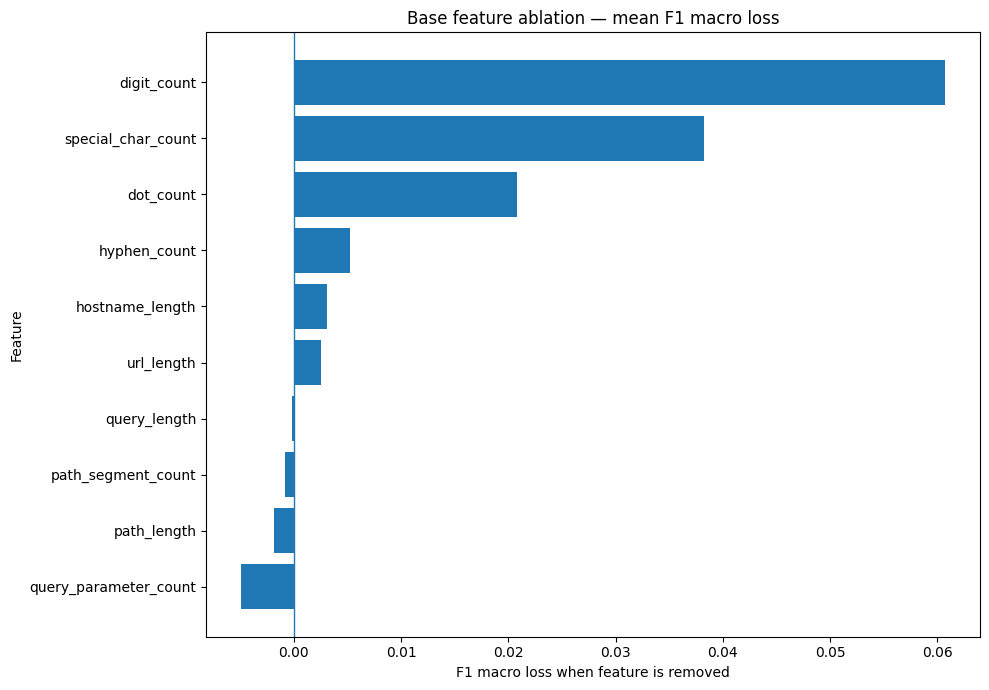

In [137]:
ablation_plot = (
    base_ablation_summary
    .sort_values("f1_macro_loss_mean", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    ablation_plot["feature"],
    ablation_plot["f1_macro_loss_mean"],
)
ax.axvline(0.0, linewidth=1)
ax.set_title("Base feature ablation — mean F1 macro loss")
ax.set_xlabel("F1 macro loss when feature is removed")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

### 17.1 Résultat de l'ablation multivariée initiale

L'ablation des features de base a été réalisée sur un sous-dataset contrôlé et équilibré, avec une validation groupée par `hostname` et trois seeds indépendants (`42`, `7`, `2026`).

L'objectif était de mesurer la contribution réelle de chaque feature dans un contexte multivarié en comparant les performances du modèle complet avec celles obtenues après suppression individuelle de chaque variable.

Les résultats montrent que :

- `digit_count` présente la contribution la plus importante. Sa suppression entraîne une baisse moyenne d'environ `0.061` du F1 macro et `0.058` de la balanced accuracy.
- `special_char_count` apporte également une contribution importante et reproductible, avec une perte moyenne de F1 macro d'environ `0.038`.
- `dot_count` reste utile après contrôle des principaux risques de source proxy, avec une perte moyenne de F1 macro d'environ `0.021` lorsqu'il est supprimé.
- `hyphen_count`, `hostname_length` et `url_length` apportent une contribution plus faible, mais positive et reproductible sur les trois échantillonnages.
- `query_length` et `query_parameter_count` n'apportent pas de gain mesurable dans cette configuration. Leur suppression ne dégrade pas les performances et peut même légèrement les améliorer.
- `path_segment_count` présente peu d'effet sur le F1 macro ou la balanced accuracy, mais semble contribuer à la log-loss. Cette feature reste donc en observation.
- `path_length` n'apporte pas de gain direct lorsqu'elle est utilisée comme feature indépendante dans ce contexte. Elle reste cependant nécessaire comme primitive pour calculer l'interaction normalisée validée avec `special_char_ratio`.

Un résultat important concerne `digit_count`. Bien que cette feature ait montré une certaine sensibilité lors du proxy-controlled stress test, l'ablation multivariée montre qu'elle conserve une contribution significative après neutralisation des principaux proxies liés aux sources. Elle ne doit donc pas être écartée uniquement sur la base de sa Mutual Information individuelle.

Cette analyse confirme qu'une feature faiblement informative lorsqu'elle est étudiée isolément peut néanmoins apporter une information complémentaire importante lorsqu'elle est combinée avec les autres variables.

#### État provisoire

**Features de base fortement soutenues :**

- `digit_count`
- `special_char_count`
- `dot_count`

**Features utiles mais à contribution plus faible :**

- `hyphen_count`
- `hostname_length`
- `url_length`

**Feature encore en observation :**

- `path_segment_count`

**Candidates à la suppression :**

- `query_length`
- `query_parameter_count`

`path_length` reste disponible comme primitive de calcul pour les interactions, même si son intérêt comme feature indépendante doit encore être confirmé.


### 17.2 Backward elimination séquentielle


In [138]:
STRONG_BASE_FEATURES = [
    "digit_count",
    "special_char_count",
    "dot_count",
]

In [139]:
#Nouveau Feature Set après suppression de query_parameter_count
BACKWARD_CURRENT_FEATURES = [
    *CONFIRMED_CORE_FEATURES,

    # Base features
    "url_length",
    "hostname_length",
    "path_length",
    "query_length",
    "dot_count",
    "hyphen_count",
    "digit_count",
    "special_char_count",
    "path_segment_count",

    # Interaction validée
    INTERACTION_FEATURE,
]

In [140]:
# vérification
assert (
    "query_parameter_count"
    not in BACKWARD_CURRENT_FEATURES
)

print(
    "Current feature count:",
    len(BACKWARD_CURRENT_FEATURES),
)

Current feature count: 14


In [141]:
BACKWARD_CANDIDATES = [
    "query_length",
    "path_length",
    "path_segment_count",
    "hyphen_count",
    "hostname_length",
    "url_length",
]

In [142]:
#Fonction pour une étape de backward elimination
def run_backward_round(
    *,
    current_features: list[str],
    candidates: list[str],
    seeds: list[int],
) -> tuple[
    pd.DataFrame,
    pd.DataFrame,
]:
    baseline_rows = []
    removal_rows = []

    for seed in seeds:
        sample = build_ablation_sample(
            seed=seed
        )

        y = (
            label_encoder.transform(
                sample["label"]
            )
        )

        groups = (
            sample["hostname"]
            .astype(str)
        )

        grouped_cv = StratifiedGroupKFold(
            n_splits=5,
            shuffle=True,
            random_state=seed,
        )

        splits = list(
            grouped_cv.split(
                sample[current_features],
                y,
                groups=groups,
            )
        )

        baseline = evaluate_feature_set(
            sample=sample,
            feature_columns=current_features,
            splits=splits,
        )

        baseline_rows.append(
            {
                "seed": seed,
                **baseline,
            }
        )

        for feature in candidates:
            if feature not in current_features:
                continue

            reduced_features = [
                column
                for column in current_features
                if column != feature
            ]

            reduced = evaluate_feature_set(
                sample=sample,
                feature_columns=reduced_features,
                splits=splits,
            )

            removal_rows.append(
                {
                    "seed": seed,
                    "feature": feature,

                    # Positif :
                    # supprimer la feature dégrade
                    # la performance.
                    "balanced_accuracy_loss": (
                        baseline[
                            "balanced_accuracy"
                        ]
                        - reduced[
                            "balanced_accuracy"
                        ]
                    ),

                    "f1_macro_loss": (
                        baseline[
                            "f1_macro"
                        ]
                        - reduced[
                            "f1_macro"
                        ]
                    ),

                    # Positif :
                    # supprimer la feature dégrade
                    # la log-loss.
                    "log_loss_increase": (
                        reduced[
                            "log_loss"
                        ]
                        - baseline[
                            "log_loss"
                        ]
                    ),
                }
            )

    return (
        pd.DataFrame(
            baseline_rows
        ),
        pd.DataFrame(
            removal_rows
        ),
    )

In [143]:
#premier round
(
    backward_baseline,
    backward_round_results,
) = run_backward_round(
    current_features=BACKWARD_CURRENT_FEATURES,
    candidates=BACKWARD_CANDIDATES,
    seeds=ABLATION_SEEDS,
)

In [144]:
# résumé
backward_baseline[
    [
        "balanced_accuracy",
        "f1_macro",
        "log_loss",
    ]
].agg(
    [
        "mean",
        "std",
        "min",
        "max",
    ]
)

,balanced_accuracy,f1_macro,log_loss
mean,0.716717,0.711471,0.643468
std,0.021559,0.023849,0.036041
min,0.697561,0.691054,0.612547
max,0.740064,0.737685,0.683051


In [145]:
# résumé des suppressions possibles
backward_round_summary = (
    backward_round_results
    .groupby(
        "feature",
        as_index=False,
    )
    .agg(
        balanced_accuracy_loss_mean=(
            "balanced_accuracy_loss",
            "mean",
        ),
        balanced_accuracy_loss_std=(
            "balanced_accuracy_loss",
            "std",
        ),
        balanced_accuracy_loss_min=(
            "balanced_accuracy_loss",
            "min",
        ),

        f1_macro_loss_mean=(
            "f1_macro_loss",
            "mean",
        ),
        f1_macro_loss_std=(
            "f1_macro_loss",
            "std",
        ),
        f1_macro_loss_min=(
            "f1_macro_loss",
            "min",
        ),

        log_loss_increase_mean=(
            "log_loss_increase",
            "mean",
        ),
        log_loss_increase_min=(
            "log_loss_increase",
            "min",
        ),
    )
    .sort_values(
        "f1_macro_loss_mean",
        ascending=True,
    )
    .reset_index(
        drop=True
    )
)

backward_round_summary

,feature,balanced_accuracy_loss_mean,balanced_accuracy_loss_std,balanced_accuracy_loss_min,f1_macro_loss_mean,f1_macro_loss_std,f1_macro_loss_min,log_loss_increase_mean,log_loss_increase_min
0,path_length,-0.000839,0.001497,-0.002556,-0.001281,0.002202,-0.003803,-0.001802,-0.005849
1,query_length,0.000340,0.000038,0.000297,0.000455,0.000059,0.000396,0.000422,0.000414
2,path_segment_count,0.001414,0.002164,-0.000972,0.000904,0.004497,-0.004197,0.019152,0.010346
3,hostname_length,0.002187,0.001455,0.000858,0.002885,0.002134,0.000967,0.001031,-0.000237
4,url_length,0.002777,0.000786,0.001891,0.003035,0.000777,0.002235,0.004705,0.002881
5,hyphen_count,0.008053,0.002779,0.004968,0.010464,0.004407,0.005446,0.023729,0.021126


### 17.3 Round 2 — suppression de `path_length` comme feature ML directe

Le premier round désigne `path_length` comme meilleure candidate à la suppression. Elle reste néanmoins une **primitive interne** nécessaire au calcul de l'interaction validée avec `special_char_ratio`. Une nouvelle ablation est exécutée après son retrait du Feature Set exposé au modèle.


In [146]:
BACKWARD_CURRENT_FEATURES = [
    feature
    for feature in BACKWARD_CURRENT_FEATURES
    if feature != "path_length"
]


BACKWARD_CANDIDATES = [
    "query_length",
    "path_segment_count",
    "hyphen_count",
    "hostname_length",
    "url_length",
]


print(
    "Current features:",
    len(BACKWARD_CURRENT_FEATURES),
)

print(
    BACKWARD_CURRENT_FEATURES
)

Current features: 13
['hostname_entropy', 'mean_hostname_label_length', 'path_to_url_length_ratio', 'special_char_ratio', 'url_length', 'hostname_length', 'query_length', 'dot_count', 'hyphen_count', 'digit_count', 'special_char_count', 'path_segment_count', 'interaction_068']


In [147]:
(
    backward_baseline_round_2,
    backward_round_2_results,
) = run_backward_round(
    current_features=BACKWARD_CURRENT_FEATURES,
    candidates=BACKWARD_CANDIDATES,
    seeds=ABLATION_SEEDS,
)

In [148]:
backward_baseline_round_2[
    [
        "balanced_accuracy",
        "f1_macro",
        "log_loss",
    ]
].agg(
    [
        "mean",
        "std",
        "min",
        "max",
    ]
)

,balanced_accuracy,f1_macro,log_loss
mean,0.717556,0.712753,0.641666
std,0.020324,0.022080,0.032698
min,0.700118,0.694857,0.612848
max,0.739876,0.737427,0.677201


In [149]:
backward_round_2_summary = (
    backward_round_2_results
    .groupby(
        "feature",
        as_index=False,
    )
    .agg(
        balanced_accuracy_loss_mean=(
            "balanced_accuracy_loss",
            "mean",
        ),
        balanced_accuracy_loss_std=(
            "balanced_accuracy_loss",
            "std",
        ),
        balanced_accuracy_loss_min=(
            "balanced_accuracy_loss",
            "min",
        ),
        f1_macro_loss_mean=(
            "f1_macro_loss",
            "mean",
        ),
        f1_macro_loss_std=(
            "f1_macro_loss",
            "std",
        ),
        f1_macro_loss_min=(
            "f1_macro_loss",
            "min",
        ),
        log_loss_increase_mean=(
            "log_loss_increase",
            "mean",
        ),
        log_loss_increase_min=(
            "log_loss_increase",
            "min",
        ),
    )
    .sort_values(
        "f1_macro_loss_mean",
        ascending=True,
    )
    .reset_index(
        drop=True
    )
)

backward_round_2_summary

,feature,balanced_accuracy_loss_mean,balanced_accuracy_loss_std,balanced_accuracy_loss_min,f1_macro_loss_mean,f1_macro_loss_std,f1_macro_loss_min,log_loss_increase_mean,log_loss_increase_min
0,query_length,-0.001030,0.002139,-0.003496,-0.001106,0.003368,-0.004946,-0.004171,-0.011153
1,path_segment_count,0.001741,0.001397,0.000308,0.001329,0.003534,-0.002655,0.019724,0.011671
2,hyphen_count,0.007741,0.002909,0.004669,0.009834,0.004418,0.005023,0.023174,0.020555
3,hostname_length,0.007508,0.001438,0.006535,0.010017,0.001905,0.008901,0.020045,0.016847
4,url_length,0.029210,0.013509,0.019889,0.034396,0.014622,0.023443,0.070446,0.061047


In [150]:
# round 3
BACKWARD_CURRENT_FEATURES = [
    feature
    for feature in BACKWARD_CURRENT_FEATURES
    if feature != "query_length"
]


BACKWARD_CANDIDATES = [
    "path_segment_count",
    "hyphen_count",
    "hostname_length",
    "url_length",
]


print(
    "Current feature count:",
    len(BACKWARD_CURRENT_FEATURES),
)

print(
    BACKWARD_CURRENT_FEATURES
)

Current feature count: 12
['hostname_entropy', 'mean_hostname_label_length', 'path_to_url_length_ratio', 'special_char_ratio', 'url_length', 'hostname_length', 'dot_count', 'hyphen_count', 'digit_count', 'special_char_count', 'path_segment_count', 'interaction_068']


In [151]:
(
    backward_baseline_round_3,
    backward_round_3_results,
) = run_backward_round(
    current_features=BACKWARD_CURRENT_FEATURES,
    candidates=BACKWARD_CANDIDATES,
    seeds=ABLATION_SEEDS,
)

In [152]:
backward_baseline_round_3[
    [
        "balanced_accuracy",
        "f1_macro",
        "log_loss",
    ]
].agg(
    [
        "mean",
        "std",
        "min",
        "max",
    ]
)

,balanced_accuracy,f1_macro,log_loss
mean,0.718587,0.713858,0.637496
std,0.018887,0.020310,0.027700
min,0.703614,0.699803,0.610735
max,0.739805,0.737144,0.666048


In [153]:
backward_round_3_summary = (
    backward_round_3_results
    .groupby(
        "feature",
        as_index=False,
    )
    .agg(
        balanced_accuracy_loss_mean=(
            "balanced_accuracy_loss",
            "mean",
        ),
        balanced_accuracy_loss_std=(
            "balanced_accuracy_loss",
            "std",
        ),
        balanced_accuracy_loss_min=(
            "balanced_accuracy_loss",
            "min",
        ),

        f1_macro_loss_mean=(
            "f1_macro_loss",
            "mean",
        ),
        f1_macro_loss_std=(
            "f1_macro_loss",
            "std",
        ),
        f1_macro_loss_min=(
            "f1_macro_loss",
            "min",
        ),

        log_loss_increase_mean=(
            "log_loss_increase",
            "mean",
        ),
        log_loss_increase_min=(
            "log_loss_increase",
            "min",
        ),
    )
    .sort_values(
        "f1_macro_loss_mean",
        ascending=True,
    )
    .reset_index(
        drop=True
    )
)

backward_round_3_summary

,feature,balanced_accuracy_loss_mean,balanced_accuracy_loss_std,balanced_accuracy_loss_min,f1_macro_loss_mean,f1_macro_loss_std,f1_macro_loss_min,log_loss_increase_mean,log_loss_increase_min
0,path_segment_count,0.000276,0.001952,-0.001640,-0.000590,0.003594,-0.004425,0.019955,0.013915
1,hyphen_count,0.007560,0.003392,0.003684,0.008880,0.004509,0.003749,0.021257,0.020162
2,hostname_length,0.015571,0.008461,0.005870,0.021287,0.011550,0.008084,0.033982,0.029499
3,url_length,0.036374,0.013894,0.028278,0.040742,0.015394,0.031100,0.072143,0.060176


### 17.4 Synthèse des trois rounds de backward elimination

La backward elimination a été réalisée de manière séquentielle afin d'éviter que des features redondantes se masquent mutuellement. À chaque étape, une seule feature a été supprimée avant de réévaluer les restantes sur trois seeds avec validation groupée par `hostname`.

#### Round 1 — après suppression de `query_parameter_count`

La suppression de `query_parameter_count` améliore légèrement le modèle par rapport au Feature Set initial.

`path_length` devient alors la meilleure candidate à retirer :

- F1 macro loss moyen : `-0.00128`
- Balanced accuracy loss moyen : `-0.00084`
- Log-loss increase moyen : `-0.00180`

Sa suppression améliore légèrement les trois métriques.  
`path_length` est donc retirée comme feature ML directe, mais reste calculée comme primitive nécessaire à l'interaction validée avec `special_char_ratio`.

#### Round 2 — après suppression de `path_length`

Après retrait de `path_length`, `query_length` devient à son tour dispensable :

- F1 macro loss moyen : `-0.00111`
- Balanced accuracy loss moyen : `-0.00103`
- Log-loss increase moyen : `-0.00417`

Sa suppression améliore légèrement les performances moyennes.

À l'inverse, `url_length`, `hostname_length` et `hyphen_count` montrent désormais une contribution positive et reproductible.

#### Round 3 — après suppression de `query_length`

Le dernier round confirme fortement l'utilité de :

- `url_length`
- `hostname_length`
- `hyphen_count`

Leur suppression dégrade systématiquement les performances.

`path_segment_count` présente un comportement différent : son impact sur le F1 macro est pratiquement nul, mais sa suppression augmente systématiquement la log-loss (`+0.01996` en moyenne). Elle est donc conservée pour sa contribution à la qualité probabiliste du modèle.

#### Décision après les trois rounds

**Suppressions confirmées :**

- `query_parameter_count`
- `query_length`
- `path_length` comme feature ML directe

**Features de base conservées :**

- `url_length`
- `hostname_length`
- `dot_count`
- `hyphen_count`
- `digit_count`
- `special_char_count`
- `path_segment_count`

Cette élimination séquentielle permet de conserver uniquement les features présentant une contribution complémentaire mesurable, tout en réduisant la redondance du Feature Set V1.


## 18. Dernier écran d'interactions ciblées


Après l'ablation des features de base, l'exploration des interactions est volontairement restreinte : nous croisons uniquement les **7 bases survivantes** avec les **4 features engineered validées**, et seulement via `normalized_product`.

Ce choix limite le nombre de candidates à $7 \times 4 = 28$ et réduit le risque d'overfitting par feature mining.


In [154]:
FINAL_BASE_INTERACTION_FEATURES = [
    "url_length",
    "hostname_length",
    "dot_count",
    "hyphen_count",
    "digit_count",
    "special_char_count",
    "path_segment_count",
]


FINAL_ENGINEERED_INTERACTION_FEATURES = [
    "hostname_entropy",
    "mean_hostname_label_length",
    "path_to_url_length_ratio",
    "special_char_ratio",
]

In [155]:
final_interaction_df = pd.DataFrame(
    {
        "record_id": features_df["record_id"],
        "label": features_df["label"],
    }
)


final_interaction_metadata = []

candidate_index = 1


for base_feature in FINAL_BASE_INTERACTION_FEATURES:
    for engineered_feature in (
        FINAL_ENGINEERED_INTERACTION_FEATURES
    ):
        left = (
            features_df[
                base_feature
            ]
            .astype(float)
        )

        right = (
            features_df[
                engineered_feature
            ]
            .astype(float)
        )

        candidate = (
            f"final_interaction_{candidate_index:02d}"
        )

        final_interaction_df[
            candidate
        ] = (
            normalized_product(
                left,
                right,
            )
        )

        final_interaction_metadata.append(
            {
                "candidate": candidate,
                "base_feature": base_feature,
                "engineered_feature": (
                    engineered_feature
                ),
                "operation": (
                    "normalized_product"
                ),
            }
        )

        candidate_index += 1


final_interaction_metadata_df = (
    pd.DataFrame(
        final_interaction_metadata
    )
)


FINAL_INTERACTION_COLUMNS = (
    final_interaction_metadata_df[
        "candidate"
    ]
    .tolist()
)


print(
    "Generated candidates:",
    len(FINAL_INTERACTION_COLUMNS),
)

Generated candidates: 28


In [156]:
# vérification numérique
final_interaction_values = (
    final_interaction_df[
        FINAL_INTERACTION_COLUMNS
    ]
    .to_numpy(
        dtype=float
    )
)


if not np.isfinite(
    final_interaction_values
).all():
    raise RuntimeError(
        "Non-finite values detected "
        "in final interaction candidates."
    )


print(
    "All final interactions are finite."
)

All final interactions are finite.


In [157]:
# MI sur dataset équilibré
balanced_final_interactions_df = (
    balanced_features_df[
        [
            "record_id",
            "label",
        ]
    ]
    .merge(
        final_interaction_df,
        on=[
            "record_id",
            "label",
        ],
        how="inner",
        validate="one_to_one",
    )
)

In [158]:
X_final_interactions = (
    balanced_final_interactions_df[
        FINAL_INTERACTION_COLUMNS
    ]
    .astype(float)
)


y_final_interactions = (
    label_encoder.transform(
        balanced_final_interactions_df[
            "label"
        ]
    )
)


final_interaction_mi_scores = (
    mutual_info_classif(
        X_final_interactions,
        y_final_interactions,
        discrete_features=False,
        random_state=42,
    )
)


final_interaction_mi = (
    pd.DataFrame(
        {
            "candidate": (
                FINAL_INTERACTION_COLUMNS
            ),
            "mutual_information": (
                final_interaction_mi_scores
            ),
        }
    )
    .merge(
        final_interaction_metadata_df,
        on="candidate",
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        "mutual_information",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


final_interaction_mi

,candidate,mutual_information,base_feature,engineered_feature,operation
0,final_interaction_07,0.750762,hostname_length,path_to_url_length_ratio,normalized_product
1,final_interaction_25,0.728357,path_segment_count,hostname_entropy,normalized_product
2,final_interaction_02,0.707924,url_length,mean_hostname_label_length,normalized_product
3,final_interaction_01,0.701345,url_length,hostname_entropy,normalized_product
4,final_interaction_09,0.683844,dot_count,hostname_entropy,normalized_product
5,final_interaction_21,0.659326,special_char_count,hostname_entropy,normalized_product
6,final_interaction_23,0.656536,special_char_count,path_to_url_length_ratio,normalized_product
7,final_interaction_11,0.647887,dot_count,path_to_url_length_ratio,normalized_product
8,final_interaction_03,0.636925,url_length,path_to_url_length_ratio,normalized_product
9,final_interaction_08,0.608629,hostname_length,special_char_ratio,normalized_product


In [159]:
# comparaison avec le meilleur parent
base_mi_lookup = (
    mutual_information
    .set_index(
        "feature"
    )[
        "mutual_information"
    ]
    .to_dict()
)


final_interaction_gain_rows = []


for row in final_interaction_mi.itertuples(
    index=False
):
    base_parent_mi = float(
        base_mi_lookup[
            row.base_feature
        ]
    )

    engineered_parent_mi = float(
        base_mi_lookup[
            row.engineered_feature
        ]
    )

    best_parent_mi = max(
        base_parent_mi,
        engineered_parent_mi,
    )

    final_interaction_gain_rows.append(
        {
            "candidate": row.candidate,
            "base_feature": (
                row.base_feature
            ),
            "engineered_feature": (
                row.engineered_feature
            ),
            "interaction_mi": (
                row.mutual_information
            ),
            "best_parent_mi": (
                best_parent_mi
            ),
            "absolute_gain": (
                row.mutual_information
                - best_parent_mi
            ),
            "relative_gain_pct": (
                (
                    row.mutual_information
                    / best_parent_mi
                    - 1.0
                )
                * 100
                if best_parent_mi > 0
                else np.nan
            ),
        }
    )


final_interaction_gain = (
    pd.DataFrame(
        final_interaction_gain_rows
    )
    .sort_values(
        "absolute_gain",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


final_interaction_gain

,candidate,base_feature,engineered_feature,interaction_mi,best_parent_mi,absolute_gain,relative_gain_pct
0,final_interaction_02,url_length,mean_hostname_label_length,0.707924,0.408535,0.299389,73.283701
1,final_interaction_08,hostname_length,special_char_ratio,0.608629,0.339298,0.269332,79.379137
2,final_interaction_07,hostname_length,path_to_url_length_ratio,0.750762,0.568580,0.182181,32.041478
3,final_interaction_26,path_segment_count,mean_hostname_label_length,0.589085,0.408535,0.180551,44.194687
4,final_interaction_28,path_segment_count,special_char_ratio,0.491309,0.339298,0.152011,44.801779
5,final_interaction_06,hostname_length,mean_hostname_label_length,0.544723,0.408535,0.136189,33.335920
6,final_interaction_22,special_char_count,mean_hostname_label_length,0.541922,0.408535,0.133387,32.650164
7,final_interaction_25,path_segment_count,hostname_entropy,0.728357,0.605294,0.123063,20.331064
8,final_interaction_04,url_length,special_char_ratio,0.458689,0.339298,0.119391,35.187649
9,final_interaction_12,dot_count,special_char_ratio,0.456280,0.339298,0.116982,34.477660


### 18.1 Shortlist après Mutual Information et gain par rapport aux parents

Parmi les 28 interactions, seules quatre candidates sont conservées pour le contrôle de redondance. Les autres sont soit moins informatives, soit déjà représentées par des formulations plus simples.


In [160]:
FINAL_INTERACTION_SHORTLIST = [
    "final_interaction_08",
    "final_interaction_26",
    "final_interaction_25",
    "final_interaction_28",
]

Les quatre candidates correspondent aux relations suivantes :

- `final_interaction_08` : `hostname_length × special_char_ratio`
- `final_interaction_26` : `path_segment_count × mean_hostname_label_length`
- `final_interaction_25` : `path_segment_count × hostname_entropy`
- `final_interaction_28` : `path_segment_count × special_char_ratio`

Toutes utilisent la transformation `normalized_product`.


In [161]:
FINAL_INTERACTION_SHORTLIST = [
    "final_interaction_08",
    "final_interaction_26",
    "final_interaction_25",
    "final_interaction_28",
]


SHORTLIST_PARENT_FEATURES = [
    "hostname_length",
    "path_segment_count",
    "special_char_ratio",
    "mean_hostname_label_length",
    "hostname_entropy",
]


final_shortlist_analysis_df = (
    balanced_features_df[
        [
            "record_id",
            *SHORTLIST_PARENT_FEATURES,
        ]
    ]
    .merge(
        balanced_final_interactions_df[
            [
                "record_id",
                *FINAL_INTERACTION_SHORTLIST,
            ]
        ],
        on="record_id",
        how="inner",
        validate="one_to_one",
    )
)

In [162]:
final_shortlist_correlation = (
    final_shortlist_analysis_df[
        FINAL_INTERACTION_SHORTLIST
    ]
    .corr(
        method="spearman"
    )
)

final_shortlist_correlation.round(4)

,final_interaction_08,final_interaction_26,final_interaction_25,final_interaction_28
final_interaction_08,1.0000,-0.4707,-0.4454,0.3651
final_interaction_26,-0.4707,1.0000,0.9840,0.5275
final_interaction_25,-0.4454,0.9840,1.0000,0.5574
final_interaction_28,0.3651,0.5275,0.5574,1.0000


In [163]:
# puis avec leurs features parentes 
parent_correlation_rows = []

for candidate in FINAL_INTERACTION_SHORTLIST:
    for parent in SHORTLIST_PARENT_FEATURES:
        correlation = float(
            final_shortlist_analysis_df[
                [
                    candidate,
                    parent,
                ]
            ]
            .corr(
                method="spearman"
            )
            .iloc[0, 1]
        )

        parent_correlation_rows.append(
            {
                "candidate": candidate,
                "parent_feature": parent,
                "spearman": correlation,
                "abs_spearman": abs(
                    correlation
                ),
            }
        )


final_parent_correlations = (
    pd.DataFrame(
        parent_correlation_rows
    )
    .sort_values(
        "abs_spearman",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

final_parent_correlations

,candidate,parent_feature,spearman,abs_spearman
0,final_interaction_08,special_char_ratio,0.990666,0.990666
1,final_interaction_25,path_segment_count,0.954016,0.954016
2,final_interaction_26,path_segment_count,0.946461,0.946461
3,final_interaction_28,path_segment_count,0.704800,0.704800
4,final_interaction_08,mean_hostname_label_length,-0.572411,0.572411
5,final_interaction_28,mean_hostname_label_length,-0.507507,0.507507
6,final_interaction_08,hostname_entropy,-0.503730,0.503730
7,final_interaction_26,special_char_ratio,-0.467291,0.467291
8,final_interaction_28,hostname_entropy,-0.456678,0.456678
9,final_interaction_25,special_char_ratio,-0.442416,0.442416


In [164]:
final_parent_correlations.loc[
    final_parent_correlations[
        "abs_spearman"
    ]
    >= 0.90
]

,candidate,parent_feature,spearman,abs_spearman
0,final_interaction_08,special_char_ratio,0.990666,0.990666
1,final_interaction_25,path_segment_count,0.954016,0.954016
2,final_interaction_26,path_segment_count,0.946461,0.946461


### 18.2 Sélection de l'interaction finale à tester

Après analyse des quatre interactions candidates restantes, trois d'entre elles ont été écartées pour forte redondance avec une feature déjà présente :

- `final_interaction_08` est presque parfaitement corrélée avec `special_char_ratio` (`ρ ≈ 0.991`).
- `final_interaction_25` est fortement corrélée avec `path_segment_count` (`ρ ≈ 0.954`).
- `final_interaction_26` est également fortement corrélée avec `path_segment_count` (`ρ ≈ 0.946`).

De plus, `final_interaction_25` et `final_interaction_26` sont elles-mêmes très fortement corrélées (`ρ ≈ 0.984`), ce qui confirme qu'elles représentent essentiellement le même signal.

La seule interaction suffisamment complémentaire est donc :

`final_interaction_28 = normalized_product(path_segment_count, special_char_ratio)`

Elle présente :

- une Mutual Information de `0.491`,
- un gain absolu de `+0.152` par rapport à son meilleur parent,
- une corrélation modérée avec `path_segment_count` (`ρ ≈ 0.705`),
- une faible corrélation avec `special_char_ratio` (`ρ ≈ 0.387`).

`final_interaction_28` est donc la seule interaction retenue pour le dernier test de robustesse et de valeur incrémentale avant de figer définitivement le Feature Set V1.


### 18.3 Test final de `final_interaction_28`

La dernière candidate est évaluée sur un sous-dataset proxy-controlled, équilibré, avec validation groupée par `hostname` et trois seeds. Ce test vérifie sa valeur incrémentale par rapport à `path_segment_count` et `special_char_ratio`.


In [165]:
# dataset de test final
FINAL_CANDIDATE = "final_interaction_28"

FINAL_CANDIDATE_PARENTS = [
    "path_segment_count",
    "special_char_ratio",
]


final_candidate_source_df = (
    proxy_controlled_df[
        [
            "record_id",
            "label",
            "hostname",
            *FINAL_CANDIDATE_PARENTS,
        ]
    ]
    .merge(
        final_interaction_df[
            [
                "record_id",
                FINAL_CANDIDATE,
            ]
        ],
        on="record_id",
        how="inner",
        validate="one_to_one",
    )
)

In [166]:
#contrôl
required_columns = [
    *FINAL_CANDIDATE_PARENTS,
    FINAL_CANDIDATE,
]


values = (
    final_candidate_source_df[
        required_columns
    ]
    .to_numpy(
        dtype=float
    )
)


if not np.isfinite(values).all():
    raise RuntimeError(
        "Non-finite values detected "
        "in final candidate dataset."
    )


print(
    final_candidate_source_df[
        "label"
    ]
    .value_counts()
)

label
benign      29830
phishing    27773
malware     10357
Name: count, dtype: int64


In [167]:
# équilibrage
final_candidate_n = int(
    final_candidate_source_df[
        "label"
    ]
    .value_counts()
    .min()
)


def build_final_candidate_sample(
    *,
    seed: int,
) -> pd.DataFrame:
    frames = []

    for label in LABELS:
        frames.append(
            final_candidate_source_df.loc[
                final_candidate_source_df[
                    "label"
                ]
                == label
            ]
            .sample(
                n=final_candidate_n,
                replace=False,
                random_state=seed,
            )
        )

    return (
        pd.concat(
            frames,
            ignore_index=True,
        )
        .sample(
            frac=1.0,
            random_state=seed,
        )
        .reset_index(
            drop=True
        )
    )

In [168]:
# feature sets comparés
FINAL_CANDIDATE_FEATURE_SETS = {
    "parents_only": [
        "path_segment_count",
        "special_char_ratio",
    ],

    "interaction_only": [
        FINAL_CANDIDATE,
    ],

    "parents_plus_interaction": [
        "path_segment_count",
        "special_char_ratio",
        FINAL_CANDIDATE,
    ],
}

In [169]:
#Test group-aware sur trois seeds
FINAL_CANDIDATE_SEEDS = [
    42,
    7,
    2026,
]


final_candidate_rows = []


for seed in FINAL_CANDIDATE_SEEDS:
    sample = build_final_candidate_sample(
        seed=seed
    )

    y = label_encoder.transform(
        sample["label"]
    )

    groups = (
        sample["hostname"]
        .astype(str)
    )

    cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed,
    )

    splits = list(
        cv.split(
            sample,
            y,
            groups=groups,
        )
    )

    for feature_set_name, columns in (
        FINAL_CANDIDATE_FEATURE_SETS.items()
    ):
        result = evaluate_feature_set(
            sample=sample,
            feature_columns=columns,
            splits=splits,
        )

        final_candidate_rows.append(
            {
                "seed": seed,
                "feature_set": (
                    feature_set_name
                ),
                **result,
            }
        )


final_candidate_results = (
    pd.DataFrame(
        final_candidate_rows
    )
)

final_candidate_results

,seed,feature_set,balanced_accuracy,f1_macro,log_loss
0,42,parents_only,0.567802,0.549950,1.020142
1,42,interaction_only,0.423900,0.359055,1.055600
2,42,parents_plus_interaction,0.608420,0.588677,0.864701
3,7,parents_only,0.568962,0.558693,1.019909
4,7,interaction_only,0.421234,0.369699,1.066394
5,7,parents_plus_interaction,0.622223,0.614160,0.873994
6,2026,parents_only,0.508714,0.477757,1.063985
7,2026,interaction_only,0.407048,0.330368,1.099852
8,2026,parents_plus_interaction,0.596914,0.571639,0.910144


In [170]:
# synthèse
final_candidate_summary = (
    final_candidate_results
    .groupby(
        "feature_set",
        as_index=False,
    )
    .agg(
        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean",
        ),
        balanced_accuracy_std=(
            "balanced_accuracy",
            "std",
        ),
        f1_macro_mean=(
            "f1_macro",
            "mean",
        ),
        f1_macro_std=(
            "f1_macro",
            "std",
        ),
        log_loss_mean=(
            "log_loss",
            "mean",
        ),
        log_loss_std=(
            "log_loss",
            "std",
        ),
    )
    .sort_values(
        "f1_macro_mean",
        ascending=False,
    )
)

final_candidate_summary

,feature_set,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std,log_loss_mean,log_loss_std
2,parents_plus_interaction,0.609186,0.012672,0.591492,0.021399,0.882946,0.024008
1,parents_only,0.548493,0.034454,0.528800,0.044420,1.034679,0.025380
0,interaction_only,0.417394,0.009058,0.353041,0.020344,1.073949,0.023073


In [171]:
# gain seed par seed
pivot = (
    final_candidate_results
    .pivot(
        index="seed",
        columns="feature_set",
        values=[
            "balanced_accuracy",
            "f1_macro",
            "log_loss",
        ],
    )
)


final_candidate_gain = pd.DataFrame(
    {
        "balanced_accuracy_gain": (
            pivot[
                (
                    "balanced_accuracy",
                    "parents_plus_interaction",
                )
            ]
            - pivot[
                (
                    "balanced_accuracy",
                    "parents_only",
                )
            ]
        ),

        "f1_macro_gain": (
            pivot[
                (
                    "f1_macro",
                    "parents_plus_interaction",
                )
            ]
            - pivot[
                (
                    "f1_macro",
                    "parents_only",
                )
            ]
        ),

        "log_loss_reduction": (
            pivot[
                (
                    "log_loss",
                    "parents_only",
                )
            ]
            - pivot[
                (
                    "log_loss",
                    "parents_plus_interaction",
                )
            ]
        ),
    }
).reset_index()


final_candidate_gain

,seed,balanced_accuracy_gain,f1_macro_gain,log_loss_reduction
0,7,0.053261,0.055467,0.145915
1,42,0.040618,0.038727,0.155442
2,2026,0.088200,0.093882,0.153841


#### Visualisation — gain incrémental de l'interaction finale

Les trois métriques doivent évoluer dans le bon sens sur chaque seed : gain de balanced accuracy, gain de F1 macro et réduction de log-loss.

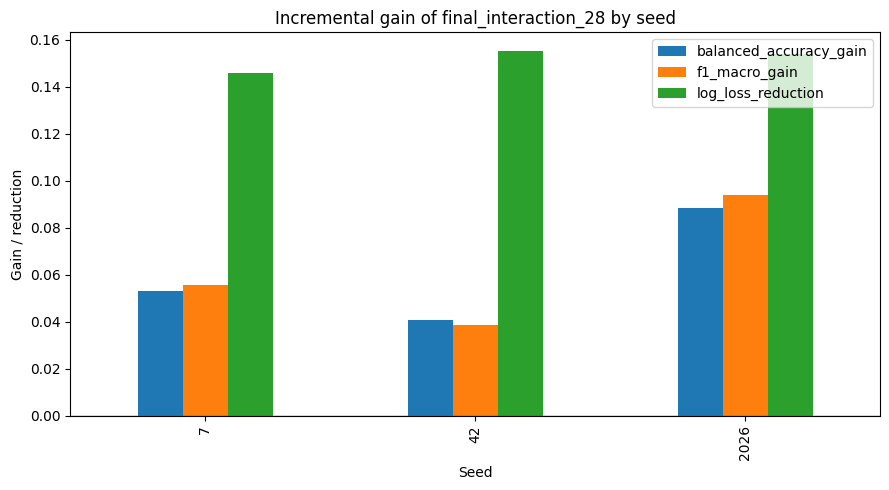

In [172]:
gain_plot = final_candidate_gain.set_index("seed")

fig, ax = plt.subplots(figsize=(9, 5))
gain_plot[
    [
        "balanced_accuracy_gain",
        "f1_macro_gain",
        "log_loss_reduction",
    ]
].plot.bar(ax=ax)
ax.axhline(0.0, linewidth=1)
ax.set_title("Incremental gain of final_interaction_28 by seed")
ax.set_xlabel("Seed")
ax.set_ylabel("Gain / reduction")
plt.tight_layout()
plt.show()

## 19. Feature Set V1 consolidé après toutes les expériences
Après toutes les analyses, ablations, tests de robustesse et interactions, notre Feature Set V1 final candidat contient 13 features.


In [173]:
FEATURES_V1 = [
    # Base features
    "url_length",
    "hostname_length",
    "dot_count",
    "hyphen_count",
    "digit_count",
    "special_char_count",
    "path_segment_count",

    # Engineered features
    "hostname_entropy",
    "mean_hostname_label_length",
    "path_to_url_length_ratio",
    "special_char_ratio",

    # Validated interactions
    "path_length_special_char_ratio_product",
    "path_segment_count_special_char_ratio_product",
]

### Des expériences à la décision finale

Les expériences successives convergent désormais : les features engineered robustes sont identifiées, les features de base ont été réévaluées en contexte multivarié, et deux interactions ont démontré une valeur incrémentale reproductible. La section suivante consolide le contrat Feature Set V1 qui servira à l'intégration de production.

## 20. PCA du Feature Set V1 — visualisation exploratoire finale

PCA ne sera pas nécessairement utilisée dans le modèle.

Elle sert uniquement à observer si la représentation lexicale crée naturellement :

- des clusters ;
- des séparations ;
- ou au contraire un fort chevauchement entre classes.

Pour éviter un graphique surchargé, on utilise un échantillon stratifié.


In [174]:
PCA_SAMPLE_PER_CLASS = 5_000

FINAL_NON_INTERACTION_FEATURES = [
    "url_length",
    "hostname_length",
    "dot_count",
    "hyphen_count",
    "digit_count",
    "special_char_count",
    "path_segment_count",
    "hostname_entropy",
    "mean_hostname_label_length",
    "path_to_url_length_ratio",
    "special_char_ratio",
]

final_feature_analysis_df = (
    features_df[
        [
            "record_id",
            "label",
            *FINAL_NON_INTERACTION_FEATURES,
        ]
    ]
    .merge(
        interaction_df[["record_id", "interaction_068"]],
        on="record_id",
        how="inner",
        validate="one_to_one",
    )
    .merge(
        final_interaction_df[["record_id", "final_interaction_28"]],
        on="record_id",
        how="inner",
        validate="one_to_one",
    )
    .rename(
        columns={
            "interaction_068": "path_length_special_char_ratio_product",
            "final_interaction_28": "path_segment_count_special_char_ratio_product",
        }
    )
)

pca_parts = []
for label in LABEL_ORDER:
    frame = final_feature_analysis_df.loc[
        final_feature_analysis_df["label"] == label
    ]
    pca_parts.append(
        frame.sample(
            n=min(PCA_SAMPLE_PER_CLASS, len(frame)),
            random_state=RANDOM_SEED,
            replace=False,
        )
    )

pca_sample = pd.concat(pca_parts, ignore_index=True)
pca_sample.shape


(15000, 15)

In [175]:
pca_X = pca_sample[FEATURES_V1].astype(float)

scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_X)

pca = PCA(
    n_components=2,
    random_state=RANDOM_SEED,
)

pca_coordinates = pca.fit_transform(pca_scaled)

print(
    "Explained variance:",
    pca.explained_variance_ratio_,
)
print(
    "Total explained:",
    pca.explained_variance_ratio_.sum(),
)


Explained variance: [0.33746326 0.27934727]
Total explained: 0.6168105308401748


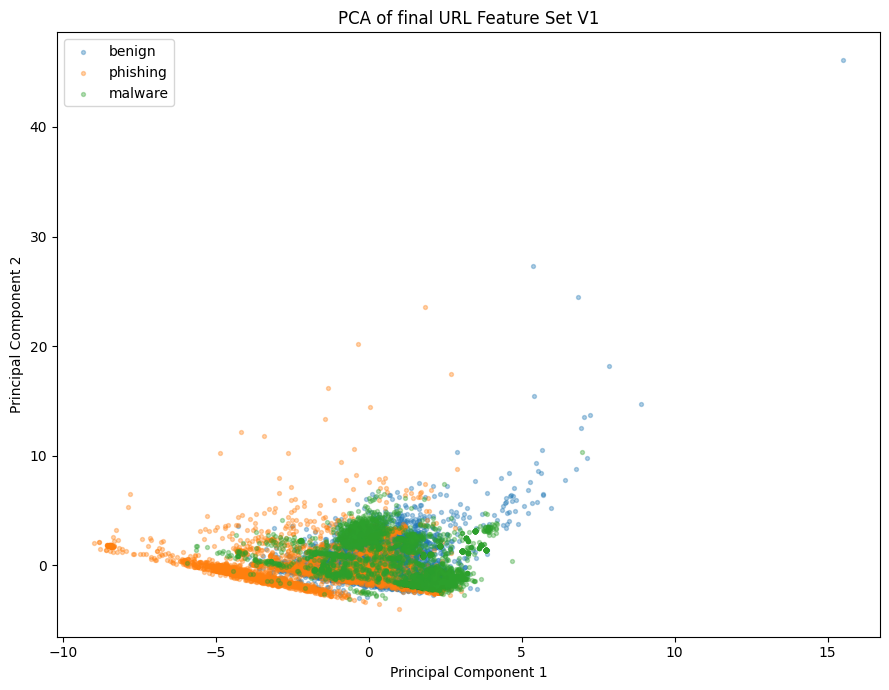

In [176]:
pca_plot = pd.DataFrame(
    {
        "PC1": pca_coordinates[:, 0],
        "PC2": pca_coordinates[:, 1],
        "label": pca_sample["label"].to_numpy(),
    }
)

fig, ax = plt.subplots(figsize=(9, 7))

for label in LABEL_ORDER:
    subset = pca_plot.loc[pca_plot["label"] == label]
    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        s=8,
        alpha=0.35,
        label=label,
    )

ax.set_title("PCA of final URL Feature Set V1")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend()
plt.tight_layout()
plt.show()


### 20.1 Interprétation de la PCA finale

Cette PCA est une **visualisation exploratoire** du Feature Set V1 et non une étape du pipeline de production. Les valeurs de variance expliquée et la géométrie des classes doivent être interprétées uniquement après exécution de ces cellules.
L'objectif est de vérifier visuellement si le Feature Set final produit des structures globales cohérentes ou un chevauchement important entre classes, sans utiliser la PCA comme feature ni comme mécanisme de réduction dimensionnelle dans V1.

La PCA projette ici le Feature Set V1 dans un espace à deux dimensions afin d'obtenir une **vue globale de la structure des observations**.

La PCA est une méthode non supervisée : elle ne cherche pas à séparer `benign`, `phishing` et `malware`. Elle construit simplement des axes qui expliquent une partie importante de la variance présente dans les features.

Le graphique montre plusieurs éléments intéressants.

#### Chevauchement important entre les trois classes

La zone centrale contient un fort mélange de :

- `benign`
- `phishing`
- `malware`

Aucune frontière nette n'apparaît entre les trois populations dans le plan formé par les deux premières composantes principales.

Cela indique qu'après projection linéaire en deux dimensions, les classes ne sont pas séparables par une règle triviale.

Ce résultat est plutôt cohérent avec les analyses précédentes : aucune feature unique ne permet de représenter correctement la totalité du problème et la classification devra exploiter la combinaison de plusieurs signaux.

Il serait donc incorrect d'interpréter cette PCA comme :

```text
absence de séparation PCA
→ features inutiles
````

La PCA compresse les 13 dimensions du Feature Set V1 dans seulement deux axes et une partie de l'information discriminante peut se trouver dans les composantes suivantes ou dans des relations multivariées qui ne sont pas visibles sur ce graphique.

---

#### Structure particulière de la classe `phishing`

La classe `phishing` présente une extension importante vers les valeurs négatives de la première composante principale.

Elle possède également plusieurs observations éloignées du noyau central sur la seconde composante.

Cette forme suggère une **hétérogénéité structurelle importante** au sein des URLs de phishing.

La classe ne forme cependant pas un cluster isolé : une grande partie de ses observations reste fortement mélangée avec `benign` et `malware`.

La PCA suggère donc davantage l'existence de certains profils phishing particuliers qu'une séparation globale de la classe.

---

#### Structure de la classe `malware`

Les observations `malware` apparaissent principalement concentrées dans la région centrale et légèrement positive de la première composante.

La classe possède une dispersion visible, mais elle reste fortement imbriquée avec les deux autres classes.

Cette observation est importante après nos analyses de source proxy : malgré les fortes différences observées pour certaines features initiales comme `has_ip_address`, `has_https` ou `has_non_default_port`, le Feature Set V1 final ne produit pas ici une séparation triviale de `malware`.

Cela est cohérent avec notre volonté de ne pas construire un espace de features reposant uniquement sur une signature évidente de URLhaus.

Cela ne prouve toutefois pas que tout biais de source a disparu : le `source-label confounding` reste une limite connue du dataset.

---

#### Structure de la classe `benign`

La classe `benign` occupe largement la zone centrale mais présente également plusieurs observations très éloignées sur les composantes principales.

Certaines URLs benign possèdent notamment des valeurs élevées sur la deuxième composante.

Ce comportement rejoint l'analyse précédente des outliers : les observations structurellement extrêmes ne sont pas exclusivement associées aux classes malveillantes.

Des URLs légitimes peuvent également présenter :

* de grandes longueurs ;
* de nombreux caractères spéciaux ;
* des structures de path atypiques ;
* des valeurs lexicales inhabituelles.

Cela renforce notre décision de **ne pas supprimer automatiquement les outliers valides**.

---

#### Absence de clusters parfaitement séparés

La conclusion principale de cette visualisation est donc :

```text
les trois classes présentent
des structures statistiques différentes
        ↓
mais restent fortement chevauchantes
dans les deux premières composantes PCA
```

Ce comportement est souhaitable à interpréter avec prudence.

Une séparation presque parfaite dans une PCA non supervisée aurait pu être le signe d'un signal extrêmement dominant, potentiellement lié à :

* la source ;
* la période ;
* une feature proxy ;
* ou un artefact du dataset.

À l'inverse, le chevauchement observé suggère que la décision devra reposer sur une combinaison plus riche de caractéristiques.

---

#### Limites de cette PCA

Cette visualisation ne constitue pas une mesure de performance du futur modèle.

La PCA :

* est non supervisée ;
* optimise la variance et non la séparation des labels ;
* compresse 13 dimensions en seulement 2 dimensions ;
* ne représente pas nécessairement les relations non linéaires ;
* peut être influencée par les observations extrêmes.

Il ne faut donc pas utiliser ce graphique pour sélectionner ou supprimer une feature supplémentaire.

La sélection du Feature Set V1 repose sur les analyses plus adaptées réalisées précédemment :

* Mutual Information ;
* corrélations ;
* contrôles de source proxy ;
* ablations multivariées ;
* backward elimination ;
* tests d'interactions ;
* répétitions sur plusieurs seeds.

---

#### Conclusion

La PCA fournit une représentation synthétique cohérente du Feature Set V1 :

* les classes possèdent certaines structures différentes ;
* aucun cluster n'est parfaitement isolé ;
* une forte zone de chevauchement existe entre les trois labels ;
* certaines observations extrêmes restent présentes dans chaque classe ;
* `phishing` apparaît particulièrement hétérogène ;
* aucune séparation visuelle simple ne suffit pour résoudre le problème.

La PCA ne remet donc pas en cause la sélection finale des features.

Elle confirme surtout que la classification URL est un problème **multivarié**, pour lequel le modèle devra combiner plusieurs signaux complémentaires plutôt que dépendre d'une seule caractéristique dominante.

Cette visualisation clôt l'analyse exploratoire globale de la géométrie du Feature Set V1 avant le passage à la validation finale du dataset et à la phase de modélisation.



### 20.2 Réestimation finale de la capacité du dataset équilibré

À ce stade, la taille finale n'est pas hardcodée.

Elle dépend du nombre de valeurs disponibles après :

- canonicalisation ;
- déduplication ;
- suppression des overlaps exacts ;
- éventuels filtres qualité.

La sélection finale devra ensuite respecter également un quota par registered domain.


In [177]:
final_availability = (
    features_df[
        "label"
    ]
    .value_counts()
    .reindex(
        LABEL_ORDER
    )
)

final_balanced_target = int(
    final_availability.min()
)

balanced_summary = pd.DataFrame(
    {
        "available": (
            final_availability
        ),
        "balanced_selected_target": (
            final_balanced_target
        ),
        "unused_if_balanced": (
            final_availability
            - final_balanced_target
        ),
    }
)

balanced_summary

,available,balanced_selected_target,unused_if_balanced
label,,,
benign,58668,29925,28743
phishing,67225,29925,37300
malware,29925,29925,0


In [178]:
print(
    "Final maximum balanced target:"
)

print(
    f"{final_balanced_target:,} URLs / class"
)

print()

print(
    "Total balanced dataset:"
)

print(
    f"{final_balanced_target * 3:,} URLs"
)

Final maximum balanced target:
29,925 URLs / class

Total balanced dataset:
89,775 URLs


# 21. Justification finale du Feature Set V1 — Clôture de la phase EDA

## Objectif de la phase de Feature Engineering

Cette phase EDA avait pour objectif de construire un ensemble de features URL adapté au premier modèle de classification multiclasses :

* `benign`
* `phishing`
* `malware`

Les features retenues devaient respecter plusieurs contraintes importantes pour la plateforme :

* être déterministes ;
* être calculables localement ;
* ne nécessiter aucun appel réseau ;
* rester peu coûteuses à l'inférence ;
* être interprétables ;
* éviter une redondance excessive ;
* apporter une information complémentaire ;
* limiter autant que possible les risques de `source proxy` ;
* rester simples à tester et à versionner dans le `URLFeatureExtractor`.

La sélection finale ne repose donc pas uniquement sur la performance individuelle des features.

Elle combine plusieurs analyses :

* distributions par classe ;
* Mutual Information ;
* Standardized Mean Difference ;
* corrélations de Spearman ;
* analyse des taux de zéro et de sparsité ;
* proxy-controlled stress tests ;
* répétitions avec plusieurs seeds ;
* ablations multivariées ;
* backward elimination ;
* analyse des interactions ;
* tests de valeur incrémentale ;
* validation groupée par `hostname`.

L'objectif final est de construire un **Feature Set V1 compact, explicable et suffisamment robuste**, et non de maximiser artificiellement les performances sur le dataset EDA actuel.

---

# 1. Features de base retenues

Les features de base retenues après l'ablation multivariée et la backward elimination sont :

```python
BASE_FEATURES_V1 = [
    "url_length",
    "hostname_length",
    "dot_count",
    "hyphen_count",
    "digit_count",
    "special_char_count",
    "path_segment_count",
]
```

Ces features ont montré une contribution complémentaire mesurable dans le contexte multivarié.

## `url_length`

`url_length` représente simplement le nombre total de caractères présents dans l'URL canonique.

La formule est :

$ url_length = |URL| $

Cette feature fournit une information structurelle globale sur la taille de l'URL.

Elle a montré une contribution positive et reproductible lors de la backward elimination.

---

## `hostname_length`

`hostname_length` représente le nombre de caractères du hostname canonique.

La formule est :

$ hostname_length = |hostname| $

Elle complète `url_length` en isolant la contribution structurelle du hostname.

Sa suppression pendant les derniers rounds de backward elimination entraînait une baisse reproductible du F1 macro, de la balanced accuracy et de la qualité probabiliste du modèle.

---

## `dot_count`

`dot_count` représente le nombre de caractères `.` présents dans l'URL canonique.

La formule est :

$ dot_count = \sum_{i=1}^{n} \mathbb{1}(c_i = ".") $

où $c_i$ représente le caractère situé à la position $i$.

Cette feature avait initialement été considérée avec prudence car les adresses IPv4 contiennent plusieurs points et peuvent provoquer un signal lié à URLhaus.

Cependant, l'ablation réalisée sur le sous-dataset contrôlé, après neutralisation des principaux proxies IP/HTTPS/port, a montré que `dot_count` conserve une contribution multivariée significative.

Elle est donc conservée.

---

## `hyphen_count`

`hyphen_count` représente le nombre de caractères `-` présents dans l'URL.

La formule est :

$ hyphen_count = \sum_{i=1}^{n} \mathbb{1}(c_i = "-") $

Sa Mutual Information individuelle était relativement faible, mais l'ablation multivariée a montré une contribution positive et reproductible.

Cela illustre une conclusion importante de l'EDA :

> une feature peu informative individuellement peut devenir utile lorsqu'elle apporte une information complémentaire dans un espace multivarié.

---

## `digit_count`

`digit_count` représente le nombre total de caractères numériques présents dans l'URL.

La formule est :

$ digit_count = \sum_{i=1}^{n} \mathbb{1}(c_i \in {0,\ldots,9}) $

Cette feature avait initialement soulevé un risque de `source proxy`, car les URLs URLhaus contiennent beaucoup plus fréquemment des structures numériques.

Le proxy-controlled stress test avait effectivement montré une diminution de son information.

Cependant, l'ablation multivariée contrôlée a montré que sa suppression entraîne une dégradation importante et reproductible du modèle.

Elle conserve donc une information utile au-delà des principaux proxies identifiés.

Elle est finalement conservée dans V1.

---

## `special_char_count`

`special_char_count` représente le nombre de caractères appartenant à l'ensemble de caractères spéciaux défini par le `URLFeatureExtractor`.

La formule conceptuelle est :

$ special_char_count = \sum_{i=1}^{n} \mathbb{1}(c_i \in S) $

où $S$ représente l'ensemble déterministe des caractères considérés comme spéciaux.

Cet ensemble devra rester explicitement défini dans le code et protégé par des tests unitaires afin d'éviter qu'une modification implicite change la définition du Feature Set.

L'ablation multivariée a montré que cette feature possède une contribution importante et reproductible.

Elle est donc conservée parallèlement à `special_char_ratio`, car le compteur absolu et la densité relative ne représentent pas exactement la même information.

---

## `path_segment_count`

`path_segment_count` représente le nombre de segments structurels présents dans le path.

Conceptuellement, pour un path composé de $k$ segments :

$ path_segment_count = k $

Cette feature présentait un impact limité sur le F1 macro, mais sa suppression augmentait systématiquement la log-loss.

Elle semble donc contribuer davantage à la **qualité probabiliste du modèle** qu'à la simple décision de classe.

Cette propriété est particulièrement intéressante pour une plateforme de Threat Intelligence destinée à manipuler ultérieurement des probabilités ou des scores de confiance.

Son coût de calcul étant très faible, elle est conservée.

---

# 2. Features engineered retenues

Les quatre features engineered retenues sont :

```python
ENGINEERED_FEATURES_V1 = [
    "hostname_entropy",
    "mean_hostname_label_length",
    "path_to_url_length_ratio",
    "special_char_ratio",
]
```

Elles ont été retenues après analyse de leur information, leur redondance et leur stabilité face aux principaux risques de source proxy.

---

# 3. `hostname_entropy`

## Formule

L'entropie de Shannon est calculée sur les caractères du hostname :

$ H(hostname) = -\sum_{c \in C} p(c)\log_2 p(c) $

où :

* $C$ est l'ensemble des caractères présents dans le hostname ;
* $p(c)$ est la fréquence relative du caractère $c$.

## Interprétation

Cette feature mesure la diversité lexicale des caractères constituant le hostname.

Un hostname composé de caractères fortement répétitifs possède une entropie relativement faible.

À l'inverse, une distribution plus diversifiée des caractères produit une entropie plus élevée.

L'objectif n'est pas d'affirmer qu'une entropie élevée représente automatiquement une URL malveillante.

La feature mesure uniquement une propriété lexicale du hostname.

## Justification du nom

Le nom :

```text
hostname_entropy
```

décrit directement :

* la composante étudiée : `hostname` ;
* la mesure utilisée : `entropy`.

Nous évitons volontairement des noms tels que :

```text
malicious_hostname_score
randomness_score
suspicious_hostname_score
```

car ils ajouteraient une interprétation métier que les données ne permettent pas de démontrer.

## Pourquoi elle est retenue

`hostname_entropy` a montré :

* la Mutual Information la plus élevée parmi les premières features expérimentales ;
* une faible redondance avec plusieurs autres features importantes ;
* une excellente stabilité dans le proxy-controlled stress test ;
* une Mutual Information contrôlée proche de sa Mutual Information originale ;
* un comportement stable sur plusieurs seeds.

Son coût algorithmique est également faible.

Pour un hostname de longueur $n$, son calcul reste en $O(n)$.

---

# 4. `mean_hostname_label_length`

Un hostname est composé de labels séparés par des points.

Par exemple :

```text
subdomain.example.org
```

contient les labels :

```text
subdomain
example
org
```

## Formule

Pour $k$ labels de longueurs respectives $l_1, l_2, \ldots, l_k$ :

$ mean_hostname_label_length = \frac{1}{k}\sum_{i=1}^{k} l_i $

## Interprétation

Cette feature décrit la structure moyenne des labels du hostname plutôt que sa longueur totale.

Deux hostnames peuvent avoir une longueur totale similaire tout en possédant des structures très différentes.

Par exemple :

```text
a.b.c.d.example
```

et :

```text
verylonglabel.example
```

peuvent produire des organisations lexicales différentes malgré une longueur globale comparable.

`mean_hostname_label_length` permet donc de représenter cette différence.

## Justification du nom

Le nom indique explicitement :

* `mean` : une moyenne ;
* `hostname_label` : les composants étudiés ;
* `length` : la grandeur mesurée.

Le nom correspond ainsi directement au calcul réalisé.

## Pourquoi elle est retenue

Cette feature possède :

* une Mutual Information intéressante ;
* une bonne stabilité dans le proxy-controlled stress test ;
* une contribution complémentaire à `hostname_length`.

Elle a également été préférée à :

```text
max_hostname_label_length
```

car ces deux variables étaient fortement corrélées.

Conserver les deux aurait augmenté la redondance sans justification suffisante.

---

# 5. `path_to_url_length_ratio`

## Formule

La feature est définie comme :

$ path_to_url_length_ratio = \frac{path_length}{url_length} $

avec une gestion déterministe du cas limite où $url_length = 0$.

Dans notre pipeline réel, une URL canonique valide possède normalement une longueur strictement positive, mais le comportement limite doit malgré tout être explicitement défini et testé.

## Interprétation

Cette feature mesure la proportion de l'URL occupée par le path.

Elle répond donc à la question :

> quelle proportion de la structure totale de l'URL est représentée par son path ?

Cette information est différente de la simple longueur absolue du path.

Par exemple, un path de longueur $50$ n'a pas nécessairement la même signification structurelle dans :

* une URL de longueur $70$ ;
* une URL de longueur $500$.

Le ratio fournit une représentation relative de cette structure.

## Pourquoi utiliser un ratio

Une longueur absolue dépend fortement de la taille globale de l'URL.

Le ratio :

$ \frac{path_length}{url_length} $

normalise naturellement cette relation et fournit un signal plus comparable entre URLs de tailles différentes.

## Justification du nom

Le nom :

```text
path_to_url_length_ratio
```

décrit exactement l'opération effectuée :

$ path_length / url_length $

Nous évitons donc un nom abstrait comme :

```text
path_complexity
path_importance
path_score
```

qui introduirait une interprétation supplémentaire.

## Pourquoi elle est retenue

Cette feature a montré :

* une Mutual Information élevée ;
* une forte stabilité entre les seeds ;
* une augmentation de l'information dans le proxy-controlled subset ;
* une contribution structurelle complémentaire.

Elle constitue l'une des features engineered les plus robustes de l'EDA.

---

# 6. `special_char_ratio`

## Formule

La feature est définie par :

$ special_char_ratio = \frac{special_char_count}{url_length} $

## Interprétation

Cette feature représente la densité de caractères spéciaux dans l'URL.

Par exemple, $10$ caractères spéciaux n'ont pas la même signification relative dans :

* une URL de $30$ caractères ;
* une URL de $300$ caractères.

Le compteur absolu `special_char_count` fournit une information de quantité.

Le ratio fournit une information de densité.

Ces deux informations se sont révélées suffisamment complémentaires pour être conservées.

## Justification du nom

Le nom :

```text
special_char_ratio
```

exprime directement le fait qu'il s'agit d'une proportion de caractères spéciaux.

Il évite toute interprétation métier non démontrée.

## Pourquoi elle est retenue

Cette feature :

* possède une Mutual Information intéressante ;
* reste stable lors du proxy-controlled stress test ;
* présente peu de sensibilité aux principaux proxies identifiés ;
* apporte une information complémentaire à `special_char_count` ;
* joue également un rôle dans les deux interactions finalement retenues.

---

# 7. Principe des interactions normalisées

Pendant l'EDA, plusieurs types d'interactions ont été étudiés :

* produits simples ;
* ratios ;
* ratios bornés ;
* produits normalisés.

Les ratios bruts ont parfois produit des valeurs numériques très importantes lorsque le dénominateur devenait proche de zéro.

Pour éviter ces comportements, les interactions finales utilisent uniquement une transformation normalisée.

Pour une variable $x$, nous définissons :

$ N(x) = \frac{x}{1 + |x|} $

Pour des valeurs positives ou nulles, cette transformation produit des valeurs bornées dans l'intervalle :

$ 0 \leq N(x) < 1 $

L'interaction entre deux variables $x$ et $y$ est alors définie comme :

$ I(x,y) = N(x) \times N(y) $

soit :

$ I(x,y) = \frac{x}{1+|x|} \times \frac{y}{1+|y|} $

Cette formulation possède plusieurs avantages :

* valeurs bornées ;
* pas de division directe par une feature pouvant être proche de zéro ;
* calcul déterministe ;
* coût faible ;
* comportement numérique stable ;
* interprétation relativement simple.

Elle reste également calculable en temps constant après obtention des deux features parentes.

---

# 8. `path_length_special_char_ratio_product`

Cette feature correspond à l'ancienne candidate expérimentale :

```text
interaction_068
```

Son nom expérimental est abandonné dans le Feature Set V1.

## Formule

La feature est définie comme :

$ path_length_special_char_ratio_product = \frac{path_length}{1+|path_length|} \times \frac{special_char_ratio}{1+|special_char_ratio|} $

ou, avec la notation de normalisation :

$ path_length_special_char_ratio_product = N(path_length) \times N(special_char_ratio) $

## Interprétation

Cette interaction représente la présence simultanée de deux propriétés :

* une certaine importance structurelle du path ;
* une certaine densité de caractères spéciaux.

Elle permet de représenter une relation non linéaire entre ces deux caractéristiques.

Un modèle linéaire utilisant uniquement les parents représente principalement :

$ a \times path_length + b \times special_char_ratio $

L'ajout de l'interaction lui permet également d'exploiter un terme de type :

$ c \times N(path_length) \times N(special_char_ratio) $

Cette information ne peut pas être représentée directement par une simple combinaison linéaire des deux parents.

## Justification du nom

Le nom :

```text
path_length_special_char_ratio_product
```

est volontairement explicite.

Il indique :

* `path_length` : première variable ;
* `special_char_ratio` : deuxième variable ;
* `product` : type de combinaison.

Nous n'utilisons pas des noms tels que :

```text
path_risk_score
malicious_path_score
url_complexity_score
```

car l'EDA démontre une relation statistiquement utile, mais ne justifie pas une interprétation causale ou métier de ce type.

## Pourquoi elle est retenue

Cette interaction a montré :

* une Mutual Information importante ;
* une corrélation raisonnable avec ses parents ;
* une stabilité dans le proxy-controlled subset ;
* une stabilité sur plusieurs seeds ;
* une valeur incrémentale importante lorsqu'elle est ajoutée à ses parents.

Sur les expérimentations équilibrées répétées, son ajout aux parents améliorait de manière reproductible :

* la balanced accuracy ;
* le F1 macro ;
* la log-loss.

L'interaction seule était moins performante que l'ensemble de ses parents.

Cela indique qu'elle apporte une information **complémentaire**, mais ne remplace pas les informations originales.

---

# 9. `path_segment_count_special_char_ratio_product`

Cette feature correspond à l'ancienne candidate expérimentale :

```text
final_interaction_28
```

## Formule

La feature est définie par :

$ path_segment_count_special_char_ratio_product = \frac{path_segment_count}{1+|path_segment_count|} \times \frac{special_char_ratio}{1+|special_char_ratio|} $

ou :

$ path_segment_count_special_char_ratio_product = N(path_segment_count) \times N(special_char_ratio) $

## Interprétation

Cette interaction combine :

* la segmentation structurelle du path ;
* la densité de caractères spéciaux dans l'URL.

Elle représente donc une relation différente de celle de l'interaction basée sur `path_length`.

Deux paths peuvent avoir une longueur similaire mais des nombres de segments très différents.

L'utilisation de `path_segment_count` permet donc de capturer cette dimension structurelle.

## Justification du nom

Le nom :

```text
path_segment_count_special_char_ratio_product
```

expose directement :

* les deux features parentes ;
* le fait qu'elles sont combinées par un produit normalisé.

Le nom reste ainsi :

* explicite ;
* traçable ;
* facilement testable ;
* compréhensible dans la documentation ;
* indépendant d'une interprétation métier spéculative.

## Pourquoi elle est retenue

Cette interaction était la seule survivante du dernier round d'interactions ciblées après analyse de redondance.

Les autres candidates étaient fortement corrélées à leurs parents.

Par exemple :

```text
final_interaction_08
↔ special_char_ratio
ρ ≈ 0.991
```

```text
final_interaction_25
↔ path_segment_count
ρ ≈ 0.954
```

```text
final_interaction_26
↔ path_segment_count
ρ ≈ 0.946
```

Ces interactions ont donc été écartées comme reformulations presque monotones de features existantes.

`final_interaction_28`, en revanche, présentait des corrélations beaucoup plus raisonnables :

```text
avec path_segment_count
ρ ≈ 0.705
```

```text
avec special_char_ratio
ρ ≈ 0.387
```

Sa Mutual Information était d'environ :

$ MI \approx 0.491 $

contre environ :

$ MI \approx 0.339 $

pour son meilleur parent étudié individuellement.

Son gain absolu de Mutual Information était donc approximativement :

$ \Delta MI \approx 0.152 $

Elle a ensuite été testée sur :

* un sous-dataset proxy-controlled ;
* des classes équilibrées ;
* une validation groupée par `hostname` ;
* trois seeds différentes.

L'ajout de l'interaction aux parents a produit un gain moyen d'environ :

$ \Delta BalancedAccuracy \approx +0.061 $

et :

$ \Delta F1_{macro} \approx +0.063 $

avec une réduction moyenne de log-loss d'environ :

$ \Delta LogLoss \approx -0.152 $

Le gain était positif sur les trois seeds.

Cette interaction est donc conservée.

---

# 10. Primitive interne `path_length`

`path_length` constitue un cas particulier.

La backward elimination a montré qu'elle n'apporte plus suffisamment de valeur lorsqu'elle est transmise directement au modèle avec le Feature Set actuel.

Elle est donc retirée de la liste des features exposées au modèle.

Cependant, elle reste nécessaire pour calculer :

```text
path_length_special_char_ratio_product
```

La distinction architecturale est donc :

```text
URL canonique
    ↓
URLFeatureExtractor
    ↓
calcul de path_length
    ↓
utilisation comme primitive interne
    ↓
calcul de path_length_special_char_ratio_product
    ↓
path_length non exposée directement au modèle
```

Cela permet de ne pas conserver une feature ML redondante tout en réutilisant sa valeur intermédiaire pour une interaction utile.

---

# 11. Features exclues pendant l'EDA

Plusieurs features étudiées n'ont finalement pas été retenues.

Parmi les suppressions importantes :

```python
EXCLUDED_FROM_V1 = [
    "query_length",
    "query_parameter_count",
    "fragment_length",

    "has_ip_address",
    "has_https",
    "has_non_default_port",
    "has_punycode",
    "has_percent_encoding",

    "digit_ratio",
    "hostname_digit_ratio",
    "path_entropy",

    "lexical_complexity_score",
]
```

## Features liées au risque de source proxy

Les features :

```text
has_ip_address
has_https
has_non_default_port
```

étaient particulièrement discriminantes pour la classe `malware`.

Cependant, cette classe provient actuellement principalement de URLhaus.

Elles présentaient donc un risque important que le modèle apprenne :

```text
caractéristique typique de URLhaus
```

plutôt que :

```text
caractéristique générale d'une URL malware
```

Elles ont donc été volontairement exclues de V1.

---

## `hostname_digit_ratio`

Cette feature présentait initialement une Mutual Information intéressante.

Cependant, pendant le proxy-controlled stress test :

$ MI_{original} \approx 0.334 $

et :

$ MI_{controlled} \approx 0.079 $

soit une rétention d'environ :

$ retention \approx 0.238 $

Elle perdait donc plus de $75%$ de son information une fois les principaux proxies neutralisés.

Cette baisse était reproductible sur plusieurs seeds.

Elle a donc été exclue.

---

## `digit_ratio`

`digit_ratio` conservait davantage d'information que `hostname_digit_ratio`, mais sa baisse pendant les stress tests restait significative.

`digit_count`, en revanche, a ensuite démontré une forte contribution multivariée pendant l'ablation.

Nous avons donc privilégié `digit_count` pour V1.

---

## `path_entropy`

`path_entropy` possédait une Mutual Information importante et se comportait bien pendant le proxy-controlled stress test.

Cependant, elle était fortement corrélée avec plusieurs autres représentations du path, notamment `path_length` et `path_to_url_length_ratio`.

Elle apportait donc un risque de redondance important.

Pour garder un Feature Set simple et compact, elle n'est pas retenue dans V1.

---

## `lexical_complexity_score`

Cette feature avait été construite expérimentalement par PCA à partir de :

```text
digit_ratio
hostname_digit_ratio
path_entropy
```

La première composante obtenue était approximativement dominée par :

$ 0.696 \times z(digit_ratio) + 0.697 \times z(hostname_digit_ratio) - 0.172 \times z(path_entropy) $

avec environ :

$ 63.8% $

de variance expliquée.

Sa Mutual Information était élevée :

$ MI \approx 0.549 $

Cependant, sa distribution montrait une forte séparation de la classe malware.

La PCA avait donc principalement concentré le signal numérique déjà suspecté d'être associé à URLhaus.

Cette expérience a démontré une conclusion importante :

> combiner plusieurs features potentiellement biaisées ne supprime pas nécessairement leur biais ; cela peut simplement concentrer ce biais dans une nouvelle variable.

`lexical_complexity_score` a donc été exclue.

---

# 12. Feature Set V1 final

Le Feature Set V1 issu de l'EDA contient finalement **13 features**.

## Features de base

```python
BASE_FEATURES_V1 = [
    "url_length",
    "hostname_length",
    "dot_count",
    "hyphen_count",
    "digit_count",
    "special_char_count",
    "path_segment_count",
]
```

Nombre :

$ 7 $

---

## Features engineered

```python
ENGINEERED_FEATURES_V1 = [
    "hostname_entropy",
    "mean_hostname_label_length",
    "path_to_url_length_ratio",
    "special_char_ratio",
]
```

Nombre :

$ 4 $

---

## Interactions

```python
INTERACTION_FEATURES_V1 = [
    "path_length_special_char_ratio_product",
    "path_segment_count_special_char_ratio_product",
]
```

Nombre :

$ 2 $

---

## Liste consolidée

```python
FEATURES_V1 = [
    # Base features
    "url_length",
    "hostname_length",
    "dot_count",
    "hyphen_count",
    "digit_count",
    "special_char_count",
    "path_segment_count",

    # Engineered features
    "hostname_entropy",
    "mean_hostname_label_length",
    "path_to_url_length_ratio",
    "special_char_ratio",

    # Validated interactions
    "path_length_special_char_ratio_product",
    "path_segment_count_special_char_ratio_product",
]
```

Le nombre total de features est :

$ 7 + 4 + 2 = 13 $

---

# 13. Principes de conception retenus

Le Feature Set V1 ne cherche pas à maximiser uniquement la performance sur le dataset actuel.

La sélection privilégie également :

1. la stabilité ;
2. la complémentarité ;
3. la faible redondance ;
4. la résistance aux principaux `source proxies` identifiés ;
5. l'interprétabilité ;
6. un faible coût d'extraction ;
7. l'absence de dépendance réseau ;
8. une implémentation déterministe ;
9. une complexité algorithmique faible ;
10. une bonne testabilité ;
11. une compatibilité avec une architecture scalable ;
12. une définition facilement versionnable.

Les noms des features décrivent donc leur **calcul réel** et non une supposée interprétation métier.

Cette convention facilite :

* la maintenance du `URLFeatureExtractor` ;
* les futures migrations de Feature Set ;
* les tests unitaires ;
* la reproductibilité des datasets ;
* l'explicabilité du modèle ;
* la comparaison entre versions du modèle ;
* l'analyse future de feature importance.

---

# 14. Limites méthodologiques connues

Même après les différents stress tests, le problème de source proxy n'est pas considéré comme totalement résolu.

Le dataset V1 reste construit principalement à partir de :

```text
benign
→ HTTP Archive

phishing
→ PhishTank

malware
→ URLhaus
```

La source et le label restent donc fortement couplés.

Les proxy-controlled stress tests permettent de détecter et de réduire certains biais évidents, mais ils ne peuvent pas prouver qu'une feature est entièrement indépendante de la source.

La validation la plus forte nécessitera ultérieurement :

* plusieurs sources par classe ;
* une validation temporelle ;
* des tests sur des datasets externes ;
* des ablations source-aware ;
* éventuellement un entraînement leave-one-source-out lorsque suffisamment de sources seront disponibles.

Le Feature Set V1 doit donc être considéré comme un ensemble **raisonnablement robuste pour le premier livrable**, et non comme une preuve définitive de généralisation inter-source.




## 22. Export sécurisé des résultats EDA agrégés

Seuls des résultats agrégés sont exportés.

Aucune URL, hostname ou hash individuel n'est écrit dans ces fichiers.

Les résultats sont stockés sous `.ml-data/eda/`, répertoire local ignoré par Git.


In [179]:
EDA_OUTPUT_DIR = (
    PROJECT_ROOT
    / ".ml-data"
    / "eda"
)

EDA_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

EDA_OUTPUT_DIR

WindowsPath('C:/Users/J.P.M/Desktop/threat-intelligence-engine/.ml-data/eda')

### 22.1 Contrôle de sécurité avant export

L'export est limité à une whitelist de DataFrames agrégés. Les colonnes d'identification (`record_id`, `hostname`, `value_hash`) et les URLs complètes sont explicitement interdites afin d'éviter une fuite d'IOC ou de données potentiellement sensibles.

In [180]:
# Export whitelist: every exported table must be aggregate-only.
aggregate_exports = {
    "feature_quantiles.csv": quantile_summary,
    "binary_feature_prevalence.csv": binary_prevalence,
    "mutual_information.csv": mutual_information,
    "pairwise_standardized_difference.csv": pairwise_smd,
    "binary_source_proxy_review.csv": binary_leakage_review,
    "hostname_concentration.csv": hostname_concentration,
    "class_overlap_summary.csv": overlap_summary,
}

FORBIDDEN_EXPORT_COLUMNS = {
    "url",
    "canonical_value",
    "record_id",
    "value_hash",
    "hostname",
}

for filename, frame in aggregate_exports.items():
    forbidden = FORBIDDEN_EXPORT_COLUMNS.intersection(frame.columns)
    if forbidden:
        raise RuntimeError(
            f"Unsafe export {filename}: forbidden columns {sorted(forbidden)}"
        )

    frame.to_csv(
        EDA_OUTPUT_DIR / filename,
        index=False,
    )

print("Aggregate EDA reports exported safely.")


Aggregate EDA reports exported safely.


## 23. Manifest de reproductibilité

Le manifest permet de reconstruire exactement les conditions de cette analyse.

Il conserve :

- versions Python et bibliothèques ;
- versions du canonicalizer et du feature extractor ;
- snapshot HTTP Archive ;
- seed ;
- volumes après nettoyage ;
- nombre d'URLs ambiguës ;
- taille équilibrée maximale.

Il ne contient aucune URL.


In [181]:
eda_manifest = {
    "generated_at": datetime.now(timezone.utc).isoformat(),
    "python_version": platform.python_version(),
    "pandas_version": pd.__version__,
    "numpy_version": np.__version__,
    "matplotlib_version": matplotlib.__version__,
    "scikit_learn_version": sklearn.__version__,
    "sqlalchemy_version": sqlalchemy.__version__,
    "canonicalization_version": normalizer.CANONICALIZATION_VERSION,
    "feature_extractor_version_before_v1_integration": feature_extractor.VERSION,
    "http_archive_snapshot": HTTP_ARCHIVE_SNAPSHOT,
    "random_seed": RANDOM_SEED,
    "classes": LABEL_ORDER,
    "samples_after_cleaning": {
        label: int(final_availability[label])
        for label in LABEL_ORDER
    },
    "exact_ambiguous_urls": len(ambiguous_hashes),
    "balanced_target_per_class": final_balanced_target,
    "balanced_dataset_size": final_balanced_target * len(LABEL_ORDER),
    "selected_feature_count": len(FEATURES_V1),
    "selected_features": FEATURES_V1,
    "group_aware_validation_used_in_eda": "hostname",
    "final_split_grouping_planned": "registered_domain_or_normalized_ip",
}

manifest_path = EDA_OUTPUT_DIR / "eda_manifest.json"
manifest_path.write_text(
    json.dumps(
        eda_manifest,
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

print("Manifest written:", manifest_path)


Manifest written: C:\Users\J.P.M\Desktop\threat-intelligence-engine\.ml-data\eda\eda_manifest.json


In [182]:
eda_manifest

{'generated_at': '2026-08-12T11:53:35.648441+00:00',
 'python_version': '3.12.6',
 'pandas_version': '2.2.3',
 'numpy_version': '2.2.6',
 'matplotlib_version': '3.10.0',
 'scikit_learn_version': '1.6.1',
 'sqlalchemy_version': '2.0.51',
 'canonicalization_version': 1,
 'feature_extractor_version_before_v1_integration': '1.0.0',
 'http_archive_snapshot': 'http-archive-2026-07-01-mobile-secondary',
 'random_seed': 42,
 'classes': ['benign', 'phishing', 'malware'],
 'samples_after_cleaning': {'benign': 58668,
  'phishing': 67225,
  'malware': 29925},
 'exact_ambiguous_urls': 3,
 'balanced_target_per_class': 29925,
 'balanced_dataset_size': 89775,
 'selected_feature_count': 13,
 'selected_features': ['url_length',
  'hostname_length',
  'dot_count',
  'hyphen_count',
  'digit_count',
  'special_char_count',
  'path_segment_count',
  'hostname_entropy',
  'mean_hostname_label_length',
  'path_to_url_length_ratio',
  'special_char_ratio',
  'path_length_special_char_ratio_product',
  'path_s

## 24. Checklist de clôture EDA et éléments restant avant persistance ML

Cette checklist distingue les décisions **validées dans ce notebook** des actions qui appartiennent à la prochaine phase d'intégration.

### Qualité des données

- [x] canonicalisation analysée et rejets documentés ;
- [x] intégrité HTTP Archive vérifiée ;
- [x] doublons intra-classe quantifiés et compris ;
- [x] overlaps exacts identifiés ;
- [x] URLs exactes ambiguës exclues de la population ML de travail.

### Biais de source

- [x] `has_https` analysé ;
- [x] `has_ip_address` analysé ;
- [x] `has_non_default_port` analysé ;
- [x] `fragment_length` analysé ;
- [x] `has_percent_encoding` analysé ;
- [x] aucune metadata de source retenue dans `FEATURES_V1` ;
- [x] proxy-controlled stress tests répétés sur plusieurs seeds ;
- [ ] validation inter-source externe à réaliser lorsqu'une deuxième source par classe sera disponible.

### Features

- [x] features constantes / quasi constantes revues ;
- [x] fortes corrélations analysées ;
- [x] Mutual Information étudiée ;
- [x] standardized differences étudiées ;
- [x] ablations multivariées réalisées ;
- [x] backward elimination réalisée ;
- [x] interactions finales testées pour leur valeur incrémentale ;
- [x] Feature Set V1 consolidé à 13 features ;
- [ ] intégrer formellement le Feature Set V1 dans `URLFeatureExtractor` et incrémenter sa version ;
- [ ] adapter les tests unitaires de l'extracteur.

### Dataset final

- [x] capacité maximale équilibrée estimée ;
- [ ] figer le quota par registered domain ;
- [ ] construire un `group_key` déterministe basé sur registered domain / IP normalisée ;
- [ ] produire les splits group-aware définitifs ;
- [ ] évaluer une stratégie temporelle pour la validation finale ;
- [ ] persister `ml.url_feature_vector` uniquement après versionnement du Feature Set.

La persistance ML et l'entraînement du modèle ne font volontairement pas partie de ce notebook.


## 25. Résumé automatique pour revue

Cette cellule imprime uniquement les indicateurs agrégés les plus importants à transmettre lors de la revue EDA.


In [183]:
print("========== EDA SUMMARY ==========")
print()

print("Canonicalization diagnostics:")
print(canonicalization_diagnostics.to_string(index=False))
print()

print("Duplicate statistics:")
print(duplicate_stats.to_string(index=False))
print()

print("Cross-class overlaps:")
print(overlap_summary.to_string(index=False))
print()

print("Available samples:")
print(final_availability.to_string())
print()

print("Balanced target per class:", final_balanced_target)
print("Balanced total:", final_balanced_target * len(LABEL_ORDER))
print()

print("Binary prevalence (%):")
print(binary_prevalence.round(2).to_string())
print()

print("Top Mutual Information features:")
print(mutual_information.head(10).round(6).to_string(index=False))
print()

print("Binary source-proxy review:")
print(binary_leakage_review.round(4).to_string(index=False))
print()

print("Selected Feature Set V1:")
for feature in FEATURES_V1:
    print("-", feature)


========== EDA SUMMARY ==========

Canonicalization diagnostics:
  source  input_rows  accepted_rows  rejected_rows  hash_mismatch  hostname_mismatch
  benign       58668          58668              0              0                  0
phishing       67524          67514             10              0                  3
 malware       30880          30880              0              0                  0

Duplicate statistics:
   class  rows  unique_urls  duplicate_rows  unique_hostnames
  benign 58668        58668               0             58667
phishing 67514        67228             286             34693
 malware 30880        29928             952              7776

Cross-class overlaps:
        comparison  exact_url_overlap  hostname_overlap
 benign ↔ phishing                  0                55
  benign ↔ malware                  0                 5
phishing ↔ malware                  3                14

Available samples:
label
benign      58668
phishing    67225
malware     299

## 26. Fin du notebook et prochaines étapes

Le notebook ne réalise volontairement :

- aucune persistance de feature vectors ;
- aucune projection ML supplémentaire ;
- aucun split train/validation/test définitif ;
- aucun entraînement du modèle final ;
- aucune modification de PostgreSQL.

La phase EDA est clôturée avec un Feature Set V1 de **13 variables**.

Les prochaines étapes sont désormais :

1. intégrer les 13 features dans `URLFeatureExtractor` ;
2. incrémenter et documenter la version du Feature Set ;
3. adapter les tests unitaires ;
4. définir le groupement final par registered domain / IP normalisée ;
5. persister les feature vectors de manière idempotente ;
6. construire le snapshot équilibré ;
7. produire les splits group-aware ;
8. entraîner et évaluer le premier baseline.

> **Sécurité avant commit :** inspecter les outputs du notebook et vérifier qu'aucune URL complète, hostname individuel, IOC, token, secret, DSN ou information issue du `.env` n'est persistée dans le JSON du fichier `.ipynb`.


In [184]:
engine.dispose()

print(
    "Database engine disposed."
)

print(
    "EDA notebook completed."
)

Database engine disposed.
EDA notebook completed.
